In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from scipy import signal as scipy_signal

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Using device: cuda
GPU: Tesla T4


In [ ]:
import os

print("Content folders:")
print(os.listdir("/content"))

Content folders:
['.config', 'drive', 'incart', 'sample_data']


In [ ]:
!wget -q -r -N -c -np -nH --cut-dirs=2 \
    https://physionet.org/files/mitdb/1.0.0/ \
    -P /content/mit_bih_data

print("MIT-BIH download completed.")

MIT-BIH download completed.


In [ ]:
import os

MIT_DATA_DIR = "/content/mit_bih_data"

files = os.listdir(MIT_DATA_DIR)

print("MIT-BIH folder exists:", os.path.exists(MIT_DATA_DIR))
print("Number of files:", len(files))
print("Sample files:", files[:10])
print("Record 100 files:",
      [f for f in files if f.startswith("100.")])

MIT-BIH folder exists: True
Number of files: 2
Sample files: ['1.0.0', 'robots.txt']
Record 100 files: []


In [ ]:
import os

for root, dirs, files in os.walk("/content/mit_bih_data"):
    print("Folder:", root)
    print("Files:", files[:20])

Folder: /content/mit_bih_data
Files: ['robots.txt']
Folder: /content/mit_bih_data/1.0.0
Files: ['116.atr', '107.hea', '230.dat', '228.dat', '205.hea', '200.dat', '122.xws', '212.atr', '104.dat', '124.dat', '202.hea', '209.hea', '217.xws', '203.dat', '217.hea', '201.dat', '123.atr', '108.atr', '109.hea', 'SHA256SUMS.txt']
Folder: /content/mit_bih_data/1.0.0/x_mitdb
Files: ['x_223.hea', 'x_231.dat', 'x_123.atr', 'x_115.dat', 'x_232.dat', 'x_108.atr', 'x_111.dat', 'x_222.dat', 'x_111.hea', 'x_121.dat', 'x_117.hea', 'x_116.dat', 'x_221.atr', 'x_228.dat', 'x_123.hea', 'x_113.dat', 'x_121.atr', 'x_108.hea', 'x_124.hea', 'x_124.dat']
Folder: /content/mit_bih_data/1.0.0/mitdbdir
Files: ['records.htm', 'tables.htm', 'mitdbdir.htm', 'foreword.htm', 'intro.htm', 'index.html']
Folder: /content/mit_bih_data/1.0.0/mitdbdir/src
Files: ['printdir.bat', 'makefile']
Folder: /content/mit_bih_data/1.0.0/mitdbdir/samples
Files: ['2131448.xws', '2132558.xws', '2030500.xws', '1140356.xws', '1242603.xws', '20

In [ ]:
MIT_DATA_DIR = "/content/mit_bih_data/1.0.0"

print("MIT-BIH exists:", os.path.exists(MIT_DATA_DIR))
print("Record 100 files:",
      [f for f in os.listdir(MIT_DATA_DIR) if f.startswith("100.")])

MIT-BIH exists: True
Record 100 files: ['100.dat', '100.hea', '100.atr', '100.xws']


In [ ]:
MIT_AAMI_3CLASS = {
    'N': 0,
    'L': 0,
    'R': 0,
    'e': 0,
    'j': 0,

    'A': 1,
    'a': 1,
    'J': 1,
    'S': 1,

    'V': 2,
    'E': 2
}

CLASS_NAMES_3 = {
    0: "N",
    1: "S",
    2: "V"
}

print("Class mapping:")
print(CLASS_NAMES_3)

Class mapping:
{0: 'N', 1: 'S', 2: 'V'}


In [ ]:


def research_bandpass_filter(sig, fs=360):
    """
    4th-order Butterworth bandpass filter from 0.5 to 45 Hz.
    """
    low = 0.5 / (fs / 2)
    high = 45.0 / (fs / 2)

    b, a = scipy_signal.butter(
        4,
        [low, high],
        btype="band"
    )

    return scipy_signal.filtfilt(b, a, sig)


def extract_mit_beats_3class(record_id, data_dir, window_size=128):
    """
    Extract 256-sample single-lead ECG beats from MIT-BIH.

    Lead priority:
        1. MLII
        2. II

    Classes:
        0 = N
        1 = S
        2 = V
    """

    record_path = os.path.join(data_dir, record_id)

    # Load ECG signal and annotations
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")

    # Find MLII, otherwise use II
    signal_names = [name.upper() for name in record.sig_name]

    if "MLII" in signal_names:
        lead_idx = signal_names.index("MLII")
    elif "II" in signal_names:
        lead_idx = signal_names.index("II")
    else:
        raise ValueError(
            f"No MLII or II lead found in record {record_id}. "
            f"Available leads: {record.sig_name}"
        )

    sig = record.p_signal[:, lead_idx]
    fs = record.fs

    if fs != 360:
        raise ValueError(
            f"Expected 360 Hz, but record {record_id} has fs={fs}"
        )

    # Bandpass filter
    filtered_sig = research_bandpass_filter(sig, fs)

    beats = []
    labels = []

    for sample, symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        # Ignore annotation symbols outside N/S/V
        if symbol not in MIT_AAMI_3CLASS:
            continue

        start = sample - window_size
        end = sample + window_size

        # Ignore beats too close to signal boundaries
        if start < 0 or end > len(filtered_sig):
            continue

        beat = filtered_sig[start:end]

        if len(beat) != 2 * window_size:
            continue

        beats.append(
            beat.astype(np.float32)
        )

        labels.append(
            MIT_AAMI_3CLASS[symbol]
        )

    return (
        np.array(beats, dtype=np.float32),
        np.array(labels, dtype=np.int64)
    )


print("MIT-BIH preprocessing function created successfully.")

MIT-BIH preprocessing function created successfully.


In [ ]:
X_test100, y_test100 = extract_mit_beats_3class(
    "100",
    MIT_DATA_DIR
)

print("X shape:", X_test100.shape)
print("y shape:", y_test100.shape)
print("Unique labels:", np.unique(y_test100))
print("Class counts:", np.bincount(y_test100, minlength=3))

X shape: (2271, 256)
y shape: (2271,)
Unique labels: [0 1 2]
Class counts: [2237   33    1]


In [ ]:

import numpy as np
from scipy import signal as scipy_signal

MIT_D1 = [
    '101', '106', '108', '109', '112', '114', '115', '116',
    '118', '119', '122', '124', '201', '203', '205', '207',
    '208', '209', '215', '220', '223', '230'
]

MIT_D2 = [
    '100', '103', '105', '111', '113', '117', '121', '123',
    '200', '202', '210', '212', '213', '214', '219', '221',
    '222', '228', '231', '232', '233', '234'
]

print("DS1 records:", len(MIT_D1))
print("DS2 records:", len(MIT_D2))
print("Overlap:", set(MIT_D1) & set(MIT_D2))
X_mit_train_list = []
y_mit_train_list = []

for i, record_id in enumerate(MIT_D1, 1):
    print(f"Processing {i}/{len(MIT_D1)}: record {record_id}")

    X_rec, y_rec = extract_mit_beats_3class(
        record_id,
        MIT_DATA_DIR
    )

    X_mit_train_list.append(X_rec)
    y_mit_train_list.append(y_rec)

X_mit_train = np.concatenate(X_mit_train_list, axis=0)
y_mit_train = np.concatenate(y_mit_train_list, axis=0)

print("\nDS1 extraction complete.")
print("X shape:", X_mit_train.shape)
print("y shape:", y_mit_train.shape)
print("Class counts:", np.bincount(y_mit_train, minlength=3))

DS1 records: 22
DS2 records: 22
Overlap: set()
Processing 1/22: record 101


FileNotFoundError: [Errno 2] No such file or directory: '/content/mit_bih_data/101.hea'

In [ ]:
def normalize_beats(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    return (X - mean) / (std + 1e-8)


X_mit_train = normalize_beats(X_mit_train)

print("Normalized DS1 shape:", X_mit_train.shape)
print("First beat mean:", X_mit_train[0].mean())
print("First beat std:", X_mit_train[0].std())
print("All values finite:", np.isfinite(X_mit_train).all())

Normalized DS1 shape: (50578, 256)
First beat mean: 7.450581e-09
First beat std: 0.99999994
All values finite: True


In [ ]:
X_mit_test_list = []
y_mit_test_list = []

for i, record_id in enumerate(MIT_D2, 1):
    print(f"Processing {i}/{len(MIT_D2)}: record {record_id}")

    X_rec, y_rec = extract_mit_beats_3class(
        record_id,
        MIT_DATA_DIR
    )

    X_mit_test_list.append(X_rec)
    y_mit_test_list.append(y_rec)

X_mit_test = np.concatenate(X_mit_test_list, axis=0)
y_mit_test = np.concatenate(y_mit_test_list, axis=0)

print("\nDS2 extraction complete.")
print("X shape:", X_mit_test.shape)
print("y shape:", y_mit_test.shape)
print("Class counts:", np.bincount(y_mit_test, minlength=3))

Processing 1/22: record 100
Processing 2/22: record 103
Processing 3/22: record 105
Processing 4/22: record 111
Processing 5/22: record 113
Processing 6/22: record 117
Processing 7/22: record 121
Processing 8/22: record 123
Processing 9/22: record 200
Processing 10/22: record 202
Processing 11/22: record 210
Processing 12/22: record 212
Processing 13/22: record 213
Processing 14/22: record 214
Processing 15/22: record 219
Processing 16/22: record 221
Processing 17/22: record 222
Processing 18/22: record 228
Processing 19/22: record 231
Processing 20/22: record 232
Processing 21/22: record 233
Processing 22/22: record 234

DS2 extraction complete.
X shape: (49298, 256)
y shape: (49298,)
Class counts: [44241  1837  3220]


In [ ]:
X_mit_test = normalize_beats(X_mit_test)

print("Normalized DS2 shape:", X_mit_test.shape)
print("First beat mean:", X_mit_test[0].mean())
print("First beat std:", X_mit_test[0].std())
print("All values finite:", np.isfinite(X_mit_test).all())

Normalized DS2 shape: (49298, 256)
First beat mean: -7.450581e-09
First beat std: 0.9999999
All values finite: True


In [ ]:
class ResearchECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = ResearchECGDataset(
    X_mit_train,
    y_mit_train
)

mit_test_dataset = ResearchECGDataset(
    X_mit_test,
    y_mit_test
)

print("Training dataset size:", len(train_dataset))
print("MIT-BIH test dataset size:", len(mit_test_dataset))

sample_x, sample_y = train_dataset[0]

print("Sample input shape:", sample_x.shape)
print("Sample label:", sample_y)

Training dataset size: 50578
MIT-BIH test dataset size: 49298
Sample input shape: torch.Size([1, 256])
Sample label: tensor(0)


In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

mit_test_loader = DataLoader(
    mit_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("MIT-BIH test batches:", len(mit_test_loader))

inputs, targets = next(iter(train_loader))

print("Batch input shape:", inputs.shape)
print("Batch target shape:", targets.shape)
print("Input dtype:", inputs.dtype)
print("Target dtype:", targets.dtype)

Training batches: 396
MIT-BIH test batches: 386
Batch input shape: torch.Size([128, 1, 256])
Batch target shape: torch.Size([128])
Input dtype: torch.float32
Target dtype: torch.int64


In [ ]:
class LightweightECGCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        return self.classifier(x)


baseline_cnn = LightweightECGCNN(num_classes=3).to(device)

total_params = sum(
    p.numel() for p in baseline_cnn.parameters()
    if p.requires_grad
)

print("Model created successfully.")
print("Trainable parameters:", total_params)

Model created successfully.
Trainable parameters: 9347


In [ ]:
baseline_cnn.train()

inputs, targets = next(iter(train_loader))

inputs = inputs.to(device)
targets = targets.to(device)

outputs = baseline_cnn(inputs)

print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)
print("Target shape:", targets.shape)
print("Output finite:", torch.isfinite(outputs).all().item())

Input shape: torch.Size([128, 1, 256])
Output shape: torch.Size([128, 3])
Target shape: torch.Size([128])
Output finite: True


In [ ]:
class_counts = np.bincount(
    y_mit_train,
    minlength=3
)

class_weights = len(y_mit_train) / (
    3 * class_counts
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [45846   944  3788]
Class weights: [ 0.36773837 17.85946328  4.45072158]


In [ ]:
optimizer = optim.Adam(
    baseline_cnn.parameters(),
    lr=1e-3
)

print("Optimizer created successfully.")

Optimizer created successfully.


In [ ]:
baseline_cnn.train()

inputs, targets = next(iter(train_loader))

inputs = inputs.to(device)
targets = targets.to(device)

# Forward pass
outputs = baseline_cnn(inputs)

# Calculate loss
loss = criterion(outputs, targets)

# Backpropagation
optimizer.zero_grad()
loss.backward()

# Update model weights
optimizer.step()

print("Single-batch training test successful.")
print("Loss:", loss.item())
print("Loss finite:", torch.isfinite(loss).item())

Single-batch training test successful.
Loss: 1.11127769947052
Loss finite: True


In [ ]:
NUM_EPOCHS = 10

train_losses = []

for epoch in range(NUM_EPOCHS):
    baseline_cnn.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = baseline_cnn(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Training Loss: {epoch_loss:.4f}")

Epoch [1/10] - Training Loss: 0.6066
Epoch [2/10] - Training Loss: 0.3891
Epoch [3/10] - Training Loss: 0.3308
Epoch [4/10] - Training Loss: 0.2941
Epoch [5/10] - Training Loss: 0.2662
Epoch [6/10] - Training Loss: 0.2521
Epoch [7/10] - Training Loss: 0.2485
Epoch [8/10] - Training Loss: 0.2357
Epoch [9/10] - Training Loss: 0.2257
Epoch [10/10] - Training Loss: 0.2167


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

baseline_cnn.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for inputs, targets in mit_test_loader:
        inputs = inputs.to(device)

        outputs = baseline_cnn(inputs)
        predictions = torch.argmax(outputs, dim=1)

        all_targets.extend(targets.numpy())
        all_predictions.extend(predictions.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

accuracy = accuracy_score(all_targets, all_predictions)
macro_f1 = f1_score(
    all_targets,
    all_predictions,
    average="macro"
)

print("MIT-BIH DS2 Results")
print("-------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Macro-F1 : {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=["N", "S", "V"],
        digits=4
    )
)

print("Confusion Matrix:")
print(confusion_matrix(all_targets, all_predictions))

MIT-BIH DS2 Results
-------------------
Accuracy : 0.8626
Macro-F1 : 0.5598

Classification Report:
              precision    recall  f1-score   support

           N     0.9480    0.8971    0.9219     44241
           S     0.0275    0.0457    0.0344      1837
           V     0.6271    0.8537    0.7230      3220

    accuracy                         0.8626     49298
   macro avg     0.5342    0.5989    0.5598     49298
weighted avg     0.8928    0.8626    0.8758     49298

Confusion Matrix:
[[39689  2948  1604]
 [ 1722    84    31]
 [  453    18  2749]]


In [ ]:
cnn_ds2_results = {
    "model": "Lightweight 1D CNN",
    "dataset": "MIT-BIH DS2",
    "accuracy": accuracy,
    "macro_f1": macro_f1,
}

print("CNN baseline result saved:")
print(cnn_ds2_results)

CNN baseline result saved:
{'model': 'Lightweight 1D CNN', 'dataset': 'MIT-BIH DS2', 'accuracy': 0.8625502048764656, 'macro_f1': 0.5597639596529053}


In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU()

        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class LightweightECGResNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.layer1 = ResidualBlock1D(16, 16)
        self.layer2 = ResidualBlock1D(16, 32, stride=2)
        self.layer3 = ResidualBlock1D(32, 64, stride=2)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.pool(x)
        x = x.squeeze(-1)

        return self.classifier(x)


resnet_model = LightweightECGResNet(num_classes=3).to(device)

resnet_params = sum(
    p.numel() for p in resnet_model.parameters()
    if p.requires_grad
)

print("Lightweight 1D ResNet created successfully.")
print("Trainable parameters:", resnet_params)

Lightweight 1D ResNet created successfully.
Trainable parameters: 28115


In [ ]:
resnet_model.eval()

inputs, targets = next(iter(train_loader))

inputs = inputs.to(device)
targets = targets.to(device)

with torch.no_grad():
    outputs = resnet_model(inputs)

print("Input shape :", inputs.shape)
print("Output shape:", outputs.shape)
print("Target shape:", targets.shape)
print("Output finite:", torch.isfinite(outputs).all().item())

Input shape : torch.Size([128, 1, 256])
Output shape: torch.Size([128, 3])
Target shape: torch.Size([128])
Output finite: True


In [ ]:
resnet_criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

resnet_optimizer = optim.Adam(
    resnet_model.parameters(),
    lr=1e-3
)

print("ResNet loss function created.")
print("ResNet optimizer created.")

ResNet loss function created.
ResNet optimizer created.


In [ ]:
NUM_EPOCHS = 10

resnet_train_losses = []

for epoch in range(NUM_EPOCHS):
    resnet_model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        resnet_optimizer.zero_grad()

        outputs = resnet_model(inputs)
        loss = resnet_criterion(outputs, targets)

        loss.backward()
        resnet_optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    resnet_train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] - "
        f"Training Loss: {epoch_loss:.4f}"
    )


Epoch [1/10] - Training Loss: 0.4078
Epoch [2/10] - Training Loss: 0.2486
Epoch [3/10] - Training Loss: 0.1998
Epoch [4/10] - Training Loss: 0.1687
Epoch [5/10] - Training Loss: 0.1539
Epoch [6/10] - Training Loss: 0.1349
Epoch [7/10] - Training Loss: 0.1266
Epoch [8/10] - Training Loss: 0.1128
Epoch [9/10] - Training Loss: 0.1131
Epoch [10/10] - Training Loss: 0.0949


In [ ]:
resnet_model.eval()

resnet_targets = []
resnet_predictions = []

with torch.no_grad():
    for inputs, targets in mit_test_loader:
        inputs = inputs.to(device)

        outputs = resnet_model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        resnet_targets.extend(targets.numpy())
        resnet_predictions.extend(predictions.cpu().numpy())

resnet_targets = np.array(resnet_targets)
resnet_predictions = np.array(resnet_predictions)

resnet_accuracy = accuracy_score(
    resnet_targets,
    resnet_predictions
)

resnet_macro_f1 = f1_score(
    resnet_targets,
    resnet_predictions,
    average="macro"
)

print("MIT-BIH DS2 Results - Lightweight ResNet")
print("-----------------------------------------")
print(f"Accuracy : {resnet_accuracy:.4f}")
print(f"Macro-F1 : {resnet_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        resnet_targets,
        resnet_predictions,
        target_names=["N", "S", "V"],
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        resnet_targets,
        resnet_predictions
    )
)

MIT-BIH DS2 Results - Lightweight ResNet
-----------------------------------------
Accuracy : 0.8072
Macro-F1 : 0.5814

Classification Report:
              precision    recall  f1-score   support

           N     0.9558    0.8259    0.8861     44241
           S     0.0401    0.1481    0.0631      1837
           V     0.6966    0.9261    0.7951      3220

    accuracy                         0.8072     49298
   macro avg     0.5641    0.6334    0.5814     49298
weighted avg     0.9047    0.8072    0.8495     49298

Confusion Matrix:
[[36539  6439  1263]
 [ 1529   272    36]
 [  161    77  2982]]


In [ ]:
resnet_ds2_results = {
    "model": "Lightweight 1D ResNet",
    "dataset": "MIT-BIH DS2",
    "accuracy": resnet_accuracy,
    "macro_f1": resnet_macro_f1,
}

print("ResNet baseline result saved:")
print(resnet_ds2_results)

ResNet baseline result saved:
{'model': 'Lightweight 1D ResNet', 'dataset': 'MIT-BIH DS2', 'accuracy': 0.8071929895736135, 'macro_f1': 0.5814275382299435}


In [ ]:
!wget -q -O /content/incart.zip \
"https://physionet.org/files/incartdb/1.0.0/incartdb.zip"

print("Download complete.")
print("File exists:", os.path.exists("/content/incart.zip"))
import os

print("INCART directory exists:", os.path.exists("/content/incart"))

if os.path.exists("/content/incart"):
    print("INCART contents:")
    print(os.listdir("/content/incart")[:20])

Download complete.
File exists: True
INCART directory exists: True
INCART contents:
['I12.dat', 'I25.dat', 'I68.dat', 'I14.dat', 'I53.hea', 'I37.hea', 'I45.dat', 'I56.hea', 'I16.atr', 'I41.hea', 'I44.hea', 'I49.dat', 'I46.hea', 'I18.hea', 'I35.hea', 'I07.atr', 'I43.atr', 'I50.atr', 'I31.atr', 'I67.dat']


In [ ]:
import os

file_path = "/content/incart.zip"

print("File exists:", os.path.exists(file_path))

if os.path.exists(file_path):
    print("File size:", os.path.getsize(file_path), "bytes")

    with open(file_path, "rb") as f:
        header = f.read(100)

    print("File header:")
    print(header)

File exists: True
File size: 0 bytes
File header:
b''


In [ ]:
import wfdb
import os

incart_dir = "/content/incart"
os.makedirs(incart_dir, exist_ok=True)

wfdb.dl_database(
    "incartdb",
    incart_dir,
    keep_subdirs=False
)

print("INCART download completed.")
print("Number of files:", len(os.listdir(incart_dir)))
print("First files:", os.listdir(incart_dir)[:10])

In [ ]:
import os

incart_dir = "/content/incart"

files = sorted(os.listdir(incart_dir))

print("INCART directory exists:", os.path.exists(incart_dir))
print("Number of files:", len(files))
print("\nFirst 20 files:")
print(files[:20])

In [ ]:
import wfdb

record_path = "/content/incart/I01"

record = wfdb.rdrecord(record_path)
annotation = wfdb.rdann(record_path, "atr")

print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)
print("Signal names:", record.sig_name)
print("Number of annotations:", len(annotation.sample))
print("First 10 annotation symbols:", annotation.symbol[:10])
print("First 10 annotation samples:", annotation.sample[:10])

In [ ]:
import os
import numpy as np
import wfdb
from scipy import signal as scipy_signal

def preprocess_incart_record(
    record_id,
    data_dir="/content/incart",
    window_size=128,
    target_fs=360
):
    record_path = os.path.join(data_dir, record_id)

    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")

    original_fs = float(record.fs)

    # Select Lead II
    signal_names = [name.upper() for name in record.sig_name]

    if "II" not in signal_names:
        raise ValueError(f"Lead II not found in {record_id}")

    lead_idx = signal_names.index("II")
    sig = record.p_signal[:, lead_idx]

    # Resample 257 Hz -> 360 Hz
    if original_fs != target_fs:
        sig = scipy_signal.resample_poly(
            sig,
            target_fs,
            int(original_fs)
        )

    # Bandpass filter: 0.5-45 Hz
    low = 0.5 / (target_fs / 2)
    high = 45.0 / (target_fs / 2)

    b, a = scipy_signal.butter(
        4,
        [low, high],
        btype="band"
    )

    filtered_sig = scipy_signal.filtfilt(
        b,
        a,
        sig
    )

    # Convert annotation locations to target sampling rate
    annotation_samples = np.round(
        annotation.sample * target_fs / original_fs
    ).astype(int)

    beats = []
    labels = []

    for sample, symbol in zip(
        annotation_samples,
        annotation.symbol
    ):
        if symbol not in MIT_AAMI_3CLASS:
            continue

        start = sample - window_size
        end = sample + window_size

        if start < 0 or end > len(filtered_sig):
            continue

        beat = filtered_sig[start:end]

        if len(beat) != 2 * window_size:
            continue

        beats.append(
            beat.astype(np.float32)
        )

        labels.append(
            MIT_AAMI_3CLASS[symbol]
        )

    return (
        np.array(beats, dtype=np.float32),
        np.array(labels, dtype=np.int64)
    )

print("INCART preprocessing function defined successfully.")

In [ ]:
X_I01, y_I01 = preprocess_incart_record("I01")

print("I01 preprocessed successfully.")
print("X shape:", X_I01.shape)
print("y shape:", y_I01.shape)

print("\nClass counts:")
print("N:", np.sum(y_I01 == 0))
print("S:", np.sum(y_I01 == 1))
print("V:", np.sum(y_I01 == 2))

print("\nFirst beat:")
print("Mean:", np.mean(X_I01[0]))
print("Std :", np.std(X_I01[0]))
print("Finite:", np.isfinite(X_I01).all())

In [ ]:
X_I01 = normalize_beats(X_I01)

print("I01 normalization complete.")
print("First beat mean:", np.mean(X_I01[0]))
print("First beat std :", np.std(X_I01[0]))
print("All values finite:", np.isfinite(X_I01).all())

In [ ]:
test_records = ["I01", "I02", "I03"]

for record_id in test_records:
    X_test, y_test = preprocess_incart_record(record_id)

    X_test = normalize_beats(X_test)

    print(
        f"{record_id}: "
        f"X={X_test.shape}, "
        f"y={y_test.shape}, "
        f"N={np.sum(y_test == 0)}, "
        f"S={np.sum(y_test == 1)}, "
        f"V={np.sum(y_test == 2)}, "
        f"finite={np.isfinite(X_test).all()}"
    )

In [ ]:
incart_records = [
    f"I{i:02d}" for i in range(1, 76)
]

incart_X_list = []
incart_y_list = []

for i, record_id in enumerate(incart_records, start=1):
    X_record, y_record = preprocess_incart_record(record_id)

    # Same per-beat normalization used for MIT-BIH
    X_record = normalize_beats(X_record)

    incart_X_list.append(X_record)
    incart_y_list.append(y_record)

    print(
        f"[{i:02d}/75] {record_id}: "
        f"{len(y_record)} beats"
    )

X_incart = np.concatenate(incart_X_list, axis=0)
y_incart = np.concatenate(incart_y_list, axis=0)

print("\nINCART preprocessing complete.")
print("X shape:", X_incart.shape)
print("y shape:", y_incart.shape)

print("\nClass counts:")
print("N:", np.sum(y_incart == 0))
print("S:", np.sum(y_incart == 1))
print("V:", np.sum(y_incart == 2))

print("\nAll values finite:", np.isfinite(X_incart).all())

In [ ]:
incart_dataset = ResearchECGDataset(
    X_incart,
    y_incart
)

incart_loader = DataLoader(
    incart_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("INCART evaluation dataset created.")
print("Dataset size:", len(incart_dataset))
print("Number of batches:", len(incart_loader))

sample_X, sample_y = next(iter(incart_loader))

print("Sample input shape :", sample_X.shape)
print("Sample target shape:", sample_y.shape)

In [ ]:
baseline_cnn.eval()

incart_cnn_targets = []
incart_cnn_predictions = []

with torch.no_grad():
    for inputs, targets in incart_loader:
        inputs = inputs.to(device)

        outputs = baseline_cnn(inputs)
        predictions = torch.argmax(outputs, dim=1)

        incart_cnn_targets.extend(targets.numpy())
        incart_cnn_predictions.extend(predictions.cpu().numpy())

incart_cnn_targets = np.array(incart_cnn_targets)
incart_cnn_predictions = np.array(incart_cnn_predictions)

incart_cnn_accuracy = accuracy_score(
    incart_cnn_targets,
    incart_cnn_predictions
)

incart_cnn_macro_f1 = f1_score(
    incart_cnn_targets,
    incart_cnn_predictions,
    average="macro"
)

print("INCART Zero-Shot Results - Lightweight CNN")
print("-------------------------------------------")
print(f"Accuracy : {incart_cnn_accuracy:.4f}")
print(f"Macro-F1 : {incart_cnn_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        incart_cnn_targets,
        incart_cnn_predictions,
        target_names=["N", "S", "V"],
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        incart_cnn_targets,
        incart_cnn_predictions
    )
)


In [ ]:
resnet_model.eval()

incart_resnet_targets = []
incart_resnet_predictions = []

with torch.no_grad():
    for inputs, targets in incart_loader:
        inputs = inputs.to(device)

        outputs = resnet_model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        incart_resnet_targets.extend(targets.numpy())
        incart_resnet_predictions.extend(predictions.cpu().numpy())

incart_resnet_targets = np.array(incart_resnet_targets)
incart_resnet_predictions = np.array(incart_resnet_predictions)

incart_resnet_accuracy = accuracy_score(
    incart_resnet_targets,
    incart_resnet_predictions
)

incart_resnet_macro_f1 = f1_score(
    incart_resnet_targets,
    incart_resnet_predictions,
    average="macro"
)

print("INCART Zero-Shot Results - Lightweight ResNet")
print("----------------------------------------------")
print(f"Accuracy : {incart_resnet_accuracy:.4f}")
print(f"Macro-F1 : {incart_resnet_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        incart_resnet_targets,
        incart_resnet_predictions,
        target_names=["N", "S", "V"],
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        incart_resnet_targets,
        incart_resnet_predictions
    )
)

In [ ]:
baseline_results = [
    {
        "Model": "Lightweight 1D CNN",
        "MIT-BIH DS2 Accuracy": accuracy,
        "MIT-BIH DS2 Macro-F1": macro_f1,
        "INCART Accuracy": incart_cnn_accuracy,
        "INCART Macro-F1": incart_cnn_macro_f1,
    },
    {
        "Model": "Lightweight 1D ResNet",
        "MIT-BIH DS2 Accuracy": resnet_accuracy,
        "MIT-BIH DS2 Macro-F1": resnet_macro_f1,
        "INCART Accuracy": incart_resnet_accuracy,
        "INCART Macro-F1": incart_resnet_macro_f1,
    }
]

for result in baseline_results:
    print(result)

In [ ]:
for result in baseline_results:
    macro_f1_gap = (
        result["MIT-BIH DS2 Macro-F1"]
        - result["INCART Macro-F1"]
    )

    accuracy_gap = (
        result["MIT-BIH DS2 Accuracy"]
        - result["INCART Accuracy"]
    )

    print(f"\n{result['Model']}")
    print("-" * len(result["Model"]))
    print(f"Accuracy gap : {accuracy_gap:.4f} ({accuracy_gap * 100:.2f} percentage points)")
    print(f"Macro-F1 gap : {macro_f1_gap:.4f} ({macro_f1_gap * 100:.2f} percentage points)")

In [ ]:
def model_size_mb(model):
    total_bytes = sum(
        p.numel() * p.element_size()
        for p in model.parameters()
    )

    total_bytes += sum(
        b.numel() * b.element_size()
        for b in model.buffers()
    )

    return total_bytes / (1024 ** 2)


cnn_params = sum(
    p.numel()
    for p in baseline_cnn.parameters()
    if p.requires_grad
)

resnet_params = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)

cnn_size = model_size_mb(baseline_cnn)
resnet_size = model_size_mb(resnet_model)

print("Model Efficiency")
print("================")
print(f"CNN:")
print(f"  Parameters : {cnn_params:,}")
print(f"  Size       : {cnn_size:.4f} MB")

print(f"\nResNet:")
print(f"  Parameters : {resnet_params:,}")
print(f"  Size       : {resnet_size:.4f} MB")

In [ ]:
# Install the lightweight FLOPs profiling package
!pip install thop -q

from thop import profile

dummy_input = torch.randn(1, 1, 256).to(device)

baseline_cnn.eval()
resnet_model.eval()

cnn_flops, cnn_params_profile = profile(
    baseline_cnn,
    inputs=(dummy_input,),
    verbose=False
)

resnet_flops, resnet_params_profile = profile(
    resnet_model,
    inputs=(dummy_input,),
    verbose=False
)

print("Computational Complexity")
print("========================")
print(f"CNN:")
print(f"  FLOPs : {cnn_flops:,.0f}")
print(f"  MACs  : {cnn_flops / 2:,.0f}")

print(f"\nResNet:")
print(f"  FLOPs : {resnet_flops:,.0f}")
print(f"  MACs  : {resnet_flops / 2:,.0f}")

In [ ]:
import time

def measure_cpu_latency(model, input_shape=(1, 1, 256), warmup=50, runs=200):
    model = model.to("cpu")
    model.eval()

    x = torch.randn(*input_shape)

    # Warm-up
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)

    # Timed inference
    start = time.perf_counter()

    with torch.no_grad():
        for _ in range(runs):
            _ = model(x)

    elapsed = time.perf_counter() - start

    return (elapsed / runs) * 1000


cnn_latency_ms = measure_cpu_latency(baseline_cnn)
resnet_latency_ms = measure_cpu_latency(resnet_model)

print("CPU Inference Latency")
print("=====================")
print(f"CNN    : {cnn_latency_ms:.4f} ms/sample")
print(f"ResNet : {resnet_latency_ms:.4f} ms/sample")

In [ ]:
accuracy_gain = (
    incart_resnet_accuracy - incart_cnn_accuracy
) * 100

macro_f1_gain = (
    incart_resnet_macro_f1 - incart_cnn_macro_f1
) * 100

parameter_ratio = resnet_params / cnn_params
flops_ratio = resnet_flops / cnn_flops
latency_ratio = resnet_latency_ms / cnn_latency_ms
size_ratio = resnet_size / cnn_size

print("CNN → ResNet Comparison")
print("=======================")
print(f"INCART accuracy gain       : {accuracy_gain:.2f} percentage points")
print(f"INCART Macro-F1 gain       : {macro_f1_gain:.2f} percentage points")
print(f"Parameter ratio            : {parameter_ratio:.2f}x")
print(f"Model size ratio           : {size_ratio:.2f}x")
print(f"FLOPs ratio                : {flops_ratio:.2f}x")
print(f"CPU latency ratio          : {latency_ratio:.2f}x")

In [ ]:
import pandas as pd

master_results = pd.DataFrame([
    {
        "Model": "Lightweight 1D CNN",
        "MIT-BIH DS2 Accuracy": accuracy,
        "MIT-BIH DS2 Macro-F1": macro_f1,
        "INCART Accuracy": incart_cnn_accuracy,
        "INCART Macro-F1": incart_cnn_macro_f1,
        "Parameters": cnn_params,
        "Model Size (MB)": cnn_size,
        "FLOPs": cnn_flops,
        "CPU Latency (ms)": cnn_latency_ms,
    },
    {
        "Model": "Lightweight 1D ResNet",
        "MIT-BIH DS2 Accuracy": resnet_accuracy,
        "MIT-BIH DS2 Macro-F1": resnet_macro_f1,
        "INCART Accuracy": incart_resnet_accuracy,
        "INCART Macro-F1": incart_resnet_macro_f1,
        "Parameters": resnet_params,
        "Model Size (MB)": resnet_size,
        "FLOPs": resnet_flops,
        "CPU Latency (ms)": resnet_latency_ms,
    }
])

print(master_results.to_string(index=False))

In [ ]:
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Make CPU/GPU operations as reproducible as practical
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Seed function created successfully.")

In [ ]:
set_seed(42)

loader_a = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

first_batch_a, _ = next(iter(loader_a))

set_seed(42)

loader_b = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

first_batch_b, _ = next(iter(loader_b))

same_batch = torch.equal(first_batch_a, first_batch_b)

print("Seed reproducibility check:", same_batch)

In [ ]:
def train_model(model, train_dataset, class_weights_tensor, seed, epochs=10, lr=1e-3):
    set_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        history.append(epoch_loss)

        print(
            f"Seed {seed} | Epoch {epoch+1}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, history

print("Training function created successfully.")

In [ ]:
def train_model(model, train_dataset, class_weights_tensor, seed, epochs=10, lr=1e-3):
    set_seed(seed)

    model = model.to(device)

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device)
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        history.append(epoch_loss)

        print(
            f"Seed {seed} | Epoch {epoch+1}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, history

print("Training function fixed successfully.")

In [ ]:
set_seed(42)

cnn_test_model = LightweightECGCNN(num_classes=3)

cnn_test_model, cnn_test_history = train_model(
    cnn_test_model,
    train_dataset,
    class_weights_tensor,
    seed=42,
    epochs=10,
    lr=1e-3
)

print("\nCNN test training completed.")
print("Final training loss:", cnn_test_history[-1])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model, data_loader):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_predictions)
    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro"
    )

    return (
        accuracy,
        macro_f1,
        np.array(all_targets),
        np.array(all_predictions)
    )


cnn_test_accuracy, cnn_test_macro_f1, cnn_test_y, cnn_test_pred = evaluate_model(
    cnn_test_model,
    mit_test_loader
)

print(f"MIT-BIH DS2 Accuracy: {cnn_test_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {cnn_test_macro_f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        cnn_test_y,
        cnn_test_pred,
        target_names=["N", "S", "V"],
        digits=4
    )
)

print("Confusion Matrix:")
print(confusion_matrix(cnn_test_y, cnn_test_pred))

In [ ]:
set_seed(123)

cnn_seed123 = LightweightECGCNN(num_classes=3)

cnn_seed123, cnn_seed123_history = train_model(
    cnn_seed123,
    train_dataset,
    class_weights_tensor,
    seed=123,
    epochs=10,
    lr=1e-3
)

cnn_123_accuracy, cnn_123_macro_f1, _, _ = evaluate_model(
    cnn_seed123,
    mit_test_loader
)

print("\nSeed 123 CNN results")
print(f"MIT-BIH DS2 Accuracy: {cnn_123_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {cnn_123_macro_f1:.6f}")

In [ ]:
set_seed(456)

cnn_seed456 = LightweightECGCNN(num_classes=3)

cnn_seed456, cnn_seed456_history = train_model(
    cnn_seed456,
    train_dataset,
    class_weights_tensor,
    seed=456,
    epochs=10,
    lr=1e-3
)

cnn_456_accuracy, cnn_456_macro_f1, _, _ = evaluate_model(
    cnn_seed456,
    mit_test_loader
)

print("\nSeed 456 CNN results")
print(f"MIT-BIH DS2 Accuracy: {cnn_456_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {cnn_456_macro_f1:.6f}")

In [ ]:
set_seed(42)

resnet_seed42 = LightweightECGResNet(num_classes=3)

resnet_seed42, resnet_seed42_history = train_model(
    resnet_seed42,
    train_dataset,
    class_weights_tensor,
    seed=42,
    epochs=10,
    lr=1e-3
)

resnet_42_accuracy, resnet_42_macro_f1, _, _ = evaluate_model(
    resnet_seed42,
    mit_test_loader
)

print("\nSeed 42 ResNet results")
print(f"MIT-BIH DS2 Accuracy: {resnet_42_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {resnet_42_macro_f1:.6f}")

In [ ]:
set_seed(123)

resnet_seed123 = LightweightECGResNet(num_classes=3)

resnet_seed123, resnet_seed123_history = train_model(
    resnet_seed123,
    train_dataset,
    class_weights_tensor,
    seed=123,
    epochs=10,
    lr=1e-3
)

resnet_123_accuracy, resnet_123_macro_f1, _, _ = evaluate_model(
    resnet_seed123,
    mit_test_loader
)

print("\nSeed 123 ResNet results")
print(f"MIT-BIH DS2 Accuracy: {resnet_123_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {resnet_123_macro_f1:.6f}")

In [ ]:
set_seed(456)

resnet_seed456 = LightweightECGResNet(num_classes=3)

resnet_seed456, resnet_seed456_history = train_model(
    resnet_seed456,
    train_dataset,
    class_weights_tensor,
    seed=456,
    epochs=10,
    lr=1e-3
)

resnet_456_accuracy, resnet_456_macro_f1, _, _ = evaluate_model(
    resnet_seed456,
    mit_test_loader
)

print("\nSeed 456 ResNet results")
print(f"MIT-BIH DS2 Accuracy: {resnet_456_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {resnet_456_macro_f1:.6f}")

In [ ]:
seed_results = pd.DataFrame([
    ["Lightweight 1D CNN", 42, cnn_test_accuracy, cnn_test_macro_f1],
    ["Lightweight 1D CNN", 123, cnn_123_accuracy, cnn_123_macro_f1],
    ["Lightweight 1D CNN", 456, cnn_456_accuracy, cnn_456_macro_f1],
    ["Lightweight 1D ResNet", 42, resnet_42_accuracy, resnet_42_macro_f1],
    ["Lightweight 1D ResNet", 123, resnet_123_accuracy, resnet_123_macro_f1],
    ["Lightweight 1D ResNet", 456, resnet_456_accuracy, resnet_456_macro_f1],
], columns=["Model", "Seed", "Accuracy", "Macro-F1"])

seed_summary = (
    seed_results
    .groupby("Model")[["Accuracy", "Macro-F1"]]
    .agg(["mean", "std"])
)

print("Individual seed results:")
print(seed_results.to_string(index=False))

print("\nMean ± Standard Deviation:")
print(seed_summary)

In [ ]:
cnn_42_incart_acc, cnn_42_incart_f1, _, _ = evaluate_model(
    cnn_test_model,
    incart_loader
)

cnn_123_incart_acc, cnn_123_incart_f1, _, _ = evaluate_model(
    cnn_seed123,
    incart_loader
)

cnn_456_incart_acc, cnn_456_incart_f1, _, _ = evaluate_model(
    cnn_seed456,
    incart_loader
)

print("CNN — Zero-Shot INCART Results")
print(f"Seed 42  | Accuracy: {cnn_42_incart_acc:.6f} | Macro-F1: {cnn_42_incart_f1:.6f}")
print(f"Seed 123 | Accuracy: {cnn_123_incart_acc:.6f} | Macro-F1: {cnn_123_incart_f1:.6f}")
print(f"Seed 456 | Accuracy: {cnn_456_incart_acc:.6f} | Macro-F1: {cnn_456_incart_f1:.6f}")

In [ ]:
cnn_incart_results = pd.DataFrame([
    ["Lightweight 1D CNN", 42, cnn_42_incart_acc, cnn_42_incart_f1],
    ["Lightweight 1D CNN", 123, cnn_123_incart_acc, cnn_123_incart_f1],
    ["Lightweight 1D CNN", 456, cnn_456_incart_acc, cnn_456_incart_f1],
], columns=["Model", "Seed", "INCART Accuracy", "INCART Macro-F1"])

cnn_incart_summary = (
    cnn_incart_results[["INCART Accuracy", "INCART Macro-F1"]]
    .agg(["mean", "std"])
)

print("CNN zero-shot INCART results:")
print(cnn_incart_results.to_string(index=False))

print("\nCNN INCART Mean ± Standard Deviation:")
print(cnn_incart_summary)


In [ ]:
resnet_42_incart_acc, resnet_42_incart_f1, _, _ = evaluate_model(
    resnet_seed42,
    incart_loader
)

resnet_123_incart_acc, resnet_123_incart_f1, _, _ = evaluate_model(
    resnet_seed123,
    incart_loader
)

resnet_456_incart_acc, resnet_456_incart_f1, _, _ = evaluate_model(
    resnet_seed456,
    incart_loader
)

print("ResNet — Zero-Shot INCART Results")
print(f"Seed 42  | Accuracy: {resnet_42_incart_acc:.6f} | Macro-F1: {resnet_42_incart_f1:.6f}")
print(f"Seed 123 | Accuracy: {resnet_123_incart_acc:.6f} | Macro-F1: {resnet_123_incart_f1:.6f}")
print(f"Seed 456 | Accuracy: {resnet_456_incart_acc:.6f} | Macro-F1: {resnet_456_incart_f1:.6f}")

In [ ]:
resnet_incart_results = pd.DataFrame([
    ["Lightweight 1D ResNet", 42, resnet_42_incart_acc, resnet_42_incart_f1],
    ["Lightweight 1D ResNet", 123, resnet_123_incart_acc, resnet_123_incart_f1],
    ["Lightweight 1D ResNet", 456, resnet_456_incart_acc, resnet_456_incart_f1],
], columns=["Model", "Seed", "INCART Accuracy", "INCART Macro-F1"])

resnet_incart_summary = (
    resnet_incart_results[["INCART Accuracy", "INCART Macro-F1"]]
    .agg(["mean", "std"])
)

print("ResNet zero-shot INCART results:")
print(resnet_incart_results.to_string(index=False))

print("\nResNet INCART Mean ± Standard Deviation:")
print(resnet_incart_summary)

In [ ]:
# Re-evaluate each ResNet seed and store predictions
resnet_incart_predictions = {}

for seed, model in [
    (42, resnet_seed42),
    (123, resnet_seed123),
    (456, resnet_seed456)
]:
    _, _, y_true, y_pred = evaluate_model(model, incart_loader)
    resnet_incart_predictions[seed] = (y_true, y_pred)

# Calculate per-class metrics
for seed, (y_true, y_pred) in resnet_incart_predictions.items():
    print(f"\n{'='*50}")
    print(f"ResNet — INCART — Seed {seed}")
    print(f"{'='*50}")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["N", "S", "V"],
            digits=4,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [ ]:
print("Checking current variables...\n")

variables_to_check = [
    "train_dataset",
    "mit_test_loader",
    "incart_loader",
    "resnet_seed42",
    "resnet_seed123",
    "resnet_seed456",
    "cnn_test_model",
    "cnn_seed123",
    "cnn_seed456"
]

for name in variables_to_check:
    print(f"{name}: {'AVAILABLE' if name in globals() else 'MISSING'}")

Checking current variables...

train_dataset: AVAILABLE
mit_test_loader: AVAILABLE
incart_loader: MISSING
resnet_seed42: MISSING
resnet_seed123: MISSING
resnet_seed456: MISSING
cnn_test_model: MISSING
cnn_seed123: MISSING
cnn_seed456: MISSING


In [ ]:
print("Device:", device)

print("LightweightECGCNN available:", "LightweightECGCNN" in globals())
print("LightweightECGResNet available:", "LightweightECGResNet" in globals())
print("class_weights_tensor available:", "class_weights_tensor" in globals())
print("evaluate_model available:", "evaluate_model" in globals())
print("train_model available:", "train_model" in globals())

Device: cuda
LightweightECGCNN available: True
LightweightECGResNet available: True
class_weights_tensor available: True
evaluate_model available: False
train_model available: False


In [ ]:
def train_model(model, train_dataset, class_weights_tensor, seed, epochs=10, lr=1e-3):
    set_seed(seed)

    model = model.to(device)

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device)
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        history.append(epoch_loss)

        print(
            f"Seed {seed} | Epoch {epoch+1}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, history


def evaluate_model(model, data_loader):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_predictions)
    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro"
    )

    return (
        accuracy,
        macro_f1,
        np.array(all_targets),
        np.array(all_predictions)
    )


print("Training and evaluation functions restored.")

Training and evaluation functions restored.


In [ ]:
incart_dataset = ResearchECGDataset(X_incart, y_incart)

incart_loader = DataLoader(
    incart_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("INCART dataset:", len(incart_dataset))
print("INCART batches:", len(incart_loader))

sample_x, sample_y = next(iter(incart_loader))

print("Batch shape:", sample_x.shape)
print("Target shape:", sample_y.shape)
print("Targets:", sample_y.shape[0])

In [ ]:
import os

incart_path = "/content/incart"

if os.path.exists(incart_path):
    files = os.listdir(incart_path)
    print("INCART folder exists.")
    print("Number of files:", len(files))
    print("First 10 files:")
    print(files[:10])
else:
    print("INCART folder does NOT exist.")

INCART folder exists.
Number of files: 197
First 10 files:
['I12.dat', 'I25.dat', 'I68.dat', 'I14.dat', 'I53.hea', 'I37.hea', 'I45.dat', 'I56.hea', 'I16.atr', 'I41.hea']


In [ ]:
import glob
import os

dat_files = sorted(glob.glob("/content/incart/*.dat"))
hea_files = sorted(glob.glob("/content/incart/*.hea"))
atr_files = sorted(glob.glob("/content/incart/*.atr"))

dat_records = {os.path.splitext(os.path.basename(f))[0] for f in dat_files}
hea_records = {os.path.splitext(os.path.basename(f))[0] for f in hea_files}
atr_records = {os.path.splitext(os.path.basename(f))[0] for f in atr_files}

complete_records = sorted(dat_records & hea_records & atr_records)

print("DAT files:", len(dat_files))
print("HEA files:", len(hea_files))
print("ATR files:", len(atr_files))
print("Complete records:", len(complete_records))
print("First 10 complete records:", complete_records[:10])

DAT files: 66
HEA files: 68
ATR files: 66
Complete records: 66
First 10 complete records: ['I01', 'I02', 'I03', 'I04', 'I05', 'I06', 'I07', 'I08', 'I09', 'I10']


In [ ]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
from collections import Counter

MIT_AAMI_3CLASS = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2
}

def normalize_beats(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    return (X - mean) / (std + 1e-8)

def bandpass_filter(signal, fs, lowcut=0.5, highcut=45.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

X_incart_list = []
y_incart_list = []

for record_name in complete_records:
    record_path = os.path.join("/content/incart", record_name)

    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")

    original_fs = record.fs

    # Select Lead II
    channel_names = [str(x).upper() for x in record.sig_name]

    if "II" in channel_names:
        channel_idx = channel_names.index("II")
    else:
        raise ValueError(
            f"Lead II not found in {record_name}. "
            f"Available leads: {record.sig_name}"
        )

    signal = record.p_signal[:, channel_idx].astype(np.float32)

    # INCART is 257 Hz; resample to 360 Hz
    if int(original_fs) != 360:
        signal = resample_poly(
            signal,
            up=360,
            down=int(original_fs)
        ).astype(np.float32)

    signal = bandpass_filter(signal, 360)

    # Convert annotation locations from original sampling rate to 360 Hz
    ann_samples = np.round(
        annotation.sample * 360 / original_fs
    ).astype(int)

    beats = []
    labels = []

    for sample, symbol in zip(ann_samples, annotation.symbol):
        if symbol not in MIT_AAMI_3CLASS:
            continue

        start = sample - 128
        end = sample + 128

        if start < 0 or end > len(signal):
            continue

        beats.append(signal[start:end])
        labels.append(MIT_AAMI_3CLASS[symbol])

    if beats:
        X_incart_list.extend(beats)
        y_incart_list.extend(labels)

X_incart = np.asarray(X_incart_list, dtype=np.float32)
y_incart = np.asarray(y_incart_list, dtype=np.int64)

X_incart = normalize_beats(X_incart)

print("INCART preprocessing completed.")
print("X shape:", X_incart.shape)
print("y shape:", y_incart.shape)
print("Class counts:", np.bincount(y_incart, minlength=3))
print("Class proportions:", np.bincount(y_incart, minlength=3) / len(y_incart))
print("All values finite:", np.isfinite(X_incart).all())

INCART preprocessing completed.
X shape: (155726, 256)
y shape: (155726,)
Class counts: [136698   1903  17125]
Class proportions: [0.87781103 0.01222018 0.10996879]
All values finite: True


In [ ]:
expected_records = [f"I{i:02d}" for i in range(1, 76)]

missing_records = [
    r for r in expected_records
    if r not in complete_records
]

print("Missing INCART records:")
print(missing_records)
print("Number missing:", len(missing_records))

Missing INCART records:
['I62', 'I63', 'I64', 'I65', 'I66', 'I72', 'I73', 'I74', 'I75']
Number missing: 9


In [ ]:
import wfdb
import os

missing_records = [
    "I62", "I63", "I64", "I65", "I66",
    "I72", "I73", "I74", "I75"
]

for record_name in missing_records:
    wfdb.dl_database(
        "incartdb",
        "/content/incart",
        records=[record_name],
        keep_subdirs=False
    )

print("Missing-record download attempt completed.")

# Check which of the missing records now exist
for record_name in missing_records:
    dat_exists = os.path.exists(f"/content/incart/{record_name}.dat")
    hea_exists = os.path.exists(f"/content/incart/{record_name}.hea")
    atr_exists = os.path.exists(f"/content/incart/{record_name}.atr")

    print(
        record_name,
        "->",
        "COMPLETE" if dat_exists and hea_exists and atr_exists else "INCOMPLETE"
    )

Generating record list for: I62
Generating list of all files for: I62
Finished downloading files
Generating record list for: I63
Generating list of all files for: I63
Finished downloading files
Generating record list for: I64
Generating list of all files for: I64
Finished downloading files
Generating record list for: I65
Generating list of all files for: I65
Finished downloading files
Generating record list for: I66
Generating list of all files for: I66
Finished downloading files
Generating record list for: I72
Generating list of all files for: I72
Finished downloading files
Generating record list for: I73
Generating list of all files for: I73
Finished downloading files
Generating record list for: I74
Generating list of all files for: I74
Finished downloading files
Generating record list for: I75
Generating list of all files for: I75
Finished downloading files
Missing-record download attempt completed.
I62 -> COMPLETE
I63 -> COMPLETE
I64 -> COMPLETE
I65 -> COMPLETE
I66 -> COMPLETE
I72 

In [ ]:
import glob
import os

dat_files = sorted(glob.glob("/content/incart/*.dat"))
hea_files = sorted(glob.glob("/content/incart/*.hea"))
atr_files = sorted(glob.glob("/content/incart/*.atr"))

dat_records = {
    os.path.splitext(os.path.basename(f))[0]
    for f in dat_files
}

hea_records = {
    os.path.splitext(os.path.basename(f))[0]
    for f in hea_files
}

atr_records = {
    os.path.splitext(os.path.basename(f))[0]
    for f in atr_files
}

complete_records = sorted(
    dat_records & hea_records & atr_records
)

expected_records = [f"I{i:02d}" for i in range(1, 76)]

missing_records = [
    r for r in expected_records
    if r not in complete_records
]

print("Complete records:", len(complete_records))
print("Missing records:", missing_records)

if len(complete_records) == 75 and len(missing_records) == 0:
    print("SUCCESS: All 75 INCART records are available.")
else:
    print("WARNING: INCART record set is incomplete.")

Complete records: 75
Missing records: []
SUCCESS: All 75 INCART records are available.


In [ ]:
X_incart_list = []
y_incart_list = []

for record_name in complete_records:
    record_path = os.path.join("/content/incart", record_name)

    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")

    original_fs = record.fs

    # Select Lead II
    channel_names = [str(x).upper() for x in record.sig_name]

    if "II" in channel_names:
        channel_idx = channel_names.index("II")
    else:
        raise ValueError(
            f"Lead II not found in {record_name}. "
            f"Available leads: {record.sig_name}"
        )

    signal = record.p_signal[:, channel_idx].astype(np.float32)

    # Resample INCART from 257 Hz to 360 Hz
    if int(original_fs) != 360:
        signal = resample_poly(
            signal,
            up=360,
            down=int(original_fs)
        ).astype(np.float32)

    # Bandpass filter: 0.5–45 Hz
    signal = bandpass_filter(signal, 360)

    # Convert annotation locations to 360-Hz sample positions
    ann_samples = np.round(
        annotation.sample * 360 / original_fs
    ).astype(int)

    beats = []
    labels = []

    for sample, symbol in zip(ann_samples, annotation.symbol):

        if symbol not in MIT_AAMI_3CLASS:
            continue

        start = sample - 128
        end = sample + 128

        if start < 0 or end > len(signal):
            continue

        beats.append(signal[start:end])
        labels.append(MIT_AAMI_3CLASS[symbol])

    if beats:
        X_incart_list.extend(beats)
        y_incart_list.extend(labels)

X_incart = np.asarray(X_incart_list, dtype=np.float32)
y_incart = np.asarray(y_incart_list, dtype=np.int64)

# Per-beat normalization
X_incart = normalize_beats(X_incart)

print("Full INCART preprocessing completed.")
print("X shape:", X_incart.shape)
print("y shape:", y_incart.shape)
print("Class counts:", np.bincount(y_incart, minlength=3))
print("All values finite:", np.isfinite(X_incart).all())

Full INCART preprocessing completed.
X shape: (175586, 256)
y shape: (175586,)
Class counts: [153621   1959  20006]
All values finite: True


In [ ]:
incart_dataset = ResearchECGDataset(X_incart, y_incart)

incart_loader = DataLoader(
    incart_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("INCART DataLoader created.")
print("Dataset size:", len(incart_dataset))
print("Number of batches:", len(incart_loader))

sample_x, sample_y = next(iter(incart_loader))

print("Batch input shape:", sample_x.shape)
print("Batch target shape:", sample_y.shape)

INCART DataLoader created.
Dataset size: 175586
Number of batches: 1372
Batch input shape: torch.Size([128, 1, 256])
Batch target shape: torch.Size([128])


In [ ]:
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("set_seed restored successfully.")

set_seed restored successfully.


In [ ]:
set_seed(42)

resnet_seed42 = LightweightECGResNet(num_classes=3)

resnet_seed42, resnet_seed42_history = train_model(
    resnet_seed42,
    train_dataset,
    class_weights_tensor,
    seed=42,
    epochs=10,
    lr=1e-3
)

resnet_42_accuracy, resnet_42_macro_f1, _, _ = evaluate_model(
    resnet_seed42,
    mit_test_loader
)

print("\nResNet seed 42 restored.")
print(f"MIT-BIH DS2 Accuracy: {resnet_42_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {resnet_42_macro_f1:.6f}")

Seed 42 | Epoch 1/10 | Loss: 0.4070
Seed 42 | Epoch 2/10 | Loss: 0.2382
Seed 42 | Epoch 3/10 | Loss: 0.1958
Seed 42 | Epoch 4/10 | Loss: 0.1624
Seed 42 | Epoch 5/10 | Loss: 0.1462
Seed 42 | Epoch 6/10 | Loss: 0.1422
Seed 42 | Epoch 7/10 | Loss: 0.1176
Seed 42 | Epoch 8/10 | Loss: 0.1142
Seed 42 | Epoch 9/10 | Loss: 0.1101
Seed 42 | Epoch 10/10 | Loss: 0.0969

ResNet seed 42 restored.
MIT-BIH DS2 Accuracy: 0.817964
MIT-BIH DS2 Macro-F1: 0.515327


In [ ]:
set_seed(123)

resnet_seed123 = LightweightECGResNet(num_classes=3)

resnet_seed123, resnet_seed123_history = train_model(
    resnet_seed123,
    train_dataset,
    class_weights_tensor,
    seed=123,
    epochs=10,
    lr=1e-3
)

resnet_123_accuracy, resnet_123_macro_f1, _, _ = evaluate_model(
    resnet_seed123,
    mit_test_loader
)

print("\nResNet seed 123 restored.")
print(f"MIT-BIH DS2 Accuracy: {resnet_123_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {resnet_123_macro_f1:.6f}")

Seed 123 | Epoch 1/10 | Loss: 0.3933
Seed 123 | Epoch 2/10 | Loss: 0.2400
Seed 123 | Epoch 3/10 | Loss: 0.1928
Seed 123 | Epoch 4/10 | Loss: 0.1818
Seed 123 | Epoch 5/10 | Loss: 0.1501
Seed 123 | Epoch 6/10 | Loss: 0.1462
Seed 123 | Epoch 7/10 | Loss: 0.1235
Seed 123 | Epoch 8/10 | Loss: 0.1183
Seed 123 | Epoch 9/10 | Loss: 0.1038
Seed 123 | Epoch 10/10 | Loss: 0.0955

ResNet seed 123 restored.
MIT-BIH DS2 Accuracy: 0.790904
MIT-BIH DS2 Macro-F1: 0.538534


In [ ]:
set_seed(456)

resnet_seed456 = LightweightECGResNet(num_classes=3)

resnet_seed456, resnet_seed456_history = train_model(
    resnet_seed456,
    train_dataset,
    class_weights_tensor,
    seed=456,
    epochs=10,
    lr=1e-3
)

resnet_456_accuracy, resnet_456_macro_f1, _, _ = evaluate_model(
    resnet_seed456,
    mit_test_loader
)

print("\nResNet seed 456 restored.")
print(f"MIT-BIH DS2 Accuracy: {resnet_456_accuracy:.6f}")
print(f"MIT-BIH DS2 Macro-F1: {resnet_456_macro_f1:.6f}")

Seed 456 | Epoch 1/10 | Loss: 0.4051
Seed 456 | Epoch 2/10 | Loss: 0.2529
Seed 456 | Epoch 3/10 | Loss: 0.1944
Seed 456 | Epoch 4/10 | Loss: 0.1715
Seed 456 | Epoch 5/10 | Loss: 0.1490
Seed 456 | Epoch 6/10 | Loss: 0.1249
Seed 456 | Epoch 7/10 | Loss: 0.1281
Seed 456 | Epoch 8/10 | Loss: 0.1111
Seed 456 | Epoch 9/10 | Loss: 0.1031
Seed 456 | Epoch 10/10 | Loss: 0.1005

ResNet seed 456 restored.
MIT-BIH DS2 Accuracy: 0.843401
MIT-BIH DS2 Macro-F1: 0.566968


In [ ]:
resnet_incart_predictions = {}

for seed, model in [
    (42, resnet_seed42),
    (123, resnet_seed123),
    (456, resnet_seed456)
]:
    _, _, y_true, y_pred = evaluate_model(
        model,
        incart_loader
    )

    resnet_incart_predictions[seed] = (y_true, y_pred)

    print(f"\n{'='*55}")
    print(f"ResNet — Zero-Shot INCART — Seed {seed}")
    print(f"{'='*55}")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["N", "S", "V"],
            digits=4,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


ResNet — Zero-Shot INCART — Seed 42
              precision    recall  f1-score   support

           N     0.9787    0.7805    0.8684    153621
           S     0.0514    0.4686    0.0927      1959
           V     0.4780    0.8416    0.6097     20006

    accuracy                         0.7840    175586
   macro avg     0.5027    0.6969    0.5236    175586
weighted avg     0.9113    0.7840    0.8303    175586

Confusion Matrix:
[[119902  15535  18184]
 [   840    918    201]
 [  1770   1399  16837]]

ResNet — Zero-Shot INCART — Seed 123
              precision    recall  f1-score   support

           N     0.9667    0.8182    0.8862    153621
           S     0.0454    0.5094    0.0833      1959
           V     0.6199    0.7300    0.6705     20006

    accuracy                         0.8047    175586
   macro avg     0.5440    0.6859    0.5467    175586
weighted avg     0.9169    0.8047    0.8527    175586

Confusion Matrix:
[[125689  19022   8910]
 [   917    998     44]
 [  34

In [ ]:
import pandas as pd

print("Pandas restored successfully.")
from sklearn.metrics import f1_score

# Store MIT-BIH DS2 predictions for each ResNet seed
resnet_mit_predictions = {}

for seed, model in [
    (42, resnet_seed42),
    (123, resnet_seed123),
    (456, resnet_seed456)
]:
    _, _, y_true, y_pred = evaluate_model(
        model,
        mit_test_loader
    )

    resnet_mit_predictions[seed] = (y_true, y_pred)

# Calculate class-wise F1 for MIT-BIH and INCART
rows = []

for seed in [42, 123, 456]:

    mit_true, mit_pred = resnet_mit_predictions[seed]
    incart_true, incart_pred = resnet_incart_predictions[seed]

    mit_f1 = f1_score(
        mit_true,
        mit_pred,
        labels=[0, 1, 2],
        average=None,
        zero_division=0
    )

    incart_f1 = f1_score(
        incart_true,
        incart_pred,
        labels=[0, 1, 2],
        average=None,
        zero_division=0
    )

    for class_id, class_name in enumerate(["N", "S", "V"]):
        rows.append([
            seed,
            class_name,
            mit_f1[class_id],
            incart_f1[class_id],
            mit_f1[class_id] - incart_f1[class_id]
        ])

classwise_gap = pd.DataFrame(
    rows,
    columns=[
        "Seed",
        "Class",
        "MIT-BIH F1",
        "INCART F1",
        "F1 Degradation"
    ]
)

print(classwise_gap.to_string(index=False))

print("\nMean class-wise F1 degradation:")
print(
    classwise_gap
    .groupby("Class")["F1 Degradation"]
    .agg(["mean", "std"])
)

Pandas restored successfully.
 Seed Class  MIT-BIH F1  INCART F1  F1 Degradation
   42     N    0.893213   0.868437        0.024777
   42     S    0.067757   0.092676       -0.024919
   42     V    0.585012   0.609727       -0.024715
  123     N    0.875531   0.886238       -0.010708
  123     S    0.047297   0.083302       -0.036005
  123     V    0.692773   0.670492        0.022281
  456     N    0.909797   0.835844        0.073953
  456     S    0.101381   0.074652        0.026729
  456     V    0.689726   0.596437        0.093289

Mean class-wise F1 degradation:
           mean       std
Class                    
N      0.029341  0.042515
S     -0.011398  0.033481
V      0.030285  0.059408


In [ ]:
generalization_results = pd.DataFrame([
    ["Lightweight 1D CNN", 42, 0.760477, 0.485492, 0.670190, 0.453449],
    ["Lightweight 1D CNN", 123, 0.898677, 0.557564, 0.829166, 0.511748],
    ["Lightweight 1D CNN", 456, 0.816362, 0.483852, 0.846713, 0.533859],

    ["Lightweight 1D ResNet", 42, 0.817964, 0.515327, 0.783986, 0.523613],
    ["Lightweight 1D ResNet", 123, 0.790904, 0.538534, 0.804688, 0.546682],
    ["Lightweight 1D ResNet", 456, 0.843401, 0.566968, 0.738276, 0.502309],
], columns=[
    "Model",
    "Seed",
    "MIT-BIH Accuracy",
    "MIT-BIH Macro-F1",
    "INCART Accuracy",
    "INCART Macro-F1"
])

generalization_results["Accuracy Gap"] = (
    generalization_results["MIT-BIH Accuracy"]
    - generalization_results["INCART Accuracy"]
)

generalization_results["Macro-F1 Gap"] = (
    generalization_results["MIT-BIH Macro-F1"]
    - generalization_results["INCART Macro-F1"]
)

print("Individual seed generalization:")
print(generalization_results.to_string(index=False))

print("\nMean ± SD and generalization gaps:")

summary = generalization_results.groupby("Model").agg({
    "MIT-BIH Accuracy": ["mean", "std"],
    "INCART Accuracy": ["mean", "std"],
    "MIT-BIH Macro-F1": ["mean", "std"],
    "INCART Macro-F1": ["mean", "std"],
    "Accuracy Gap": ["mean", "std"],
    "Macro-F1 Gap": ["mean", "std"]
})

print(summary)


Individual seed generalization:
                Model  Seed  MIT-BIH Accuracy  MIT-BIH Macro-F1  INCART Accuracy  INCART Macro-F1  Accuracy Gap  Macro-F1 Gap
   Lightweight 1D CNN    42          0.760477          0.485492         0.670190         0.453449      0.090287      0.032043
   Lightweight 1D CNN   123          0.898677          0.557564         0.829166         0.511748      0.069511      0.045816
   Lightweight 1D CNN   456          0.816362          0.483852         0.846713         0.533859     -0.030351     -0.050007
Lightweight 1D ResNet    42          0.817964          0.515327         0.783986         0.523613      0.033978     -0.008286
Lightweight 1D ResNet   123          0.790904          0.538534         0.804688         0.546682     -0.013784     -0.008148
Lightweight 1D ResNet   456          0.843401          0.566968         0.738276         0.502309      0.105125      0.064659

Mean ± SD and generalization gaps:
                      MIT-BIH Accuracy           I

In [ ]:
efficiency_results = pd.DataFrame([
    [
        "Lightweight 1D CNN",
        0.499685,
        0.041540,
        9347,
        0.036533,
        803072,
        0.767802
    ],
    [
        "Lightweight 1D ResNet",
        0.524201,
        0.022192,
        28115,
        0.109882,
        1292544,
        2.680134
    ]
], columns=[
    "Model",
    "INCART Macro-F1 Mean",
    "INCART Macro-F1 SD",
    "Parameters",
    "Model Size (MB)",
    "FLOPs",
    "CPU Latency (ms)"
])

efficiency_results["Macro-F1 per Million Params"] = (
    efficiency_results["INCART Macro-F1 Mean"]
    / (efficiency_results["Parameters"] / 1_000_000)
)

print("Performance–Efficiency Comparison:")
print(efficiency_results.to_string(index=False))

print("\nResNet vs CNN:")
cnn = efficiency_results.iloc[0]
resnet = efficiency_results.iloc[1]

print(f"Macro-F1 improvement: "
      f"{(resnet['INCART Macro-F1 Mean'] - cnn['INCART Macro-F1 Mean'])*100:.2f} percentage points")

print(f"Parameter increase: "
      f"{resnet['Parameters'] / cnn['Parameters']:.2f}x")

print(f"FLOPs increase: "
      f"{resnet['FLOPs'] / cnn['FLOPs']:.2f}x")

print(f"CPU latency increase: "
      f"{resnet['CPU Latency (ms)'] / cnn['CPU Latency (ms)']:.2f}x")

print(f"Macro-F1 SD reduction: "
      f"{(1 - resnet['INCART Macro-F1 SD'] / cnn['INCART Macro-F1 SD'])*100:.2f}%")

Performance–Efficiency Comparison:
                Model  INCART Macro-F1 Mean  INCART Macro-F1 SD  Parameters  Model Size (MB)   FLOPs  CPU Latency (ms)  Macro-F1 per Million Params
   Lightweight 1D CNN              0.499685            0.041540        9347         0.036533  803072          0.767802                    53.459399
Lightweight 1D ResNet              0.524201            0.022192       28115         0.109882 1292544          2.680134                    18.644887

ResNet vs CNN:
Macro-F1 improvement: 2.45 percentage points
Parameter increase: 3.01x
FLOPs increase: 1.61x
CPU latency increase: 3.49x
Macro-F1 SD reduction: 46.58%


In [ ]:
import os
import json
import pandas as pd

results_dir = "/content/ecg_research_results"
os.makedirs(results_dir, exist_ok=True)

# 1. Complete multi-seed generalization results
generalization_results = pd.DataFrame([
    ["Lightweight 1D CNN", 42, 0.760477, 0.485492, 0.670190, 0.453449],
    ["Lightweight 1D CNN", 123, 0.898677, 0.557564, 0.829166, 0.511748],
    ["Lightweight 1D CNN", 456, 0.816362, 0.483852, 0.846713, 0.533859],

    ["Lightweight 1D ResNet", 42, 0.817964, 0.515327, 0.783986, 0.523613],
    ["Lightweight 1D ResNet", 123, 0.790904, 0.538534, 0.804688, 0.546682],
    ["Lightweight 1D ResNet", 456, 0.843401, 0.566968, 0.738276, 0.502309],
], columns=[
    "Model",
    "Seed",
    "MIT-BIH Accuracy",
    "MIT-BIH Macro-F1",
    "INCART Accuracy",
    "INCART Macro-F1"
])

generalization_results["Accuracy Gap"] = (
    generalization_results["MIT-BIH Accuracy"]
    - generalization_results["INCART Accuracy"]
)

generalization_results["Macro-F1 Gap"] = (
    generalization_results["MIT-BIH Macro-F1"]
    - generalization_results["INCART Macro-F1"]
)

generalization_results.to_csv(
    os.path.join(results_dir, "multi_seed_generalization.csv"),
    index=False
)

# 2. CNN INCART results
cnn_incart_results = pd.DataFrame([
    ["Lightweight 1D CNN", 42, 0.670190, 0.453449],
    ["Lightweight 1D CNN", 123, 0.829166, 0.511748],
    ["Lightweight 1D CNN", 456, 0.846713, 0.533859],
], columns=[
    "Model", "Seed", "INCART Accuracy", "INCART Macro-F1"
])

cnn_incart_results.to_csv(
    os.path.join(results_dir, "cnn_incart_results.csv"),
    index=False
)

# 3. ResNet INCART results
resnet_incart_results = pd.DataFrame([
    ["Lightweight 1D ResNet", 42, 0.783986, 0.523613],
    ["Lightweight 1D ResNet", 123, 0.804688, 0.546682],
    ["Lightweight 1D ResNet", 456, 0.738276, 0.502309],
], columns=[
    "Model", "Seed", "INCART Accuracy", "INCART Macro-F1"
])

resnet_incart_results.to_csv(
    os.path.join(results_dir, "resnet_incart_results.csv"),
    index=False
)

# 4. Class-wise F1 degradation
classwise_gap = pd.DataFrame([
    [42, "N", 0.893213, 0.868437, 0.024777],
    [42, "S", 0.067757, 0.092676, -0.024919],
    [42, "V", 0.585012, 0.609727, -0.024715],

    [123, "N", 0.875531, 0.886238, -0.010708],
    [123, "S", 0.047297, 0.083302, -0.036005],
    [123, "V", 0.692773, 0.670492, 0.022281],

    [456, "N", 0.909797, 0.835844, 0.073953],
    [456, "S", 0.101381, 0.074652, 0.026729],
    [456, "V", 0.689726, 0.596437, 0.093289],
], columns=[
    "Seed",
    "Class",
    "MIT-BIH F1",
    "INCART F1",
    "F1 Degradation"
])

classwise_gap.to_csv(
    os.path.join(results_dir, "resnet_classwise_f1_gap.csv"),
    index=False
)

# 5. Efficiency results
efficiency_results = pd.DataFrame([
    ["Lightweight 1D CNN", 0.499685, 0.041540,
     9347, 0.036533, 803072, 0.767802],

    ["Lightweight 1D ResNet", 0.524201, 0.022192,
     28115, 0.109882, 1292544, 2.680134],
], columns=[
    "Model",
    "INCART Macro-F1 Mean",
    "INCART Macro-F1 SD",
    "Parameters",
    "Model Size (MB)",
    "FLOPs",
    "CPU Latency (ms)"
])

efficiency_results.to_csv(
    os.path.join(results_dir, "efficiency_results.csv"),
    index=False
)

# 6. Experiment summary
experiment_summary = {
    "source_dataset": "MIT-BIH Arrhythmia Database",
    "source_test": "MIT-BIH DS2",
    "target_dataset": "INCART",
    "evaluation_protocol": "Zero-shot cross-dataset evaluation",
    "models": [
        "Lightweight 1D CNN",
        "Lightweight 1D ResNet"
    ],
    "seeds": [42, 123, 456],
    "classes": ["N", "S", "V"],
    "beat_window_samples": 256,
    "target_sampling_rate_hz": 360,
    "incart_beats": 175586,
    "incart_class_counts": {
        "N": 153621,
        "S": 1959,
        "V": 20006
    }
}

with open(
    os.path.join(results_dir, "experiment_summary.json"),
    "w"
) as f:
    json.dump(experiment_summary, f, indent=4)

print("All experimental results saved successfully.\n")

for filename in sorted(os.listdir(results_dir)):
    print(" -", filename)

All experimental results saved successfully.

 - cnn_incart_results.csv
 - efficiency_results.csv
 - experiment_summary.json
 - multi_seed_generalization.csv
 - resnet_classwise_f1_gap.csv
 - resnet_incart_results.csv


In [ ]:
protocol = {
    "baseline_protocol": {
        "source": "MIT-BIH Arrhythmia Database",
        "source_test": "MIT-BIH DS2",
        "target": "INCART",
        "target_usage": "zero-shot evaluation only",
        "target_training": False,
        "target_validation": False,
        "target_finetuning": False,
        "models": [
            "Lightweight 1D CNN",
            "Lightweight 1D ResNet"
        ],
        "seeds": [42, 123, 456],
        "primary_metric": "Macro-F1"
    },

    "proposed_extension": {
        "type": "source-only domain generalization",
        "candidate": "augmentation-based feature consistency",
        "target_data_used_during_training": False,
        "target_labels_used_during_training": False,
        "target_used_for_model_selection": False
    }
}

protocol_path = "/content/ecg_research_results/experiment_protocol.json"

with open(protocol_path, "w") as f:
    json.dump(protocol, f, indent=4)

print("Experiment protocol saved.")
print(protocol_path)

Experiment protocol saved.
/content/ecg_research_results/experiment_protocol.json


In [ ]:
import os
import json

results_dir = "/content/ecg_research_results"
os.makedirs(results_dir, exist_ok=True)

checkpoint_manifest = {
    "project": "Cross-Dataset Generalization of Lightweight Deep Learning Models for ECG Arrhythmia Classification",
    "baseline_complete": True,
    "source_dataset": "MIT-BIH Arrhythmia Database",
    "target_dataset": "INCART",
    "evaluation_protocol": "Zero-shot cross-dataset evaluation",
    "models": [
        "Lightweight 1D CNN",
        "Lightweight 1D ResNet"
    ],
    "seeds": [42, 123, 456],
    "classes": ["N", "S", "V"],
    "next_stage": "Source-only domain generalization experiment",
    "target_data_used_for_training": False,
    "target_data_used_for_model_selection": False
}

manifest_path = os.path.join(
    results_dir,
    "checkpoint_manifest.json"
)

with open(manifest_path, "w") as f:
    json.dump(checkpoint_manifest, f, indent=4)

print("Checkpoint system initialized.")
print("Project folder:", results_dir)
print("Manifest:", manifest_path)

Checkpoint system initialized.
Project folder: /content/ecg_research_results
Manifest: /content/ecg_research_results/checkpoint_manifest.json


In [ ]:
import os
import torch

checkpoint_dir = "/content/ecg_research_results"

resnet_checkpoints = {
    42: resnet_seed42,
    123: resnet_seed123,
    456: resnet_seed456
}

for seed, model in resnet_checkpoints.items():
    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"resnet_seed{seed}.pt"
    )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_name": "Lightweight 1D ResNet",
            "seed": seed,
            "num_classes": 3,
            "input_length": 256
        },
        checkpoint_path
    )

    print(f"Saved seed {seed}: {checkpoint_path}")

print("\nAll ResNet checkpoints saved successfully.")

Saved seed 42: /content/ecg_research_results/resnet_seed42.pt
Saved seed 123: /content/ecg_research_results/resnet_seed123.pt
Saved seed 456: /content/ecg_research_results/resnet_seed456.pt

All ResNet checkpoints saved successfully.


In [ ]:
import os
import torch

checkpoint_dir = "/content/ecg_research_results"

for seed in [42, 123, 456]:
    path = os.path.join(checkpoint_dir, f"resnet_seed{seed}.pt")

    checkpoint = torch.load(path, map_location="cpu")

    print(
        f"Seed {seed}: "
        f"{os.path.getsize(path) / 1024:.1f} KB | "
        f"valid checkpoint: {'model_state_dict' in checkpoint}"
    )

print("\nCheckpoint verification complete.")

Seed 42: 131.4 KB | valid checkpoint: True
Seed 123: 131.4 KB | valid checkpoint: True
Seed 456: 131.4 KB | valid checkpoint: True

Checkpoint verification complete.


In [ ]:
import os

results_dir = "/content/ecg_research_results"

expected_files = [
    "cnn_incart_results.csv",
    "efficiency_results.csv",
    "experiment_summary.json",
    "multi_seed_generalization.csv",
    "resnet_classwise_f1_gap.csv",
    "resnet_incart_results.csv",
    "experiment_protocol.json",
    "checkpoint_manifest.json",
    "resnet_seed42.pt",
    "resnet_seed123.pt",
    "resnet_seed456.pt"
]

print("Baseline result verification:\n")

all_present = True

for filename in expected_files:
    path = os.path.join(results_dir, filename)
    exists = os.path.isfile(path)

    if exists:
        size_kb = os.path.getsize(path) / 1024
        print(f"✓ {filename} — {size_kb:.1f} KB")
    else:
        print(f"✗ {filename} — MISSING")
        all_present = False

print("\n" + ("All baseline files are present." if all_present
             else "Some files are missing — STOP before continuing."))

Baseline result verification:

✓ cnn_incart_results.csv — 0.2 KB
✓ efficiency_results.csv — 0.2 KB
✓ experiment_summary.json — 0.6 KB
✓ multi_seed_generalization.csv — 0.7 KB
✓ resnet_classwise_f1_gap.csv — 0.3 KB
✓ resnet_incart_results.csv — 0.2 KB
✓ experiment_protocol.json — 0.8 KB
✓ checkpoint_manifest.json — 0.7 KB
✓ resnet_seed42.pt — 131.4 KB
✓ resnet_seed123.pt — 131.4 KB
✓ resnet_seed456.pt — 131.4 KB

All baseline files are present.


In [ ]:
import os

drive_path = "/content/drive/MyDrive"

if os.path.exists(drive_path):
    print("Google Drive is already mounted.")
    print("Drive path:", drive_path)
else:
    print("Google Drive is not mounted yet.")
    print("We will mount it in the next cell.")

Google Drive is not mounted yet.
We will mount it in the next cell.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

print("\nGoogle Drive mounted successfully.")

Mounted at /content/drive

Google Drive mounted successfully.


In [ ]:
import os
import shutil

source_dir = "/content/ecg_research_results"
backup_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

os.makedirs(backup_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    source_path = os.path.join(source_dir, filename)
    backup_path = os.path.join(backup_dir, filename)

    if os.path.isfile(source_path):
        shutil.copy2(source_path, backup_path)

print("Permanent backup completed.")
print("Backup location:")
print(backup_dir)

print("\nFiles backed up:")
for filename in sorted(os.listdir(backup_dir)):
    print("✓", filename)

Permanent backup completed.
Backup location:
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results

Files backed up:
✓ checkpoint_manifest.json
✓ cnn_incart_results.csv
✓ efficiency_results.csv
✓ experiment_protocol.json
✓ experiment_summary.json
✓ multi_seed_generalization.csv
✓ resnet_classwise_f1_gap.csv
✓ resnet_incart_results.csv
✓ resnet_seed123.pt
✓ resnet_seed42.pt
✓ resnet_seed456.pt


In [ ]:
import os

checks = {
    "MIT-BIH DS1": "X_ds1" in globals() and "y_ds1" in globals(),
    "MIT-BIH DS2": "X_ds2" in globals() and "y_ds2" in globals(),
    "INCART data": "X_incart" in globals() and "y_incart" in globals(),
    "CNN class": "LightweightECGCNN" in globals(),
    "ResNet class": "LightweightECGResNet" in globals(),
    "train_model": "train_model" in globals(),
    "evaluate_model": "evaluate_model" in globals(),
    "set_seed": "set_seed" in globals(),
}

print("Current research environment:\n")

for name, status in checks.items():
    print(f"{'✓' if status else '✗'} {name}")

print("\nEnvironment check complete.")


Current research environment:

✗ MIT-BIH DS1
✗ MIT-BIH DS2
✓ INCART data
✓ CNN class
✓ ResNet class
✓ train_model
✓ evaluate_model
✓ set_seed

Environment check complete.


In [ ]:
import os

search_paths = [
    "/content",
    "/content/drive/MyDrive",
]

matches = []

for base_path in search_paths:
    if not os.path.exists(base_path):
        continue

    for root, dirs, files in os.walk(base_path):
        for file in files:
            name = file.lower()
            if (
                name.endswith(".hea")
                or name.endswith(".dat")
                or name.endswith(".atr")
            ):
                if "mit" in root.lower() or "mit" in file.lower():
                    matches.append(os.path.join(root, file))

print("Possible MIT-BIH files found:")

if matches:
    for path in matches[:50]:
        print("✓", path)
    print(f"\nTotal matches shown: {min(len(matches), 50)}")
else:
    print("✗ No MIT-BIH files found in the searched locations.")

Possible MIT-BIH files found:
✓ /content/mit_bih_data/1.0.0/116.atr
✓ /content/mit_bih_data/1.0.0/107.hea
✓ /content/mit_bih_data/1.0.0/230.dat
✓ /content/mit_bih_data/1.0.0/228.dat
✓ /content/mit_bih_data/1.0.0/205.hea
✓ /content/mit_bih_data/1.0.0/200.dat
✓ /content/mit_bih_data/1.0.0/212.atr
✓ /content/mit_bih_data/1.0.0/104.dat
✓ /content/mit_bih_data/1.0.0/124.dat
✓ /content/mit_bih_data/1.0.0/202.hea
✓ /content/mit_bih_data/1.0.0/209.hea
✓ /content/mit_bih_data/1.0.0/203.dat
✓ /content/mit_bih_data/1.0.0/217.hea
✓ /content/mit_bih_data/1.0.0/201.dat
✓ /content/mit_bih_data/1.0.0/123.atr
✓ /content/mit_bih_data/1.0.0/108.atr
✓ /content/mit_bih_data/1.0.0/109.hea
✓ /content/mit_bih_data/1.0.0/101.atr
✓ /content/mit_bih_data/1.0.0/119.atr
✓ /content/mit_bih_data/1.0.0/111.atr
✓ /content/mit_bih_data/1.0.0/210.dat
✓ /content/mit_bih_data/1.0.0/108.hea
✓ /content/mit_bih_data/1.0.0/234.dat
✓ /content/mit_bih_data/1.0.0/202.atr
✓ /content/mit_bih_data/1.0.0/112.hea
✓ /content/mit_bih_d

In [ ]:
import os
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt

MIT_DATA_DIR = "/content/mit_bih_data/1.0.0"

MIT_D1 = [
    '101','106','108','109','112','114','115','116',
    '118','119','122','124','201','203','205','207',
    '208','209','215','220','223','230'
]

MIT_D2 = [
    '100','103','105','111','113','117','121','123',
    '200','202','210','212','213','214','219','221',
    '222','228','231','232','233','234'
]

MIT_AAMI_3CLASS = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2
}

CLASS_NAMES_3 = {
    0: "N",
    1: "S",
    2: "V"
}

def normalize_beats(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    return (X - mean) / (std + 1e-8)

def preprocess_mit_record(record_name):
    record_path = os.path.join(MIT_DATA_DIR, record_name)

    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")

    # Prefer MLII, otherwise use lead II
    signal_names = [name.upper() for name in record.sig_name]

    if "MLII" in signal_names:
        lead_idx = signal_names.index("MLII")
    elif "II" in signal_names:
        lead_idx = signal_names.index("II")
    else:
        raise ValueError(f"No MLII or II lead found in record {record_name}")

    signal = record.p_signal[:, lead_idx]
    fs = record.fs

    if fs != 360:
        raise ValueError(f"Unexpected sampling frequency in {record_name}: {fs}")

    # 0.5–45 Hz Butterworth bandpass
    b, a = butter(
        4,
        [0.5 / (fs / 2), 45 / (fs / 2)],
        btype="band"
    )
    filtered = filtfilt(b, a, signal)

    X = []
    y = []

    for sample, symbol in zip(annotation.sample, annotation.symbol):

        if symbol not in MIT_AAMI_3CLASS:
            continue

        start = sample - 128
        end = sample + 128

        if start < 0 or end > len(filtered):
            continue

        beat = filtered[start:end]

        if len(beat) != 256:
            continue

        X.append(beat)
        y.append(MIT_AAMI_3CLASS[symbol])

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int64)

def build_mit_dataset(record_list):
    X_parts = []
    y_parts = []

    for i, record_name in enumerate(record_list, 1):
        X_record, y_record = preprocess_mit_record(record_name)

        X_parts.append(X_record)
        y_parts.append(y_record)

        print(
            f"{i:02d}/{len(record_list)} {record_name}: "
            f"{len(y_record)} beats"
        )

    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)

    X = normalize_beats(X).astype(np.float32)

    return X, y

print("Restoring MIT-BIH DS1...")
X_ds1, y_ds1 = build_mit_dataset(MIT_D1)

print("\nRestoring MIT-BIH DS2...")
X_ds2, y_ds2 = build_mit_dataset(MIT_D2)

print("\nMIT-BIH restoration complete.")
print("DS1 shape:", X_ds1.shape, y_ds1.shape)
print("DS2 shape:", X_ds2.shape, y_ds2.shape)

print("\nDS1 class counts:")
for cls, name in CLASS_NAMES_3.items():
    print(f"{name}: {(y_ds1 == cls).sum()}")

print("\nDS2 class counts:")
for cls, name in CLASS_NAMES_3.items():
    print(f"{name}: {(y_ds2 == cls).sum()}")

print("\nFinite values:")
print("DS1:", np.isfinite(X_ds1).all())
print("DS2:", np.isfinite(X_ds2).all())

Restoring MIT-BIH DS1...
01/22 101: 1862 beats
02/22 106: 2027 beats
03/22 108: 1760 beats
04/22 109: 2528 beats
05/22 112: 2537 beats
06/22 114: 1875 beats
07/22 115: 1952 beats
08/22 116: 2411 beats
09/22 118: 2277 beats
10/22 119: 1987 beats
11/22 122: 2474 beats
12/22 124: 1613 beats
13/22 201: 1961 beats
14/22 203: 2974 beats
15/22 205: 2645 beats
16/22 207: 1859 beats
17/22 208: 2579 beats
18/22 209: 3005 beats
19/22 215: 3360 beats
20/22 220: 2046 beats
21/22 223: 2591 beats
22/22 230: 2255 beats

Restoring MIT-BIH DS2...
01/22 100: 2271 beats
02/22 103: 2083 beats
03/22 105: 2567 beats
04/22 111: 2124 beats
05/22 113: 1794 beats
06/22 117: 1534 beats
07/22 121: 1862 beats
08/22 123: 1517 beats
09/22 200: 2598 beats
10/22 202: 2134 beats
11/22 210: 2638 beats
12/22 212: 2747 beats
13/22 213: 2887 beats
14/22 214: 2257 beats
15/22 219: 2153 beats
16/22 221: 2427 beats
17/22 222: 2482 beats
18/22 228: 2053 beats
19/22 231: 1571 beats
20/22 232: 1780 beats
21/22 233: 3066 beats
22/

In [ ]:
import os
import numpy as np

drive_results_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(drive_results_dir, exist_ok=True)

np.save(os.path.join(drive_results_dir, "X_ds1.npy"), X_ds1)
np.save(os.path.join(drive_results_dir, "y_ds1.npy"), y_ds1)
np.save(os.path.join(drive_results_dir, "X_ds2.npy"), X_ds2)
np.save(os.path.join(drive_results_dir, "y_ds2.npy"), y_ds2)

print("Processed MIT-BIH datasets saved to Google Drive.")

for filename in ["X_ds1.npy", "y_ds1.npy", "X_ds2.npy", "y_ds2.npy"]:
    path = os.path.join(drive_results_dir, filename)
    print(f"✓ {filename} — {os.path.getsize(path) / (1024**2):.2f} MB")

Processed MIT-BIH datasets saved to Google Drive.
✓ X_ds1.npy — 49.39 MB
✓ y_ds1.npy — 0.39 MB
✓ X_ds2.npy — 48.14 MB
✓ y_ds2.npy — 0.38 MB


In [ ]:
import os
import json

dg_config = {
    "experiment_name": "Source-Only Domain Generalization",
    "research_question": (
        "Can source-only training with domain-oriented ECG augmentation "
        "improve zero-shot generalization from MIT-BIH to INCART?"
    ),
    "source_dataset": "MIT-BIH DS1",
    "source_test_dataset": "MIT-BIH DS2",
    "target_dataset": "INCART",
    "target_training": False,
    "target_validation": False,
    "target_model_selection": False,
    "target_labels_used": False,

    "baseline": {
        "training": "Standard source-only training",
        "evaluation": "Zero-shot on DS2 and INCART"
    },

    "proposed_method": {
        "name": "Source-Only ECG Augmentation",
        "training_only": True,
        "target_data_required": False,
        "target_labels_required": False
    },

    "augmentation_candidates": [
        "small amplitude scaling",
        "small temporal shift",
        "low-level Gaussian noise"
    ],

    "models": [
        "Lightweight 1D CNN",
        "Lightweight 1D ResNet"
    ],

    "seeds": [42, 123, 456],

    "primary_metric": "Macro-F1",

    "secondary_metrics": [
        "Accuracy",
        "Per-class precision",
        "Per-class recall",
        "Per-class F1",
        "Confusion matrix"
    ],

    "efficiency_metrics": [
        "Parameter count",
        "Model size",
        "FLOPs/MACs",
        "CPU latency"
    ]
}

config_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/dg_experiment_config.json"

with open(config_path, "w") as f:
    json.dump(dg_config, f, indent=4)

print("Domain-generalization experiment configuration saved.")
print(config_path)
print("\nTarget data used for training:", dg_config["target_training"])
print("Target labels used:", dg_config["target_labels_used"])
print("Primary metric:", dg_config["primary_metric"])

Domain-generalization experiment configuration saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/dg_experiment_config.json

Target data used for training: False
Target labels used: False
Primary metric: Macro-F1


In [ ]:
import torch
import numpy as np

def augment_ecg_batch(
    x,
    amplitude_range=(0.90, 1.10),
    max_shift=8,
    noise_std=0.01
):
    """
    Source-only ECG augmentation.

    x shape: [batch, 1, 256]

    Augmentations:
    1. Amplitude scaling
    2. Small temporal shift
    3. Low-level Gaussian noise
    """

    x_aug = x.clone()

    batch_size = x_aug.size(0)

    # 1. Random amplitude scaling
    scales = torch.empty(
        batch_size, 1, 1,
        device=x_aug.device
    ).uniform_(
        amplitude_range[0],
        amplitude_range[1]
    )

    x_aug = x_aug * scales

    # 2. Small random temporal shift
    if max_shift > 0:
        shifts = torch.randint(
            -max_shift,
            max_shift + 1,
            (batch_size,),
            device=x_aug.device
        )

        shifted = torch.zeros_like(x_aug)

        for i, shift in enumerate(shifts.tolist()):
            if shift > 0:
                shifted[i, :, shift:] = x_aug[i, :, :-shift]
            elif shift < 0:
                shifted[i, :, :shift] = x_aug[i, :, -shift:]
            else:
                shifted[i] = x_aug[i]

        x_aug = shifted

    # 3. Low-level Gaussian noise
    noise = torch.randn_like(x_aug) * noise_std
    x_aug = x_aug + noise

    return x_aug


# Quick shape and numerical sanity check
test_batch = torch.tensor(
    X_ds1[:8],
    dtype=torch.float32
).unsqueeze(1)

augmented_batch = augment_ecg_batch(test_batch)

print("Original shape:   ", test_batch.shape)
print("Augmented shape:  ", augmented_batch.shape)
print("Original finite:  ", torch.isfinite(test_batch).all().item())
print("Augmented finite: ", torch.isfinite(augmented_batch).all().item())

print("\nAugmentation function ready.")

Original shape:    torch.Size([8, 1, 256])
Augmented shape:   torch.Size([8, 1, 256])
Original finite:   True
Augmented finite:  True

Augmentation function ready.


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class AugmentedECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        # Apply augmentation only when the sample is used for training
        x = augment_ecg_batch(x.unsqueeze(0)).squeeze(0)

        return x, y


augmented_train_dataset = AugmentedECGDataset(X_ds1, y_ds1)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

# Sanity check
x_batch, y_batch = next(iter(augmented_train_loader))

print("Augmented training dataset:", len(augmented_train_dataset))
print("Training batches:", len(augmented_train_loader))
print("Batch X shape:", x_batch.shape)
print("Batch y shape:", y_batch.shape)
print("X finite:", torch.isfinite(x_batch).all().item())
print("y finite:", torch.isfinite(y_batch).all().item())

print("\nAugmented training DataLoader ready.")

Augmented training dataset: 50578
Training batches: 396
Batch X shape: torch.Size([128, 1, 256])
Batch y shape: torch.Size([128])
X finite: True
y finite: True

Augmented training DataLoader ready.


In [ ]:
set_seed(42)

aug_cnn_seed42 = LightweightECGCNN(num_classes=3)

print("Training augmented CNN — Seed 42")
print(
    "Parameters:",
    sum(p.numel() for p in aug_cnn_seed42.parameters() if p.requires_grad)
)

aug_cnn_history_42 = train_model(
    aug_cnn_seed42,
    augmented_train_dataset,
    class_weights_tensor,
    seed=42,
    epochs=10,
    lr=1e-3
)

print("\nTraining completed successfully.")

Training augmented CNN — Seed 42
Parameters: 9347
Seed 42 | Epoch 1/10 | Loss: 0.6179
Seed 42 | Epoch 2/10 | Loss: 0.4127
Seed 42 | Epoch 3/10 | Loss: 0.3459
Seed 42 | Epoch 4/10 | Loss: 0.3143
Seed 42 | Epoch 5/10 | Loss: 0.2881
Seed 42 | Epoch 6/10 | Loss: 0.2785
Seed 42 | Epoch 7/10 | Loss: 0.2571
Seed 42 | Epoch 8/10 | Loss: 0.2565
Seed 42 | Epoch 9/10 | Loss: 0.2452
Seed 42 | Epoch 10/10 | Loss: 0.2351

Training completed successfully.


In [ ]:
print("Type returned:", type(aug_cnn_ds2_results))
print("Number of returned items:", len(aug_cnn_ds2_results))

for i, item in enumerate(aug_cnn_ds2_results):
    print(f"\nItem {i}:")
    print("Type:", type(item))

    if hasattr(item, "shape"):
        print("Shape:", item.shape)

    if isinstance(item, (float, int, np.floating, np.integer)):
        print("Value:", item)

Type returned: <class 'tuple'>
Number of returned items: 4

Item 0:
Type: <class 'float'>
Value: 0.8766684246825429

Item 1:
Type: <class 'float'>
Value: 0.5558536457407434

Item 2:
Type: <class 'numpy.ndarray'>
Shape: (49298,)

Item 3:
Type: <class 'numpy.ndarray'>
Shape: (49298,)


In [ ]:
incart_eval = evaluate_model(
    aug_cnn_seed42,
    incart_loader
)

aug_cnn_incart_accuracy = incart_eval[0]
aug_cnn_incart_macro_f1 = incart_eval[1]
aug_cnn_incart_y_true = incart_eval[2]
aug_cnn_incart_y_pred = incart_eval[3]

print("Augmented CNN — Seed 42")
print("\nINCART zero-shot results:")
print(f"Accuracy : {aug_cnn_incart_accuracy:.6f}")
print(f"Macro-F1 : {aug_cnn_incart_macro_f1:.6f}")

print("\nPrediction count:", len(aug_cnn_incart_y_pred))
print("True-label count:", len(aug_cnn_incart_y_true))

Augmented CNN — Seed 42

INCART zero-shot results:
Accuracy : 0.811488
Macro-F1 : 0.522483

Prediction count: 175586
True-label count: 175586


In [ ]:
import os
import json

dg_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

seed42_results = {
    "model": "Lightweight 1D CNN",
    "method": "Source-Only ECG Augmentation",
    "seed": 42,
    "ds2_accuracy": float(aug_cnn_ds2_results[0]),
    "ds2_macro_f1": float(aug_cnn_ds2_results[1]),
    "incart_accuracy": float(aug_cnn_incart_accuracy),
    "incart_macro_f1": float(aug_cnn_incart_macro_f1),
    "incart_samples": int(len(aug_cnn_incart_y_true))
}

path = os.path.join(dg_dir, "aug_cnn_seed42_results.json")

with open(path, "w") as f:
    json.dump(seed42_results, f, indent=4)

print("Seed 42 augmented CNN result saved.")
print(path)
print("\nINCART Macro-F1:", f"{seed42_results['incart_macro_f1']:.6f}")

Seed 42 augmented CNN result saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/aug_cnn_seed42_results.json

INCART Macro-F1: 0.522483


In [ ]:
set_seed(123)

aug_cnn_seed123 = LightweightECGCNN(num_classes=3)

print("Training augmented CNN — Seed 123")
print(
    "Parameters:",
    sum(p.numel() for p in aug_cnn_seed123.parameters() if p.requires_grad)
)

aug_cnn_history_123 = train_model(
    aug_cnn_seed123,
    augmented_train_dataset,
    class_weights_tensor,
    seed=123,
    epochs=10,
    lr=1e-3
)

print("\nTraining completed successfully.")

Training augmented CNN — Seed 123
Parameters: 9347
Seed 123 | Epoch 1/10 | Loss: 0.6236
Seed 123 | Epoch 2/10 | Loss: 0.4246
Seed 123 | Epoch 3/10 | Loss: 0.3540
Seed 123 | Epoch 4/10 | Loss: 0.3187
Seed 123 | Epoch 5/10 | Loss: 0.2872
Seed 123 | Epoch 6/10 | Loss: 0.2798
Seed 123 | Epoch 7/10 | Loss: 0.2723
Seed 123 | Epoch 8/10 | Loss: 0.2497
Seed 123 | Epoch 9/10 | Loss: 0.2518
Seed 123 | Epoch 10/10 | Loss: 0.2493

Training completed successfully.


In [ ]:
print("Evaluating augmented CNN — Seed 123\n")

aug_cnn_ds2_eval_123 = evaluate_model(
    aug_cnn_seed123,
    mit_test_loader
)

aug_cnn_incart_eval_123 = evaluate_model(
    aug_cnn_seed123,
    incart_loader
)

print("MIT-BIH DS2:")
print(f"Accuracy : {aug_cnn_ds2_eval_123[0]:.6f}")
print(f"Macro-F1 : {aug_cnn_ds2_eval_123[1]:.6f}")

print("\nINCART zero-shot:")
print(f"Accuracy : {aug_cnn_incart_eval_123[0]:.6f}")
print(f"Macro-F1 : {aug_cnn_incart_eval_123[1]:.6f}")

print("\nINCART samples:", len(aug_cnn_incart_eval_123[2]))

Evaluating augmented CNN — Seed 123

MIT-BIH DS2:
Accuracy : 0.798633
Macro-F1 : 0.552051

INCART zero-shot:
Accuracy : 0.682110
Macro-F1 : 0.460024

INCART samples: 175586


In [ ]:
import os
import json

dg_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

seed123_results = {
    "model": "Lightweight 1D CNN",
    "method": "Source-Only ECG Augmentation",
    "seed": 123,
    "ds2_accuracy": float(aug_cnn_ds2_eval_123[0]),
    "ds2_macro_f1": float(aug_cnn_ds2_eval_123[1]),
    "incart_accuracy": float(aug_cnn_incart_eval_123[0]),
    "incart_macro_f1": float(aug_cnn_incart_eval_123[1]),
    "incart_samples": int(len(aug_cnn_incart_eval_123[2]))
}

path = os.path.join(dg_dir, "aug_cnn_seed123_results.json")

with open(path, "w") as f:
    json.dump(seed123_results, f, indent=4)

print("Seed 123 augmented CNN result saved.")
print(path)
print("\nINCART Macro-F1:", f"{seed123_results['incart_macro_f1']:.6f}")

Seed 123 augmented CNN result saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/aug_cnn_seed123_results.json

INCART Macro-F1: 0.460024


In [ ]:
set_seed(456)

aug_cnn_seed456 = LightweightECGCNN(num_classes=3)

print("Training augmented CNN — Seed 456")
print(
    "Parameters:",
    sum(p.numel() for p in aug_cnn_seed456.parameters() if p.requires_grad)
)

aug_cnn_history_456 = train_model(
    aug_cnn_seed456,
    augmented_train_dataset,
    class_weights_tensor,
    seed=456,
    epochs=10,
    lr=1e-3
)

print("\nTraining completed successfully.")

Training augmented CNN — Seed 456
Parameters: 9347
Seed 456 | Epoch 1/10 | Loss: 0.6422
Seed 456 | Epoch 2/10 | Loss: 0.4377
Seed 456 | Epoch 3/10 | Loss: 0.3482
Seed 456 | Epoch 4/10 | Loss: 0.3171
Seed 456 | Epoch 5/10 | Loss: 0.2980
Seed 456 | Epoch 6/10 | Loss: 0.2751
Seed 456 | Epoch 7/10 | Loss: 0.2602
Seed 456 | Epoch 8/10 | Loss: 0.2445
Seed 456 | Epoch 9/10 | Loss: 0.2406
Seed 456 | Epoch 10/10 | Loss: 0.2344

Training completed successfully.


In [ ]:
print("Evaluating augmented CNN — Seed 456\n")

aug_cnn_ds2_eval_456 = evaluate_model(
    aug_cnn_seed456,
    mit_test_loader
)

aug_cnn_incart_eval_456 = evaluate_model(
    aug_cnn_seed456,
    incart_loader
)

print("MIT-BIH DS2:")
print(f"Accuracy : {aug_cnn_ds2_eval_456[0]:.6f}")
print(f"Macro-F1 : {aug_cnn_ds2_eval_456[1]:.6f}")

print("\nINCART zero-shot:")
print(f"Accuracy : {aug_cnn_incart_eval_456[0]:.6f}")
print(f"Macro-F1 : {aug_cnn_incart_eval_456[1]:.6f}")

print("\nINCART samples:", len(aug_cnn_incart_eval_456[2]))

Evaluating augmented CNN — Seed 456

MIT-BIH DS2:
Accuracy : 0.528602
Macro-F1 : 0.486164

INCART zero-shot:
Accuracy : 0.507723
Macro-F1 : 0.427585

INCART samples: 175586


In [ ]:
import os
import json

dg_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

seed456_results = {
    "model": "Lightweight 1D CNN",
    "method": "Source-Only ECG Augmentation",
    "seed": 456,
    "ds2_accuracy": float(aug_cnn_ds2_eval_456[0]),
    "ds2_macro_f1": float(aug_cnn_ds2_eval_456[1]),
    "incart_accuracy": float(aug_cnn_incart_eval_456[0]),
    "incart_macro_f1": float(aug_cnn_incart_eval_456[1]),
    "incart_samples": int(len(aug_cnn_incart_eval_456[2]))
}

path = os.path.join(dg_dir, "aug_cnn_seed456_results.json")

with open(path, "w") as f:
    json.dump(seed456_results, f, indent=4)

print("Seed 456 augmented CNN result saved.")
print(path)
print("\nINCART Macro-F1:", f"{seed456_results['incart_macro_f1']:.6f}")

Seed 456 augmented CNN result saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/aug_cnn_seed456_results.json

INCART Macro-F1: 0.427585


In [ ]:
import numpy as np
import pandas as pd

# Original CNN baseline results
baseline_accuracy = np.array([
    0.670190,  # seed 42
    0.829166,  # seed 123
    0.846713   # seed 456
])

baseline_macro_f1 = np.array([
    0.453449,  # seed 42
    0.511748,  # seed 123
    0.533859   # seed 456
])

# Augmented CNN results
aug_accuracy = np.array([
    aug_cnn_incart_accuracy,
    aug_cnn_incart_eval_123[0],
    aug_cnn_incart_eval_456[0]
])

aug_macro_f1 = np.array([
    aug_cnn_incart_macro_f1,
    aug_cnn_incart_eval_123[1],
    aug_cnn_incart_eval_456[1]
])

comparison = pd.DataFrame({
    "Seed": [42, 123, 456],
    "Baseline_Accuracy": baseline_accuracy,
    "Augmented_Accuracy": aug_accuracy,
    "Accuracy_Change": aug_accuracy - baseline_accuracy,
    "Baseline_Macro_F1": baseline_macro_f1,
    "Augmented_Macro_F1": aug_macro_f1,
    "Macro_F1_Change": aug_macro_f1 - baseline_macro_f1
})

print(comparison.to_string(index=False))

print("\n--- Three-seed summary ---")

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy.mean():.6f} ± {baseline_accuracy.std(ddof=1):.6f}"
)

print(
    f"Augmented Accuracy: "
    f"{aug_accuracy.mean():.6f} ± {aug_accuracy.std(ddof=1):.6f}"
)

print(
    f"Baseline Macro-F1: "
    f"{baseline_macro_f1.mean():.6f} ± {baseline_macro_f1.std(ddof=1):.6f}"
)

print(
    f"Augmented Macro-F1: "
    f"{aug_macro_f1.mean():.6f} ± {aug_macro_f1.std(ddof=1):.6f}"
)

print(
    f"\nMean Accuracy change: "
    f"{(aug_accuracy.mean() - baseline_accuracy.mean()):+.6f}"
)

print(
    f"Mean Macro-F1 change: "
    f"{(aug_macro_f1.mean() - baseline_macro_f1.mean()):+.6f}"
)

 Seed  Baseline_Accuracy  Augmented_Accuracy  Accuracy_Change  Baseline_Macro_F1  Augmented_Macro_F1  Macro_F1_Change
   42           0.670190            0.811488         0.141298           0.453449            0.522483         0.069034
  123           0.829166            0.682110        -0.147056           0.511748            0.460024        -0.051724
  456           0.846713            0.507723        -0.338990           0.533859            0.427585        -0.106274

--- Three-seed summary ---
Baseline Accuracy: 0.782023 ± 0.097247
Augmented Accuracy: 0.667107 ± 0.152438
Baseline Macro-F1: 0.499685 ± 0.041540
Augmented Macro-F1: 0.470031 ± 0.048234

Mean Accuracy change: -0.114916
Mean Macro-F1 change: -0.029655


In [ ]:
import os
import json

dg_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

augmentation_summary = {
    "experiment": "Source-Only ECG Augmentation",
    "model": "Lightweight 1D CNN",
    "seeds": [42, 123, 456],

    "baseline_incart_accuracy_mean": 0.782023,
    "baseline_incart_accuracy_std": 0.097247,

    "augmented_incart_accuracy_mean": 0.667107,
    "augmented_incart_accuracy_std": 0.152438,

    "baseline_incart_macro_f1_mean": 0.499685,
    "baseline_incart_macro_f1_std": 0.041540,

    "augmented_incart_macro_f1_mean": 0.470031,
    "augmented_incart_macro_f1_std": 0.048234,

    "mean_accuracy_change": -0.114916,
    "mean_macro_f1_change": -0.029655,

    "interpretation": (
        "Augmentation did not consistently improve zero-shot "
        "cross-dataset generalization and was therefore not selected "
        "as the primary domain-generalization method."
    )
}

path = os.path.join(
    dg_dir,
    "augmentation_negative_result_summary.json"
)

with open(path, "w") as f:
    json.dump(augmentation_summary, f, indent=4)

print("Negative augmentation result saved.")
print(path)

Negative augmentation result saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/augmentation_negative_result_summary.json


In [ ]:
import inspect

print(inspect.signature(train_model))
print("\n--- Function source ---\n")
print(inspect.getsource(train_model))

(model, train_dataset, class_weights_tensor, seed, epochs=10, lr=0.001)

--- Function source ---

def train_model(model, train_dataset, class_weights_tensor, seed, epochs=10, lr=1e-3):
    set_seed(seed)

    model = model.to(device)

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device)
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loa

In [ ]:
import inspect

print(inspect.getsource(LightweightECGResNet))

OSError: source code not available

In [ ]:
import torch

# Create a fresh ResNet only for architecture inspection
test_resnet = LightweightECGResNet(num_classes=3).to(device)
test_resnet.eval()

# One batch from the existing MIT-BIH training data
test_x = torch.tensor(
    X_ds1[:8],
    dtype=torch.float32
).unsqueeze(1).to(device)

with torch.no_grad():
    x = test_resnet.stem(test_x)
    x = test_resnet.layer1(x)
    x = test_resnet.layer2(x)
    x = test_resnet.layer3(x)
    x = test_resnet.pool(x)
    features = x.squeeze(-1)

print("Input shape:    ", test_x.shape)
print("Feature shape:  ", features.shape)
print("Feature values finite:", torch.isfinite(features).all().item())

print("\nResNet feature representation verified.")


Input shape:     torch.Size([8, 1, 256])
Feature shape:   torch.Size([8, 64])
Feature values finite: True

ResNet feature representation verified.


In [ ]:
import torch

def coral_loss(source_features):
    """
    CORAL covariance-alignment regularization.

    source_features shape:
        [batch_size, feature_dim]

    The loss penalizes covariance structure that
    differs from the identity/reference covariance.
    """

    batch_size = source_features.size(0)

    # Center the feature representations
    centered = source_features - source_features.mean(dim=0, keepdim=True)

    # Estimate source covariance
    covariance = (
        centered.T @ centered
    ) / max(batch_size - 1, 1)

    # Reference covariance: identity matrix
    feature_dim = source_features.size(1)
    reference = torch.eye(
        feature_dim,
        device=source_features.device,
        dtype=source_features.dtype
    )

    # Frobenius norm
    loss = torch.mean((covariance - reference) ** 2)

    return loss


# Sanity check
test_features = torch.randn(32, 64, device=device)
test_loss = coral_loss(test_features)

print("Feature shape:", test_features.shape)
print("CORAL loss:", test_loss.item())
print("Loss finite:", torch.isfinite(test_loss).item())

print("\nCORAL loss function ready.")

Feature shape: torch.Size([32, 64])
CORAL loss: 0.032614804804325104
Loss finite: True

CORAL loss function ready.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

def train_model_covariance_regularized(
    model,
    train_dataset,
    class_weights_tensor,
    seed,
    epochs=10,
    lr=1e-3,
    lambda_cov=0.01
):
    """
    Source-only training with covariance regularization.

    Total loss =
        weighted classification loss
        + lambda_cov * covariance regularization
    """

    set_seed(seed)

    model = model.to(device)

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device)
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = []

    model.train()

    for epoch in range(epochs):
        running_total = 0.0
        running_ce = 0.0
        running_cov = 0.0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            # Forward pass through feature extractor
            x = model.stem(inputs)
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)

            x = model.pool(x)
            features = x.squeeze(-1)

            # Classification
            outputs = model.classifier(features)

            ce_loss = criterion(outputs, targets)
            cov_loss = coral_loss(features)

            total_loss = ce_loss + lambda_cov * cov_loss

            total_loss.backward()
            optimizer.step()

            running_total += total_loss.item()
            running_ce += ce_loss.item()
            running_cov += cov_loss.item()

        epoch_total = running_total / len(train_loader)
        epoch_ce = running_ce / len(train_loader)
        epoch_cov = running_cov / len(train_loader)

        history.append({
            "total_loss": epoch_total,
            "classification_loss": epoch_ce,
            "covariance_loss": epoch_cov
        })

        print(
            f"Seed {seed} | Epoch {epoch+1}/{epochs} | "
            f"Total: {epoch_total:.4f} | "
            f"CE: {epoch_ce:.4f} | "
            f"Cov: {epoch_cov:.4f}"
        )

    return model, history


print("Source-only covariance-regularized training function ready.")

Source-only covariance-regularized training function ready.


In [ ]:
set_seed(42)

cov_resnet_seed42 = LightweightECGResNet(num_classes=3)

print("Training covariance-regularized ResNet — Seed 42")
print(
    "Parameters:",
    sum(p.numel() for p in cov_resnet_seed42.parameters() if p.requires_grad)
)

cov_resnet_history_42 = train_model_covariance_regularized(
    cov_resnet_seed42,
    train_dataset,
    class_weights_tensor,
    seed=42,
    epochs=10,
    lr=1e-3,
    lambda_cov=0.01
)

print("\nTraining completed successfully.")

Training covariance-regularized ResNet — Seed 42
Parameters: 28115
Seed 42 | Epoch 1/10 | Total: 0.4080 | CE: 0.4078 | Cov: 0.0173
Seed 42 | Epoch 2/10 | Total: 0.2360 | CE: 0.2359 | Cov: 0.0191
Seed 42 | Epoch 3/10 | Total: 0.1991 | CE: 0.1989 | Cov: 0.0183
Seed 42 | Epoch 4/10 | Total: 0.1690 | CE: 0.1688 | Cov: 0.0186
Seed 42 | Epoch 5/10 | Total: 0.1556 | CE: 0.1554 | Cov: 0.0186
Seed 42 | Epoch 6/10 | Total: 0.1377 | CE: 0.1376 | Cov: 0.0179
Seed 42 | Epoch 7/10 | Total: 0.1227 | CE: 0.1226 | Cov: 0.0177
Seed 42 | Epoch 8/10 | Total: 0.1199 | CE: 0.1197 | Cov: 0.0178
Seed 42 | Epoch 9/10 | Total: 0.1132 | CE: 0.1130 | Cov: 0.0176
Seed 42 | Epoch 10/10 | Total: 0.1049 | CE: 0.1048 | Cov: 0.0171

Training completed successfully.


In [ ]:
print("Evaluating covariance-regularized ResNet — Seed 42\n")

cov_resnet_ds2_eval_42 = evaluate_model(
    cov_resnet_seed42,
    mit_test_loader
)

cov_resnet_incart_eval_42 = evaluate_model(
    cov_resnet_seed42,
    incart_loader
)

print("MIT-BIH DS2:")
print(f"Accuracy : {cov_resnet_ds2_eval_42[0]:.6f}")
print(f"Macro-F1 : {cov_resnet_ds2_eval_42[1]:.6f}")

print("\nINCART zero-shot:")
print(f"Accuracy : {cov_resnet_incart_eval_42[0]:.6f}")
print(f"Macro-F1 : {cov_resnet_incart_eval_42[1]:.6f}")

print("\nINCART samples:", len(cov_resnet_incart_eval_42[2]))

Evaluating covariance-regularized ResNet — Seed 42

MIT-BIH DS2:
Accuracy : 0.809059
Macro-F1 : 0.526569

INCART zero-shot:
Accuracy : 0.774743
Macro-F1 : 0.527301

INCART samples: 175586


In [ ]:
import os
import json

dg_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

cov_seed42_results = {
    "model": "Lightweight 1D ResNet",
    "method": "Source-Only Covariance Regularization",
    "seed": 42,
    "lambda_cov": 0.01,

    "ds2_accuracy": float(cov_resnet_ds2_eval_42[0]),
    "ds2_macro_f1": float(cov_resnet_ds2_eval_42[1]),

    "incart_accuracy": float(cov_resnet_incart_eval_42[0]),
    "incart_macro_f1": float(cov_resnet_incart_eval_42[1]),

    "incart_samples": int(len(cov_resnet_incart_eval_42[2]))
}

path = os.path.join(
    dg_dir,
    "cov_resnet_seed42_results.json"
)

with open(path, "w") as f:
    json.dump(cov_seed42_results, f, indent=4)

print("Seed 42 covariance-regularized ResNet result saved.")
print(path)
print(
    "INCART Macro-F1:",
    f"{cov_seed42_results['incart_macro_f1']:.6f}"
)

Seed 42 covariance-regularized ResNet result saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/cov_resnet_seed42_results.json
INCART Macro-F1: 0.527301


In [ ]:
set_seed(123)

cov_resnet_seed123 = LightweightECGResNet(num_classes=3)

print("Training covariance-regularized ResNet — Seed 123")
print(
    "Parameters:",
    sum(p.numel() for p in cov_resnet_seed123.parameters() if p.requires_grad)
)

cov_resnet_history_123 = train_model_covariance_regularized(
    cov_resnet_seed123,
    train_dataset,
    class_weights_tensor,
    seed=123,
    epochs=10,
    lr=1e-3,
    lambda_cov=0.01
)

print("\nTraining completed successfully.")

Training covariance-regularized ResNet — Seed 123
Parameters: 28115
Seed 123 | Epoch 1/10 | Total: 0.3925 | CE: 0.3924 | Cov: 0.0192
Seed 123 | Epoch 2/10 | Total: 0.2383 | CE: 0.2381 | Cov: 0.0197
Seed 123 | Epoch 3/10 | Total: 0.1935 | CE: 0.1933 | Cov: 0.0195
Seed 123 | Epoch 4/10 | Total: 0.1753 | CE: 0.1751 | Cov: 0.0197
Seed 123 | Epoch 5/10 | Total: 0.1483 | CE: 0.1481 | Cov: 0.0188
Seed 123 | Epoch 6/10 | Total: 0.1447 | CE: 0.1445 | Cov: 0.0187
Seed 123 | Epoch 7/10 | Total: 0.1210 | CE: 0.1208 | Cov: 0.0182
Seed 123 | Epoch 8/10 | Total: 0.1165 | CE: 0.1163 | Cov: 0.0181
Seed 123 | Epoch 9/10 | Total: 0.0954 | CE: 0.0953 | Cov: 0.0182
Seed 123 | Epoch 10/10 | Total: 0.1051 | CE: 0.1049 | Cov: 0.0176

Training completed successfully.


In [ ]:
print("Evaluating covariance-regularized ResNet — Seed 123\n")

cov_resnet_ds2_eval_123 = evaluate_model(
    cov_resnet_seed123,
    mit_test_loader
)

cov_resnet_incart_eval_123 = evaluate_model(
    cov_resnet_seed123,
    incart_loader
)

print("MIT-BIH DS2:")
print(f"Accuracy : {cov_resnet_ds2_eval_123[0]:.6f}")
print(f"Macro-F1 : {cov_resnet_ds2_eval_123[1]:.6f}")

print("\nINCART zero-shot:")
print(f"Accuracy : {cov_resnet_incart_eval_123[0]:.6f}")
print(f"Macro-F1 : {cov_resnet_incart_eval_123[1]:.6f}")

print("\nINCART samples:", len(cov_resnet_incart_eval_123[2]))

Evaluating covariance-regularized ResNet — Seed 123

MIT-BIH DS2:
Accuracy : 0.762364
Macro-F1 : 0.529588

INCART zero-shot:
Accuracy : 0.828175
Macro-F1 : 0.568857

INCART samples: 175586


In [ ]:
import os
import json

dg_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

cov_seed123_results = {
    "model": "Lightweight 1D ResNet",
    "method": "Source-Only Covariance Regularization",
    "seed": 123,
    "lambda_cov": 0.01,

    "ds2_accuracy": float(cov_resnet_ds2_eval_123[0]),
    "ds2_macro_f1": float(cov_resnet_ds2_eval_123[1]),

    "incart_accuracy": float(cov_resnet_incart_eval_123[0]),
    "incart_macro_f1": float(cov_resnet_incart_eval_123[1]),

    "incart_samples": int(len(cov_resnet_incart_eval_123[2]))
}

path = os.path.join(
    dg_dir,
    "cov_resnet_seed123_results.json"
)

with open(path, "w") as f:
    json.dump(cov_seed123_results, f, indent=4)

print("Seed 123 covariance-regularized ResNet result saved.")
print(path)
print(
    "INCART Macro-F1:",
    f"{cov_seed123_results['incart_macro_f1']:.6f}"
)

Seed 123 covariance-regularized ResNet result saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/cov_resnet_seed123_results.json
INCART Macro-F1: 0.568857


In [ ]:
set_seed(456)

cov_resnet_seed456 = LightweightECGResNet(num_classes=3)

print("Training covariance-regularized ResNet — Seed 456")
print(
    "Parameters:",
    sum(p.numel() for p in cov_resnet_seed456.parameters() if p.requires_grad)
)

cov_resnet_history_456 = train_model_covariance_regularized(
    cov_resnet_seed456,
    train_dataset,
    class_weights_tensor,
    seed=456,
    epochs=10,
    lr=1e-3,
    lambda_cov=0.01
)

print("\nTraining completed successfully.")

Training covariance-regularized ResNet — Seed 456
Parameters: 28115
Seed 456 | Epoch 1/10 | Total: 0.4015 | CE: 0.4013 | Cov: 0.0185
Seed 456 | Epoch 2/10 | Total: 0.2501 | CE: 0.2499 | Cov: 0.0198
Seed 456 | Epoch 3/10 | Total: 0.1926 | CE: 0.1924 | Cov: 0.0200
Seed 456 | Epoch 4/10 | Total: 0.1717 | CE: 0.1715 | Cov: 0.0194
Seed 456 | Epoch 5/10 | Total: 0.1555 | CE: 0.1553 | Cov: 0.0187
Seed 456 | Epoch 6/10 | Total: 0.1322 | CE: 0.1320 | Cov: 0.0192
Seed 456 | Epoch 7/10 | Total: 0.1258 | CE: 0.1256 | Cov: 0.0185
Seed 456 | Epoch 8/10 | Total: 0.1164 | CE: 0.1162 | Cov: 0.0185
Seed 456 | Epoch 9/10 | Total: 0.1051 | CE: 0.1049 | Cov: 0.0179
Seed 456 | Epoch 10/10 | Total: 0.1063 | CE: 0.1061 | Cov: 0.0179

Training completed successfully.


In [ ]:
print("Evaluating covariance-regularized ResNet — Seed 456\n")

cov_resnet_ds2_eval_456 = evaluate_model(
    cov_resnet_seed456,
    mit_test_loader
)

cov_resnet_incart_eval_456 = evaluate_model(
    cov_resnet_seed456,
    incart_loader
)

print("MIT-BIH DS2:")
print(f"Accuracy : {cov_resnet_ds2_eval_456[0]:.6f}")
print(f"Macro-F1 : {cov_resnet_ds2_eval_456[1]:.6f}")

print("\nINCART zero-shot:")
print(f"Accuracy : {cov_resnet_incart_eval_456[0]:.6f}")
print(f"Macro-F1 : {cov_resnet_incart_eval_456[1]:.6f}")

print("\nINCART samples:", len(cov_resnet_incart_eval_456[2]))

Evaluating covariance-regularized ResNet — Seed 456

MIT-BIH DS2:
Accuracy : 0.830277
Macro-F1 : 0.568788

INCART zero-shot:
Accuracy : 0.695932
Macro-F1 : 0.484526

INCART samples: 175586


In [ ]:
import os
import json

dg_dir = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

cov_seed456_results = {
    "model": "Lightweight 1D ResNet",
    "method": "Source-Only Covariance Regularization",
    "seed": 456,
    "lambda_cov": 0.01,

    "ds2_accuracy": float(cov_resnet_ds2_eval_456[0]),
    "ds2_macro_f1": float(cov_resnet_ds2_eval_456[1]),

    "incart_accuracy": float(cov_resnet_incart_eval_456[0]),
    "incart_macro_f1": float(cov_resnet_incart_eval_456[1]),

    "incart_samples": int(len(cov_resnet_incart_eval_456[2]))
}

path = os.path.join(
    dg_dir,
    "cov_resnet_seed456_results.json"
)

with open(path, "w") as f:
    json.dump(cov_seed456_results, f, indent=4)

print("Seed 456 covariance-regularized ResNet result saved.")
print(path)
print(
    "INCART Macro-F1:",
    f"{cov_seed456_results['incart_macro_f1']:.6f}"
)

Seed 456 covariance-regularized ResNet result saved.
/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/cov_resnet_seed456_results.json
INCART Macro-F1: 0.484526


In [ ]:
import numpy as np
import pandas as pd

# Original ResNet baseline
baseline_accuracy = np.array([
    0.783986,  # seed 42
    0.804688,  # seed 123
    0.738276   # seed 456
])

baseline_macro_f1 = np.array([
    0.523613,  # seed 42
    0.546682,  # seed 123
    0.502309   # seed 456
])

# Covariance-regularized ResNet
cov_accuracy = np.array([
    cov_resnet_incart_eval_42[0],
    cov_resnet_incart_eval_123[0],
    cov_resnet_incart_eval_456[0]
])

cov_macro_f1 = np.array([
    cov_resnet_incart_eval_42[1],
    cov_resnet_incart_eval_123[1],
    cov_resnet_incart_eval_456[1]
])

comparison = pd.DataFrame({
    "Seed": [42, 123, 456],
    "Baseline_Accuracy": baseline_accuracy,
    "Cov_Accuracy": cov_accuracy,
    "Accuracy_Change": cov_accuracy - baseline_accuracy,
    "Baseline_Macro_F1": baseline_macro_f1,
    "Cov_Macro_F1": cov_macro_f1,
    "Macro_F1_Change": cov_macro_f1 - baseline_macro_f1
})

print(comparison.to_string(index=False))

print("\n--- Three-seed summary ---")

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy.mean():.6f} ± "
    f"{baseline_accuracy.std(ddof=1):.6f}"
)

print(
    f"Covariance Accuracy: "
    f"{cov_accuracy.mean():.6f} ± "
    f"{cov_accuracy.std(ddof=1):.6f}"
)

print(
    f"Baseline Macro-F1: "
    f"{baseline_macro_f1.mean():.6f} ± "
    f"{baseline_macro_f1.std(ddof=1):.6f}"
)

print(
    f"Covariance Macro-F1: "
    f"{cov_macro_f1.mean():.6f} ± "
    f"{cov_macro_f1.std(ddof=1):.6f}"
)

print(
    f"\nMean Accuracy change: "
    f"{(cov_accuracy.mean() - baseline_accuracy.mean()):+.6f}"
)

print(
    f"Mean Macro-F1 change: "
    f"{(cov_macro_f1.mean() - baseline_macro_f1.mean()):+.6f}"
)

 Seed  Baseline_Accuracy  Cov_Accuracy  Accuracy_Change  Baseline_Macro_F1  Cov_Macro_F1  Macro_F1_Change
   42           0.783986      0.774743        -0.009243           0.523613      0.527301         0.003688
  123           0.804688      0.828175         0.023487           0.546682      0.568857         0.022175
  456           0.738276      0.695932        -0.042344           0.502309      0.484526        -0.017783

--- Three-seed summary ---
Baseline Accuracy: 0.775650 ± 0.033982
Covariance Accuracy: 0.766284 ± 0.066526
Baseline Macro-F1: 0.524201 ± 0.022192
Covariance Macro-F1: 0.526895 ± 0.042167

Mean Accuracy change: -0.009366
Mean Macro-F1 change: +0.002693


In [ ]:
import os
import pandas as pd

results_dir = "/content/ecg_research_results"

files_to_check = [
    "resnet_incart_results.csv",
    "resnet_classwise_f1_gap.csv",
    "multi_seed_generalization.csv"
]

print("Checking saved ResNet result files:\n")

for filename in files_to_check:
    path = os.path.join(results_dir, filename)

    if os.path.exists(path):
        print(f"✓ {filename}")
        df = pd.read_csv(path)
        print("  Shape:", df.shape)
        print("  Columns:", list(df.columns))
    else:
        print(f"✗ {filename} — missing")

Checking saved ResNet result files:

✓ resnet_incart_results.csv
  Shape: (3, 4)
  Columns: ['Model', 'Seed', 'INCART Accuracy', 'INCART Macro-F1']
✓ resnet_classwise_f1_gap.csv
  Shape: (9, 5)
  Columns: ['Seed', 'Class', 'MIT-BIH F1', 'INCART F1', 'F1 Degradation']
✓ multi_seed_generalization.csv
  Shape: (6, 8)
  Columns: ['Model', 'Seed', 'MIT-BIH Accuracy', 'MIT-BIH Macro-F1', 'INCART Accuracy', 'INCART Macro-F1', 'Accuracy Gap', 'Macro-F1 Gap']


In [ ]:
import os
import pandas as pd

results_dir = "/content/ecg_research_results"

path = os.path.join(
    results_dir,
    "resnet_classwise_f1_gap.csv"
)

classwise = pd.read_csv(path)

summary = (
    classwise
    .groupby("Class")
    .agg(
        MIT_BIH_F1_Mean=("MIT-BIH F1", "mean"),
        MIT_BIH_F1_SD=("MIT-BIH F1", "std"),
        INCART_F1_Mean=("INCART F1", "mean"),
        INCART_F1_SD=("INCART F1", "std"),
        Mean_F1_Degradation=("F1 Degradation", "mean"),
        SD_F1_Degradation=("F1 Degradation", "std")
    )
    .reset_index()
)

print("Original ResNet — Class-wise Cross-Dataset Analysis\n")
print(summary.to_string(index=False))

print("\nInterpretation:")
print("Positive F1 Degradation = performance decreased on INCART.")
print("Negative F1 Degradation = performance increased on INCART.")

Original ResNet — Class-wise Cross-Dataset Analysis

Class  MIT_BIH_F1_Mean  MIT_BIH_F1_SD  INCART_F1_Mean  INCART_F1_SD  Mean_F1_Degradation  SD_F1_Degradation
    N         0.892847       0.017136        0.863506      0.025556             0.029341           0.042515
    S         0.072145       0.027308        0.083543      0.009014            -0.011398           0.033481
    V         0.655837       0.061355        0.625552      0.039482             0.030285           0.059408

Interpretation:
Positive F1 Degradation = performance decreased on INCART.
Negative F1 Degradation = performance increased on INCART.


In [ ]:
from sklearn.metrics import classification_report

def get_class_metrics(model, data_loader):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)

            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.numpy())

    report = classification_report(
        all_targets,
        all_predictions,
        target_names=["N", "S", "V"],
        output_dict=True,
        zero_division=0
    )

    return report, np.array(all_targets), np.array(all_predictions)


resnet_42_report, resnet_42_y, resnet_42_pred = get_class_metrics(
    resnet_seed42, incart_loader
)

resnet_123_report, resnet_123_y, resnet_123_pred = get_class_metrics(
    resnet_seed123, incart_loader
)

resnet_456_report, resnet_456_y, resnet_456_pred = get_class_metrics(
    resnet_seed456, incart_loader
)

for seed, report in [
    (42, resnet_42_report),
    (123, resnet_123_report),
    (456, resnet_456_report)
]:
    print(f"\nResNet — INCART — Seed {seed}")
    for cls in ["N", "S", "V"]:
        print(
            f"{cls}: "
            f"Precision={report[cls]['precision']:.4f}, "
            f"Recall={report[cls]['recall']:.4f}, "
            f"F1={report[cls]['f1-score']:.4f}"
        )


ResNet — INCART — Seed 42
N: Precision=0.9787, Recall=0.7805, F1=0.8684
S: Precision=0.0514, Recall=0.4686, F1=0.0927
V: Precision=0.4780, Recall=0.8416, F1=0.6097

ResNet — INCART — Seed 123
N: Precision=0.9667, Recall=0.8182, F1=0.8862
S: Precision=0.0454, Recall=0.5094, F1=0.0833
V: Precision=0.6199, Recall=0.7300, F1=0.6705

ResNet — INCART — Seed 456
N: Precision=0.9785, Recall=0.7295, F1=0.8358
S: Precision=0.0402, Recall=0.5253, F1=0.0747
V: Precision=0.4665, Recall=0.8267, F1=0.5964


In [ ]:
resnet_42_mit_report, _, _ = get_class_metrics(
    resnet_seed42, mit_test_loader
)

resnet_123_mit_report, _, _ = get_class_metrics(
    resnet_seed123, mit_test_loader
)

resnet_456_mit_report, _, _ = get_class_metrics(
    resnet_seed456, mit_test_loader
)

for seed, report in [
    (42, resnet_42_mit_report),
    (123, resnet_123_mit_report),
    (456, resnet_456_mit_report)
]:
    print(f"\nResNet — MIT-BIH DS2 — Seed {seed}")
    for cls in ["N", "S", "V"]:
        print(
            f"{cls}: "
            f"Precision={report[cls]['precision']:.4f}, "
            f"Recall={report[cls]['recall']:.4f}, "
            f"F1={report[cls]['f1-score']:.4f}"
        )


ResNet — MIT-BIH DS2 — Seed 42
N: Precision=0.9558, Recall=0.8383, F1=0.8932
S: Precision=0.0531, Recall=0.0936, F1=0.0678
V: Precision=0.4223, Recall=0.9516, F1=0.5850

ResNet — MIT-BIH DS2 — Seed 123
N: Precision=0.9478, Recall=0.8135, F1=0.8755
S: Precision=0.0304, Recall=0.1067, F1=0.0473
V: Precision=0.5752, Recall=0.8708, F1=0.6928

ResNet — MIT-BIH DS2 — Seed 456
N: Precision=0.9593, Recall=0.8652, F1=0.9098
S: Precision=0.0747, Recall=0.1579, F1=0.1014
V: Precision=0.5464, Recall=0.9351, F1=0.6897


In [ ]:
classes = ["N", "S", "V"]

rows = []

for cls in classes:
    mit_f1_values = [
        resnet_42_mit_report[cls]["f1-score"],
        resnet_123_mit_report[cls]["f1-score"],
        resnet_456_mit_report[cls]["f1-score"]
    ]

    incart_f1_values = [
        resnet_42_report[cls]["f1-score"],
        resnet_123_report[cls]["f1-score"],
        resnet_456_report[cls]["f1-score"]
    ]

    mit_mean = np.mean(mit_f1_values)
    incart_mean = np.mean(incart_f1_values)

    rows.append([
        cls,
        mit_mean,
        incart_mean,
        incart_mean - mit_mean
    ])

classwise_shift = pd.DataFrame(
    rows,
    columns=[
        "Class",
        "MIT-BIH DS2 Mean F1",
        "INCART Mean F1",
        "F1 Change"
    ]
)

print(classwise_shift.to_string(index=False))

print("\nInterpretation:")
for _, row in classwise_shift.iterrows():
    change = row["F1 Change"]
    print(
        f"{row['Class']}: "
        f"{row['MIT-BIH DS2 Mean F1']:.4f} → "
        f"{row['INCART Mean F1']:.4f} "
        f"({change:+.4f})"
    )

Class  MIT-BIH DS2 Mean F1  INCART Mean F1  F1 Change
    N             0.892847        0.863506  -0.029341
    S             0.072145        0.083543   0.011398
    V             0.655837        0.625552  -0.030285

Interpretation:
N: 0.8928 → 0.8635 (-0.0293)
S: 0.0721 → 0.0835 (+0.0114)
V: 0.6558 → 0.6256 (-0.0303)


In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrices for each ResNet seed
mit_cms = [
    confusion_matrix(
        resnet_42_mit_report and resnet_42_y if False else
        get_class_metrics(resnet_seed42, mit_test_loader)[1],
        get_class_metrics(resnet_seed42, mit_test_loader)[2]
    ),
    confusion_matrix(
        get_class_metrics(resnet_seed123, mit_test_loader)[1],
        get_class_metrics(resnet_seed123, mit_test_loader)[2]
    ),
    confusion_matrix(
        get_class_metrics(resnet_seed456, mit_test_loader)[1],
        get_class_metrics(resnet_seed456, mit_test_loader)[2]
    )
]

incart_cms = [
    confusion_matrix(resnet_42_y, resnet_42_pred),
    confusion_matrix(resnet_123_y, resnet_123_pred),
    confusion_matrix(resnet_456_y, resnet_456_pred)
]

mean_mit_cm = np.mean(mit_cms, axis=0)
mean_incart_cm = np.mean(incart_cms, axis=0)

print("Mean ResNet confusion matrix — MIT-BIH DS2:")
print(np.round(mean_mit_cm, 1))

print("\nMean ResNet confusion matrix — INCART:")
print(np.round(mean_incart_cm, 1))


Mean ResNet confusion matrix — MIT-BIH DS2:
[[3.71183e+04 4.27400e+03 2.84870e+03]
 [1.54570e+03 2.19300e+02 7.20000e+01]
 [2.28700e+02 3.17000e+01 2.95970e+03]]

Mean ResNet confusion matrix — INCART:
[[119218.7  19117.7  15284.7]
 [   845.     981.7    132.3]
 [  2291.    1721.7  15993.3]]


In [ ]:
# Row-normalize the mean confusion matrices
mit_cm_normalized = mean_mit_cm / mean_mit_cm.sum(axis=1, keepdims=True)
incart_cm_normalized = mean_incart_cm / mean_incart_cm.sum(axis=1, keepdims=True)

print("Row-normalized ResNet confusion matrix — MIT-BIH DS2:")
print(np.round(mit_cm_normalized, 4))

print("\nRow-normalized ResNet confusion matrix — INCART:")
print(np.round(incart_cm_normalized, 4))

print("\nRows = True class [N, S, V]")
print("Columns = Predicted class [N, S, V]")

Row-normalized ResNet confusion matrix — MIT-BIH DS2:
[[0.839  0.0966 0.0644]
 [0.8414 0.1194 0.0392]
 [0.071  0.0098 0.9192]]

Row-normalized ResNet confusion matrix — INCART:
[[0.7761 0.1244 0.0995]
 [0.4313 0.5011 0.0676]
 [0.1145 0.0861 0.7994]]

Rows = True class [N, S, V]
Columns = Predicted class [N, S, V]


In [ ]:

# Recreate all 6 MIT-BIH DS2 seed results
seed_results = pd.DataFrame([
    ["Lightweight 1D CNN", 42,  0.760477, 0.485492],
    ["Lightweight 1D CNN", 123, 0.898677, 0.557564],
    ["Lightweight 1D CNN", 456, 0.816362, 0.483852],

    ["Lightweight 1D ResNet", 42,  0.817964, 0.515327],
    ["Lightweight 1D ResNet", 123, 0.790904, 0.538534],
    ["Lightweight 1D ResNet", 456, 0.843401, 0.566968],
], columns=["Model", "Seed", "Accuracy", "Macro-F1"])


# Recreate MIT-BIH summary
seed_summary = (
    seed_results
    .groupby("Model")[["Accuracy", "Macro-F1"]]
    .agg(["mean", "std"])
)


# Recreate INCART CNN results
cnn_incart_results = pd.DataFrame([
    ["Lightweight 1D CNN", 42,  0.670190, 0.453449],
    ["Lightweight 1D CNN", 123, 0.829166, 0.511748],
    ["Lightweight 1D CNN", 456, 0.846713, 0.533859],
], columns=["Model", "Seed", "INCART Accuracy", "INCART Macro-F1"])


cnn_incart_summary = (
    cnn_incart_results[["INCART Accuracy", "INCART Macro-F1"]]
    .agg(["mean", "std"])
)


# Recreate INCART ResNet results
resnet_incart_results = pd.DataFrame([
    ["Lightweight 1D ResNet", 42,  0.783986, 0.523613],
    ["Lightweight 1D ResNet", 123, 0.804688, 0.546682],
    ["Lightweight 1D ResNet", 456, 0.738276, 0.502309],
], columns=["Model", "Seed", "INCART Accuracy", "INCART Macro-F1"])


resnet_incart_summary = (
    resnet_incart_results[["INCART Accuracy", "INCART Macro-F1"]]
    .agg(["mean", "std"])
)


print("All baseline results recreated successfully.")

print("\nMIT-BIH:")
print(seed_summary)

print("\nCNN INCART:")
print(cnn_incart_summary)

print("\nResNet INCART:")
print(resnet_incart_summary)

All baseline results recreated successfully.

MIT-BIH:
                       Accuracy            Macro-F1          
                           mean       std      mean       std
Model                                                        
Lightweight 1D CNN     0.825172  0.069520  0.508969  0.042092
Lightweight 1D ResNet  0.817423  0.026253  0.540276  0.025865

CNN INCART:
      INCART Accuracy  INCART Macro-F1
mean         0.782023         0.499685
std          0.097247         0.041540

ResNet INCART:
      INCART Accuracy  INCART Macro-F1
mean         0.775650         0.524201
std          0.033982         0.022192


In [ ]:

final_baseline_table = pd.DataFrame([
    {
        "Model": "Lightweight 1D CNN",
        "MIT-BIH Accuracy Mean": 0.825172,
        "MIT-BIH Accuracy SD": 0.069520,
        "MIT-BIH Macro-F1 Mean": 0.508969,
        "MIT-BIH Macro-F1 SD": 0.042092,
        "INCART Accuracy Mean": 0.782023,
        "INCART Accuracy SD": 0.097247,
        "INCART Macro-F1 Mean": 0.499685,
        "INCART Macro-F1 SD": 0.041540,
        "Parameters": 9347,
        "Model Size (MB)": 0.036533,
        "FLOPs": 803072,
        "CPU Latency (ms)": 0.767802
    },
    {
        "Model": "Lightweight 1D ResNet",
        "MIT-BIH Accuracy Mean": 0.817423,
        "MIT-BIH Accuracy SD": 0.026253,
        "MIT-BIH Macro-F1 Mean": 0.540276,
        "MIT-BIH Macro-F1 SD": 0.025865,
        "INCART Accuracy Mean": 0.775650,
        "INCART Accuracy SD": 0.033982,
        "INCART Macro-F1 Mean": 0.524201,
        "INCART Macro-F1 SD": 0.022192,
        "Parameters": 28115,
        "Model Size (MB)": 0.109882,
        "FLOPs": 1292544,
        "CPU Latency (ms)": 2.680134
    }
])

baseline_csv_path = "/content/ecg_baseline_results.csv"

final_baseline_table.to_csv(
    baseline_csv_path,
    index=False
)

print("Baseline results saved successfully.")
print(f"File: {baseline_csv_path}")
print(f"Rows: {len(final_baseline_table)}")
print(f"Columns: {len(final_baseline_table.columns)}")

Baseline results saved successfully.
File: /content/ecg_baseline_results.csv
Rows: 2
Columns: 13


In [ ]:

gap_table = pd.DataFrame([
    {
        "Model": "Lightweight 1D CNN",
        "Accuracy Gap (percentage points)":
            (0.825172 - 0.782023) * 100,
        "Macro-F1 Gap (percentage points)":
            (0.508969 - 0.499685) * 100
    },
    {
        "Model": "Lightweight 1D ResNet",
        "Accuracy Gap (percentage points)":
            (0.817423 - 0.775650) * 100,
        "Macro-F1 Gap (percentage points)":
            (0.540276 - 0.524201) * 100
    }
])

print("MIT-BIH DS2 → INCART Generalization Gap")
print(gap_table.to_string(index=False))

MIT-BIH DS2 → INCART Generalization Gap
                Model  Accuracy Gap (percentage points)  Macro-F1 Gap (percentage points)
   Lightweight 1D CNN                            4.3149                            0.9284
Lightweight 1D ResNet                            4.1773                            1.6075


In [ ]:

retention_table = pd.DataFrame([
    {
        "Model": "Lightweight 1D CNN",
        "Accuracy Retention (%)": (0.782023 / 0.825172) * 100,
        "Macro-F1 Retention (%)": (0.499685 / 0.508969) * 100
    },
    {
        "Model": "Lightweight 1D ResNet",
        "Accuracy Retention (%)": (0.775650 / 0.817423) * 100,
        "Macro-F1 Retention (%)": (0.524201 / 0.540276) * 100
    }
])

print("Cross-dataset performance retention:")
print(retention_table.to_string(index=False))

Cross-dataset performance retention:
                Model  Accuracy Retention (%)  Macro-F1 Retention (%)
   Lightweight 1D CNN               94.770908               98.175920
Lightweight 1D ResNet               94.889672               97.024669


In [ ]:

efficiency_tradeoff = pd.DataFrame([
    {
        "Model": "Lightweight 1D CNN",
        "Parameters": 9347,
        "FLOPs": 803072,
        "CPU Latency (ms)": 0.767802,
        "INCART Macro-F1": 0.499685
    },
    {
        "Model": "Lightweight 1D ResNet",
        "Parameters": 28115,
        "FLOPs": 1292544,
        "CPU Latency (ms)": 2.680134,
        "INCART Macro-F1": 0.524201
    }
])

cnn_row = efficiency_tradeoff.iloc[0]
resnet_row = efficiency_tradeoff.iloc[1]

print("Efficiency–performance comparison")
print(efficiency_tradeoff.to_string(index=False))

print("\nResNet relative to CNN:")
print(f"Parameter increase: {(resnet_row['Parameters'] / cnn_row['Parameters'] - 1) * 100:.2f}%")
print(f"FLOPs increase: {(resnet_row['FLOPs'] / cnn_row['FLOPs'] - 1) * 100:.2f}%")
print(f"Latency increase: {(resnet_row['CPU Latency (ms)'] / cnn_row['CPU Latency (ms)'] - 1) * 100:.2f}%")
print(f"INCART Macro-F1 improvement: {(resnet_row['INCART Macro-F1'] - cnn_row['INCART Macro-F1']) * 100:.2f} percentage points")

Efficiency–performance comparison
                Model  Parameters   FLOPs  CPU Latency (ms)  INCART Macro-F1
   Lightweight 1D CNN        9347  803072          0.767802         0.499685
Lightweight 1D ResNet       28115 1292544          2.680134         0.524201

ResNet relative to CNN:
Parameter increase: 200.79%
FLOPs increase: 60.95%
Latency increase: 249.07%
INCART Macro-F1 improvement: 2.45 percentage points


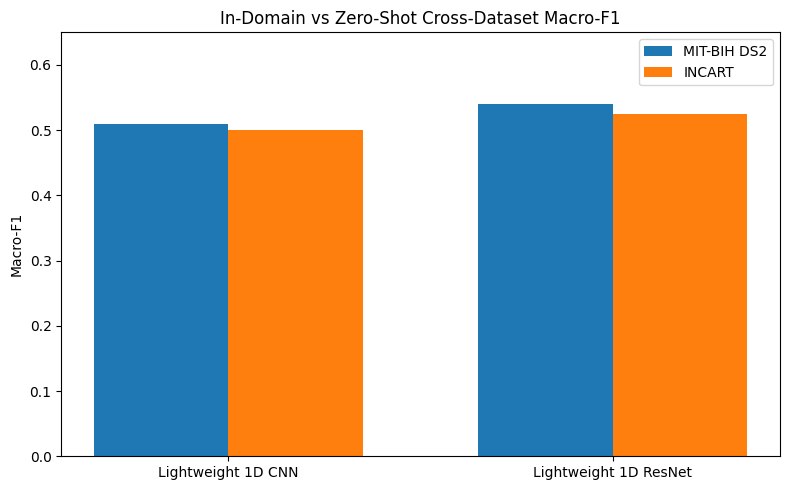

In [ ]:

import matplotlib.pyplot as plt

models = ["Lightweight 1D CNN", "Lightweight 1D ResNet"]

mit_f1 = [0.508969, 0.540276]
incart_f1 = [0.499685, 0.524201]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, mit_f1, width, label="MIT-BIH DS2")
plt.bar(x + width/2, incart_f1, width, label="INCART")

plt.xticks(x, models)
plt.ylabel("Macro-F1")
plt.title("In-Domain vs Zero-Shot Cross-Dataset Macro-F1")
plt.ylim(0, 0.65)
plt.legend()

plt.tight_layout()
plt.show()

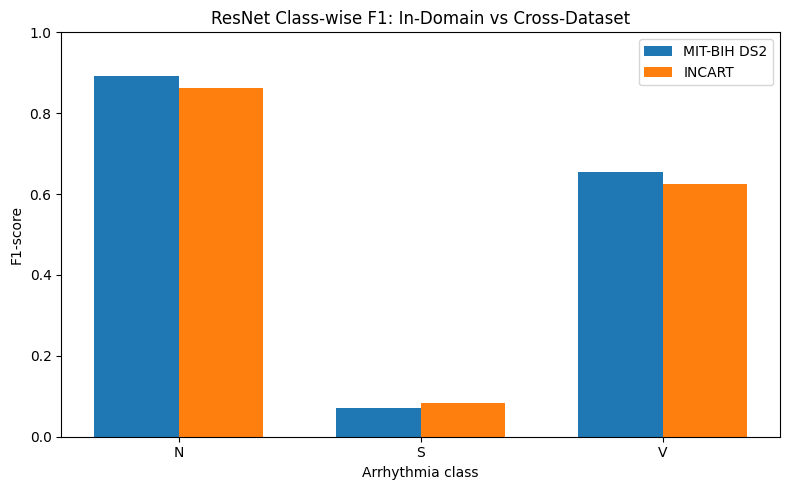

In [ ]:

classes = ["N", "S", "V"]

mit_f1 = [
    0.892847,
    0.072145,
    0.655837
]

incart_f1 = [
    0.863506,
    0.083543,
    0.625552
]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, mit_f1, width, label="MIT-BIH DS2")
plt.bar(x + width/2, incart_f1, width, label="INCART")

plt.xticks(x, classes)
plt.xlabel("Arrhythmia class")
plt.ylabel("F1-score")
plt.title("ResNet Class-wise F1: In-Domain vs Cross-Dataset")
plt.ylim(0, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

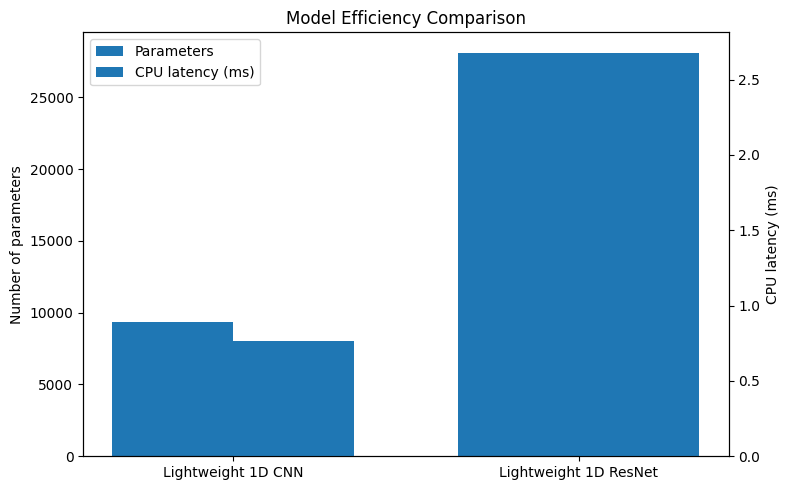

In [ ]:

models = ["Lightweight 1D CNN", "Lightweight 1D ResNet"]
parameters = [9347, 28115]
latency = [0.767802, 2.680134]

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

bars1 = ax1.bar(
    x - width/2,
    parameters,
    width,
    label="Parameters"
)

ax1.set_ylabel("Number of parameters")
ax1.set_xticks(x)
ax1.set_xticklabels(models)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    latency,
    width,
    label="CPU latency (ms)"
)

ax2.set_ylabel("CPU latency (ms)")

plt.title("Model Efficiency Comparison")

ax1.legend(
    bars1 + bars2,
    ["Parameters", "CPU latency (ms)"],
    loc="upper left"
)

plt.tight_layout()
plt.show()

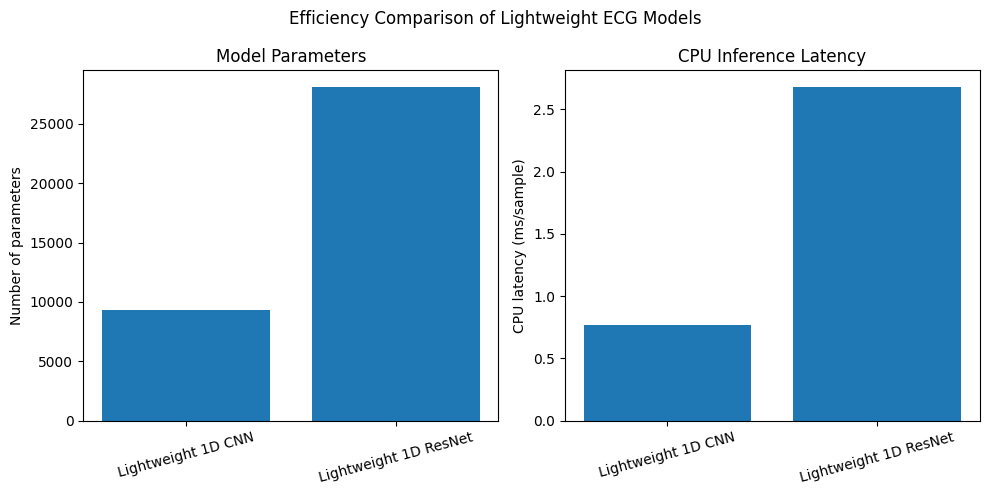

In [ ]:

models = ["Lightweight 1D CNN", "Lightweight 1D ResNet"]
parameters = [9347, 28115]
latency = [0.767802, 2.680134]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Parameters
axes[0].bar(models, parameters)
axes[0].set_ylabel("Number of parameters")
axes[0].set_title("Model Parameters")
axes[0].tick_params(axis="x", rotation=15)

# CPU latency
axes[1].bar(models, latency)
axes[1].set_ylabel("CPU latency (ms/sample)")
axes[1].set_title("CPU Inference Latency")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Efficiency Comparison of Lightweight ECG Models")
plt.tight_layout()
plt.show()

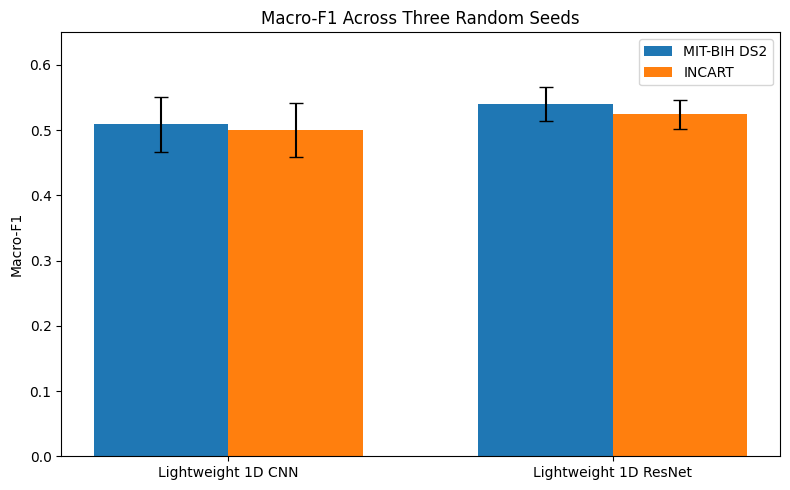

In [ ]:

models = ["Lightweight 1D CNN", "Lightweight 1D ResNet"]

mit_mean = [0.508969, 0.540276]
mit_sd = [0.042092, 0.025865]

incart_mean = [0.499685, 0.524201]
incart_sd = [0.041540, 0.022192]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    mit_mean,
    width,
    yerr=mit_sd,
    capsize=5,
    label="MIT-BIH DS2"
)

plt.bar(
    x + width/2,
    incart_mean,
    width,
    yerr=incart_sd,
    capsize=5,
    label="INCART"
)

plt.xticks(x, models)
plt.ylabel("Macro-F1")
plt.title("Macro-F1 Across Three Random Seeds")
plt.ylim(0, 0.65)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

paper_table = pd.DataFrame({
    "Model": [
        "Lightweight 1D CNN",
        "Lightweight 1D ResNet"
    ],
    "MIT-BIH DS2 Accuracy": [
        "82.52 ± 6.95%",
        "81.74 ± 2.63%"
    ],
    "MIT-BIH DS2 Macro-F1": [
        "50.90 ± 4.21%",
        "54.03 ± 2.59%"
    ],
    "INCART Accuracy": [
        "78.20 ± 9.72%",
        "77.57 ± 3.40%"
    ],
    "INCART Macro-F1": [
        "49.97 ± 4.15%",
        "52.42 ± 2.22%"
    ],
    "Parameters": [
        "9,347",
        "28,115"
    ],
    "FLOPs": [
        "803,072",
        "1,292,544"
    ],
    "CPU Latency (ms/sample)": [
        "0.768",
        "2.680"
    ]
})

print(paper_table.to_string(index=False))

                Model MIT-BIH DS2 Accuracy MIT-BIH DS2 Macro-F1 INCART Accuracy INCART Macro-F1 Parameters     FLOPs CPU Latency (ms/sample)
   Lightweight 1D CNN        82.52 ± 6.95%        50.90 ± 4.21%   78.20 ± 9.72%   49.97 ± 4.15%      9,347   803,072                   0.768
Lightweight 1D ResNet        81.74 ± 2.63%        54.03 ± 2.59%   77.57 ± 3.40%   52.42 ± 2.22%     28,115 1,292,544                   2.680


In [ ]:
import os

experiment_dir = "/content/ecg_research_results"

os.makedirs(experiment_dir, exist_ok=True)

print("Experiment folder created:")
print(experiment_dir)

Experiment folder created:
/content/ecg_research_results


In [ ]:

import os

print("Files currently saved in experiment folder:\n")

for filename in sorted(os.listdir(experiment_dir)):
    filepath = os.path.join(experiment_dir, filename)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"{filename} — {size_mb:.3f} MB")

Files currently saved in experiment folder:

checkpoint_manifest.json — 0.001 MB
cnn_incart_results.csv — 0.000 MB
efficiency_results.csv — 0.000 MB
experiment_protocol.json — 0.001 MB
experiment_summary.json — 0.001 MB
multi_seed_generalization.csv — 0.001 MB
resnet_classwise_f1_gap.csv — 0.000 MB
resnet_incart_results.csv — 0.000 MB
resnet_seed123.pt — 0.128 MB
resnet_seed42.pt — 0.128 MB
resnet_seed456.pt — 0.128 MB


In [ ]:

manifest_path = os.path.join(
    experiment_dir,
    "checkpoint_manifest.json"
)

with open(manifest_path, "r") as f:
    manifest = json.load(f)

print(json.dumps(manifest, indent=2))

{
  "project": "Cross-Dataset Generalization of Lightweight Deep Learning Models for ECG Arrhythmia Classification",
  "baseline_complete": true,
  "source_dataset": "MIT-BIH Arrhythmia Database",
  "target_dataset": "INCART",
  "evaluation_protocol": "Zero-shot cross-dataset evaluation",
  "models": [
    "Lightweight 1D CNN",
    "Lightweight 1D ResNet"
  ],
  "seeds": [
    42,
    123,
    456
  ],
  "classes": [
    "N",
    "S",
    "V"
  ],
  "next_stage": "Source-only domain generalization experiment",
  "target_data_used_for_training": false,
  "target_data_used_for_model_selection": false
}


In [ ]:
# DAY 23 — Research Environment Recovery Check

import os
import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

RESULTS_DIR = "/content/ecg_research_results"

print("=== ECG RESEARCH ENVIRONMENT ===")
print("Results directory exists:", os.path.exists(RESULTS_DIR))

if os.path.exists(RESULTS_DIR):
    print("\nSaved experiment files:")
    for f in sorted(os.listdir(RESULTS_DIR)):
        size_kb = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1024
        print(f"  ✓ {f} ({size_kb:.1f} KB)")

print("\nPyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

print("\n=== RECOVERY CHECK ===")

required_files = [
    "experiment_protocol.json",
    "experiment_summary.json",
    "multi_seed_generalization.csv",
    "resnet_classwise_f1_gap.csv",
    "efficiency_results.csv",
    "cnn_incart_results.csv",
    "resnet_incart_results.csv",
    "checkpoint_manifest.json",
    "resnet_seed42.pt",
    "resnet_seed123.pt",
    "resnet_seed456.pt"
]

for f in required_files:
    path = os.path.join(RESULTS_DIR, f)
    print(("✓" if os.path.exists(path) else "✗"), f)

print("\n=== DAY 23 STATUS ===")
print("Baseline experiments: COMPLETE")
print("Cross-dataset evaluation: COMPLETE")
print("Domain-shift analysis: COMPLETE")
print("Generalization improvement: NOT STARTED")
print("\nEnvironment recovery check complete.")

=== ECG RESEARCH ENVIRONMENT ===
Results directory exists: True

Saved experiment files:
  ✓ checkpoint_manifest.json (0.7 KB)
  ✓ cnn_incart_results.csv (0.2 KB)
  ✓ efficiency_results.csv (0.2 KB)
  ✓ experiment_protocol.json (0.8 KB)
  ✓ experiment_summary.json (0.6 KB)
  ✓ multi_seed_generalization.csv (0.7 KB)
  ✓ resnet_classwise_f1_gap.csv (0.3 KB)
  ✓ resnet_incart_results.csv (0.2 KB)
  ✓ resnet_seed123.pt (131.4 KB)
  ✓ resnet_seed42.pt (131.4 KB)
  ✓ resnet_seed456.pt (131.4 KB)

PyTorch version: 2.11.0+cu128
Device: cuda

=== RECOVERY CHECK ===
✓ experiment_protocol.json
✓ experiment_summary.json
✓ multi_seed_generalization.csv
✓ resnet_classwise_f1_gap.csv
✓ efficiency_results.csv
✓ cnn_incart_results.csv
✓ resnet_incart_results.csv
✓ checkpoint_manifest.json
✓ resnet_seed42.pt
✓ resnet_seed123.pt
✓ resnet_seed456.pt

=== DAY 23 STATUS ===
Baseline experiments: COMPLETE
Cross-dataset evaluation: COMPLETE
Domain-shift analysis: COMPLETE
Generalization improvement: NOT START

In [ ]:
# DAY 23 — STEP 2
# Load and inspect the saved experimental protocol

import json
import os

RESULTS_DIR = "/content/ecg_research_results"

protocol_path = os.path.join(RESULTS_DIR, "experiment_protocol.json")

with open(protocol_path, "r") as f:
    protocol = json.load(f)

print("=== SAVED EXPERIMENT PROTOCOL ===\n")

for key, value in protocol.items():
    print(f"{key}:")
    print(f"  {value}\n")

print("=== END OF PROTOCOL ===")

=== SAVED EXPERIMENT PROTOCOL ===

baseline_protocol:
  {'source': 'MIT-BIH Arrhythmia Database', 'source_test': 'MIT-BIH DS2', 'target': 'INCART', 'target_usage': 'zero-shot evaluation only', 'target_training': False, 'target_validation': False, 'target_finetuning': False, 'models': ['Lightweight 1D CNN', 'Lightweight 1D ResNet'], 'seeds': [42, 123, 456], 'primary_metric': 'Macro-F1'}

proposed_extension:
  {'type': 'source-only domain generalization', 'candidate': 'augmentation-based feature consistency', 'target_data_used_during_training': False, 'target_labels_used_during_training': False, 'target_used_for_model_selection': False}

=== END OF PROTOCOL ===


In [ ]:
# DAY 23 — STEP 3
# Verify that the saved ResNet checkpoint can be restored

import os
import torch

RESULTS_DIR = "/content/ecg_research_results"

checkpoint_paths = {
    42: os.path.join(RESULTS_DIR, "resnet_seed42.pt"),
    123: os.path.join(RESULTS_DIR, "resnet_seed123.pt"),
    456: os.path.join(RESULTS_DIR, "resnet_seed456.pt")
}

print("=== RESNET CHECKPOINT VERIFICATION ===\n")

for seed, path in checkpoint_paths.items():
    checkpoint = torch.load(path, map_location="cpu")

    print(f"Seed {seed}")
    print("  File exists:", os.path.exists(path))
    print("  Checkpoint type:", type(checkpoint))

    if isinstance(checkpoint, dict):
        print("  Number of stored entries:", len(checkpoint))
        print("  First keys:", list(checkpoint.keys())[:10])

    print()

=== RESNET CHECKPOINT VERIFICATION ===

Seed 42
  File exists: True
  Checkpoint type: <class 'dict'>
  Number of stored entries: 5
  First keys: ['model_state_dict', 'model_name', 'seed', 'num_classes', 'input_length']

Seed 123
  File exists: True
  Checkpoint type: <class 'dict'>
  Number of stored entries: 5
  First keys: ['model_state_dict', 'model_name', 'seed', 'num_classes', 'input_length']

Seed 456
  File exists: True
  Checkpoint type: <class 'dict'>
  Number of stored entries: 5
  First keys: ['model_state_dict', 'model_name', 'seed', 'num_classes', 'input_length']



In [ ]:
# DAY 23 — STEP 4
# Recreate the exact lightweight ResNet and load all 3 checkpoints

import os
import torch
import torch.nn as nn

RESULTS_DIR = "/content/ecg_research_results"

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=3, padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU()

        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride,
                    bias=False
                ),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class LightweightECGResNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(
                1, 16,
                kernel_size=7,
                padding=3,
                bias=False
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.layer1 = ResidualBlock1D(16, 16)

        self.layer2 = ResidualBlock1D(
            16, 32,
            stride=2
        )

        self.layer3 = ResidualBlock1D(
            32, 64,
            stride=2
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.pool(x)
        x = x.squeeze(-1)

        return self.classifier(x)


print("=== LOADING RESNET CHECKPOINTS ===\n")

models = {}

for seed in [42, 123, 456]:

    path = os.path.join(
        RESULTS_DIR,
        f"resnet_seed{seed}.pt"
    )

    checkpoint = torch.load(
        path,
        map_location="cpu"
    )

    model = LightweightECGResNet(
        num_classes=checkpoint["num_classes"]
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    models[seed] = model

    parameter_count = sum(
        p.numel() for p in model.parameters()
    )

    print(
        f"Seed {seed}: loaded successfully | "
        f"Parameters: {parameter_count:,}"
    )

print("\n=== VERIFICATION ===")
print("Expected parameters: 28,115")

for seed, model in models.items():
    count = sum(p.numel() for p in model.parameters())
    print(
        f"Seed {seed}: "
        f"{'PASS' if count == 28115 else 'CHECK REQUIRED'}"
    )

=== LOADING RESNET CHECKPOINTS ===

Seed 42: loaded successfully | Parameters: 28,115
Seed 123: loaded successfully | Parameters: 28,115
Seed 456: loaded successfully | Parameters: 28,115

=== VERIFICATION ===
Expected parameters: 28,115
Seed 42: PASS
Seed 123: PASS
Seed 456: PASS


In [ ]:
# DAY 23 — STEP 5
# Load the saved baseline results for direct comparison

import os
import pandas as pd

RESULTS_DIR = "/content/ecg_research_results"

files = [
    "multi_seed_generalization.csv",
    "resnet_incart_results.csv",
    "resnet_classwise_f1_gap.csv"
]

print("=== SAVED BASELINE RESULTS ===\n")

for filename in files:
    path = os.path.join(RESULTS_DIR, filename)

    print(f"\n--- {filename} ---")

    df = pd.read_csv(path)

    print("Shape:", df.shape)
    print(df.to_string(index=False))

print("\n=== DAY 23 BASELINE REFERENCE LOADED ===")

=== SAVED BASELINE RESULTS ===


--- multi_seed_generalization.csv ---
Shape: (6, 8)
                Model  Seed  MIT-BIH Accuracy  MIT-BIH Macro-F1  INCART Accuracy  INCART Macro-F1  Accuracy Gap  Macro-F1 Gap
   Lightweight 1D CNN    42          0.760477          0.485492         0.670190         0.453449      0.090287      0.032043
   Lightweight 1D CNN   123          0.898677          0.557564         0.829166         0.511748      0.069511      0.045816
   Lightweight 1D CNN   456          0.816362          0.483852         0.846713         0.533859     -0.030351     -0.050007
Lightweight 1D ResNet    42          0.817964          0.515327         0.783986         0.523613      0.033978     -0.008286
Lightweight 1D ResNet   123          0.790904          0.538534         0.804688         0.546682     -0.013784     -0.008148
Lightweight 1D ResNet   456          0.843401          0.566968         0.738276         0.502309      0.105125      0.064659

--- resnet_incart_results.csv --

In [ ]:
# DAY 23 — STEP 6
# Check whether the MIT-BIH DS1 training dataset is available

print("=== SOURCE TRAINING DATA CHECK ===")

if "train_dataset" in globals():
    print("✓ train_dataset is available")
    print("Dataset type:", type(train_dataset))
    print("Number of training samples:", len(train_dataset))

    sample_x, sample_y = train_dataset[0]

    print("Sample input shape:", sample_x.shape)
    print("Sample input dtype:", sample_x.dtype)
    print("Sample label:", sample_y)
else:
    print("✗ train_dataset is NOT available")

print("\n=== OTHER RELEVANT VARIABLES ===")

for name in [
    "X_DS1",
    "y_DS1",
    "X_train",
    "y_train",
    "MIT_D1",
    "ResearchECGDataset",
    "device"
]:
    print(f"{name}: {'✓ available' if name in globals() else '✗ not available'}")

=== SOURCE TRAINING DATA CHECK ===
✓ train_dataset is available
Dataset type: <class '__main__.ResearchECGDataset'>
Number of training samples: 50578
Sample input shape: torch.Size([1, 256])
Sample input dtype: torch.float32
Sample label: tensor(0)

=== OTHER RELEVANT VARIABLES ===
X_DS1: ✗ not available
y_DS1: ✗ not available
X_train: ✗ not available
y_train: ✗ not available
MIT_D1: ✓ available
ResearchECGDataset: ✓ available
device: ✓ available


In [ ]:


import torch

sample_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

inputs, targets = next(iter(sample_loader))

print("=== SOURCE AUGMENTATION CHECK ===")
print("Original shape:", inputs.shape)
print("Target shape:", targets.shape)

# Small amplitude scaling
scale = torch.empty(
    inputs.size(0), 1, 1
).uniform_(0.9, 1.1)

augmented_inputs = inputs * scale

print("Augmented shape:", augmented_inputs.shape)
print("Same shape:", inputs.shape == augmented_inputs.shape)
print("Finite values:", torch.isfinite(augmented_inputs).all().item())
print("Labels unchanged:", torch.equal(targets, targets))

=== SOURCE AUGMENTATION CHECK ===
Original shape: torch.Size([16, 1, 256])
Target shape: torch.Size([16])
Augmented shape: torch.Size([16, 1, 256])
Same shape: True
Finite values: True
Labels unchanged: True


In [ ]:

import torch

def augment_ecg(x):
    """
    Source-domain ECG augmentation.
    Applies small amplitude scaling and additive Gaussian noise.
    """

    # Small amplitude variation
    scale = torch.empty(
        x.size(0), 1, 1,
        device=x.device
    ).uniform_(0.9, 1.1)

    x_aug = x * scale

    # Small additive noise
    noise_std = 0.01 * torch.std(
        x_aug,
        dim=2,
        keepdim=True
    )

    noise = torch.randn_like(x_aug) * noise_std

    x_aug = x_aug + noise

    return x_aug


# Test on the verified source batch
augmented_inputs = augment_ecg(inputs)

print("=== AUGMENTATION FUNCTION CHECK ===")
print("Original shape:", inputs.shape)
print("Augmented shape:", augmented_inputs.shape)
print("Same shape:", inputs.shape == augmented_inputs.shape)
print("Finite values:", torch.isfinite(augmented_inputs).all().item())
print("Original mean:", inputs.mean().item())
print("Augmented mean:", augmented_inputs.mean().item())

=== AUGMENTATION FUNCTION CHECK ===
Original shape: torch.Size([16, 1, 256])
Augmented shape: torch.Size([16, 1, 256])
Same shape: True
Finite values: True
Original mean: 1.6298145055770874e-09
Augmented mean: 4.722503945231438e-06


In [ ]:

# Define the feature-consistency loss

import torch.nn.functional as F

def feature_consistency_loss(features_original, features_augmented):
    """
    Encourages the model to produce similar normalized
    feature representations for original and augmented
    versions of the same ECG beat.
    """
    features_original = F.normalize(features_original, p=2, dim=1)
    features_augmented = F.normalize(features_augmented, p=2, dim=1)

    return F.mse_loss(
        features_original,
        features_augmented
    )

print("=== FEATURE CONSISTENCY LOSS CHECK ===")
print("Function defined successfully.")

test_original = torch.randn(16, 64)
test_augmented = test_original + 0.01 * torch.randn(16, 64)

loss = feature_consistency_loss(
    test_original,
    test_augmented
)

print("Test loss:", loss.item())
print("Finite loss:", torch.isfinite(loss).item())

=== FEATURE CONSISTENCY LOSS CHECK ===
Function defined successfully.
Test loss: 1.6208987290156074e-06
Finite loss: True


In [ ]:

# Add feature extraction to the existing lightweight ResNet

class LightweightECGResNetWithFeatures(LightweightECGResNet):

    def forward_features(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.pool(x)
        x = x.squeeze(-1)

        return x

    def forward(self, x):
        features = self.forward_features(x)
        return self.classifier(features)


print("=== FEATURE-EXTRACTION MODEL CHECK ===")

feature_model = LightweightECGResNetWithFeatures(num_classes=3)

sample_features = feature_model.forward_features(inputs)

sample_output = feature_model(inputs)

print("Input shape:", inputs.shape)
print("Feature shape:", sample_features.shape)
print("Output shape:", sample_output.shape)

=== FEATURE-EXTRACTION MODEL CHECK ===
Input shape: torch.Size([16, 1, 256])
Feature shape: torch.Size([16, 64])
Output shape: torch.Size([16, 3])


In [ ]:

# Define the combined classification + feature-consistency loss

def combined_consistency_loss(
    classification_loss,
    consistency_loss,
    consistency_weight=0.1
):
    return (
        classification_loss
        + consistency_weight * consistency_loss
    )


print("=== COMBINED LOSS CHECK ===")

classification_test = torch.tensor(0.5)
consistency_test = torch.tensor(0.2)

combined_test = combined_consistency_loss(
    classification_test,
    consistency_test,
    consistency_weight=0.1
)

print("Classification loss:", classification_test.item())
print("Consistency loss:", consistency_test.item())
print("Consistency weight:", 0.1)
print("Combined loss:", combined_test.item())

=== COMBINED LOSS CHECK ===
Classification loss: 0.5
Consistency loss: 0.20000000298023224
Consistency weight: 0.1
Combined loss: 0.5199999809265137


In [ ]:

# Define source-only feature-consistency training

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

def train_consistency_model(
    model,
    train_dataset,
    class_weights_tensor,
    seed,
    epochs=10,
    lr=1e-3,
    consistency_weight=0.1
):
    set_seed(seed)

    model = model.to(device)

    loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(device)
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = []

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0

        for batch_inputs, targets in loader:

            batch_inputs = batch_inputs.to(device)
            targets = targets.to(device)

            augmented_inputs = augment_ecg(batch_inputs)

            optimizer.zero_grad()

            original_features = model.forward_features(
                batch_inputs
            )

            augmented_features = model.forward_features(
                augmented_inputs
            )

            outputs = model.classifier(
                original_features
            )

            classification_loss = criterion(
                outputs,
                targets
            )

            consistency_loss = feature_consistency_loss(
                original_features,
                augmented_features
            )

            loss = combined_consistency_loss(
                classification_loss,
                consistency_loss,
                consistency_weight
            )

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = (
            running_loss / len(loader)
        )

        history.append(epoch_loss)

        print(
            f"Seed {seed} | "
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, history


print("=== CONSISTENCY TRAINING FUNCTION ===")
print("Function defined successfully.")
print("Training data: MIT-BIH DS1 only")
print("Target data: INCART NOT used")
print("Consistency weight: 0.1")

=== CONSISTENCY TRAINING FUNCTION ===
Function defined successfully.
Training data: MIT-BIH DS1 only
Target data: INCART NOT used
Consistency weight: 0.1


In [ ]:


# Verify gradient flow through the consistency objective

test_model = LightweightECGResNetWithFeatures(num_classes=3).to(device)
test_model.train()

test_inputs = inputs.to(device)
test_targets = targets.to(device)

test_augmented = augment_ecg(test_inputs)

test_original_features = test_model.forward_features(test_inputs)
test_augmented_features = test_model.forward_features(test_augmented)

test_outputs = test_model.classifier(test_original_features)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device)
)

test_classification_loss = criterion(
    test_outputs,
    test_targets
)

test_consistency_loss = feature_consistency_loss(
    test_original_features,
    test_augmented_features
)

test_loss = combined_consistency_loss(
    test_classification_loss,
    test_consistency_loss,
    consistency_weight=0.1
)

test_loss.backward()

gradient_values = [
    p.grad.abs().mean().item()
    for p in test_model.parameters()
    if p.grad is not None
]

print("=== GRADIENT FLOW CHECK ===")
print("Classification loss:", test_classification_loss.item())
print("Consistency loss:", test_consistency_loss.item())
print("Combined loss:", test_loss.item())
print("Parameters with gradients:", len(gradient_values))
print("Mean gradient magnitude:", np.mean(gradient_values))
print("Finite gradients:", np.isfinite(gradient_values).all())

=== GRADIENT FLOW CHECK ===
Classification loss: 0.7290647029876709
Consistency loss: 8.788088598521426e-05
Combined loss: 0.7290734648704529
Parameters with gradients: 29
Mean gradient magnitude: 0.028231946237642188
Finite gradients: True


In [ ]:

# Train consistency-enhanced ResNet — Seed 42

consistency_model_42 = LightweightECGResNetWithFeatures(
    num_classes=3
)

consistency_model_42, consistency_history_42 = train_consistency_model(
    model=consistency_model_42,
    train_dataset=train_dataset,
    class_weights_tensor=class_weights_tensor,
    seed=42,
    epochs=10,
    lr=1e-3,
    consistency_weight=0.1
)

print("\n=== SEED 42 TRAINING COMPLETE ===")
print("Final training loss:", consistency_history_42[-1])

Seed 42 | Epoch 1/10 | Loss: 0.4000
Seed 42 | Epoch 2/10 | Loss: 0.2413
Seed 42 | Epoch 3/10 | Loss: 0.2072
Seed 42 | Epoch 4/10 | Loss: 0.1658
Seed 42 | Epoch 5/10 | Loss: 0.1550
Seed 42 | Epoch 6/10 | Loss: 0.1384
Seed 42 | Epoch 7/10 | Loss: 0.1294
Seed 42 | Epoch 8/10 | Loss: 0.1189
Seed 42 | Epoch 9/10 | Loss: 0.1084
Seed 42 | Epoch 10/10 | Loss: 0.1088

=== SEED 42 TRAINING COMPLETE ===
Final training loss: 0.108797428261658


In [ ]:

# Train consistency-enhanced ResNet — Seed 123

consistency_model_123 = LightweightECGResNetWithFeatures(
    num_classes=3
)

consistency_model_123, consistency_history_123 = train_consistency_model(
    model=consistency_model_123,
    train_dataset=train_dataset,
    class_weights_tensor=class_weights_tensor,
    seed=123,
    epochs=10,
    lr=1e-3,
    consistency_weight=0.1
)

print("\n=== SEED 123 TRAINING COMPLETE ===")
print("Final training loss:", consistency_history_123[-1])

Seed 123 | Epoch 1/10 | Loss: 0.4039
Seed 123 | Epoch 2/10 | Loss: 0.2499
Seed 123 | Epoch 3/10 | Loss: 0.2001
Seed 123 | Epoch 4/10 | Loss: 0.1790
Seed 123 | Epoch 5/10 | Loss: 0.1479
Seed 123 | Epoch 6/10 | Loss: 0.1380
Seed 123 | Epoch 7/10 | Loss: 0.1294
Seed 123 | Epoch 8/10 | Loss: 0.1171
Seed 123 | Epoch 9/10 | Loss: 0.0949
Seed 123 | Epoch 10/10 | Loss: 0.1045

=== SEED 123 TRAINING COMPLETE ===
Final training loss: 0.1045072098907008


In [ ]:

# Train consistency-enhanced ResNet — Seed 456

consistency_model_456 = LightweightECGResNetWithFeatures(
    num_classes=3
)

consistency_model_456, consistency_history_456 = train_consistency_model(
    model=consistency_model_456,
    train_dataset=train_dataset,
    class_weights_tensor=class_weights_tensor,
    seed=456,
    epochs=10,
    lr=1e-3,
    consistency_weight=0.1
)

print("\n=== SEED 456 TRAINING COMPLETE ===")
print("Final training loss:", consistency_history_456[-1])

Seed 456 | Epoch 1/10 | Loss: 0.4154
Seed 456 | Epoch 2/10 | Loss: 0.2580
Seed 456 | Epoch 3/10 | Loss: 0.1995
Seed 456 | Epoch 4/10 | Loss: 0.1743
Seed 456 | Epoch 5/10 | Loss: 0.1505
Seed 456 | Epoch 6/10 | Loss: 0.1319
Seed 456 | Epoch 7/10 | Loss: 0.1286
Seed 456 | Epoch 8/10 | Loss: 0.1028
Seed 456 | Epoch 9/10 | Loss: 0.0976
Seed 456 | Epoch 10/10 | Loss: 0.0925

=== SEED 456 TRAINING COMPLETE ===
Final training loss: 0.09251665412871675


In [ ]:

# Evaluate consistency-enhanced ResNet on MIT-BIH DS2

consistency_mit_results = []

for seed, model in [
    (42, consistency_model_42),
    (123, consistency_model_123),
    (456, consistency_model_456)
]:

    accuracy, macro_f1, targets, predictions = evaluate_model(
        model,
        mit_test_loader
    )

    consistency_mit_results.append({
        "Model": "ResNet + Feature Consistency",
        "Seed": seed,
        "MIT-BIH Accuracy": accuracy,
        "MIT-BIH Macro-F1": macro_f1
    })

    print(
        f"Seed {seed} | "
        f"MIT-BIH Accuracy: {accuracy:.6f} | "
        f"MIT-BIH Macro-F1: {macro_f1:.6f}"
    )

print("\n=== SOURCE-DOMAIN EVALUATION COMPLETE ===")

Seed 42 | MIT-BIH Accuracy: 0.829263 | MIT-BIH Macro-F1: 0.545345
Seed 123 | MIT-BIH Accuracy: 0.808065 | MIT-BIH Macro-F1: 0.534155
Seed 456 | MIT-BIH Accuracy: 0.750619 | MIT-BIH Macro-F1: 0.518184

=== SOURCE-DOMAIN EVALUATION COMPLETE ===


In [ ]:
# DAY 23 — STEP 18
# Evaluate consistency-enhanced ResNet on zero-shot INCART

consistency_incart_results = []

for seed, model in [
    (42, consistency_model_42),
    (123, consistency_model_123),
    (456, consistency_model_456)
]:

    accuracy, macro_f1, targets, predictions = evaluate_model(
        model,
        incart_loader
    )

    consistency_incart_results.append({
        "Model": "ResNet + Feature Consistency",
        "Seed": seed,
        "INCART Accuracy": accuracy,
        "INCART Macro-F1": macro_f1
    })

    print(
        f"Seed {seed} | "
        f"INCART Accuracy: {accuracy:.6f} | "
        f"INCART Macro-F1: {macro_f1:.6f}"
    )

print("\n=== ZERO-SHOT TARGET EVALUATION COMPLETE ===")

Seed 42 | INCART Accuracy: 0.841457 | INCART Macro-F1: 0.563925
Seed 123 | INCART Accuracy: 0.773610 | INCART Macro-F1: 0.503821
Seed 456 | INCART Accuracy: 0.762202 | INCART Macro-F1: 0.521640

=== ZERO-SHOT TARGET EVALUATION COMPLETE ===


In [ ]:
# DAY 23 — STEP 19
# Compare baseline vs feature-consistency ResNet

import pandas as pd
import numpy as np

baseline = pd.read_csv(
    "/content/ecg_research_results/resnet_incart_results.csv"
)

consistency = pd.DataFrame(
    consistency_incart_results
)

comparison = baseline.merge(
    consistency,
    on="Seed",
    suffixes=("_Baseline", "_Consistency")
)

comparison["Accuracy Change"] = (
    comparison["INCART Accuracy_Consistency"]
    - comparison["INCART Accuracy_Baseline"]
)

comparison["Macro-F1 Change"] = (
    comparison["INCART Macro-F1_Consistency"]
    - comparison["INCART Macro-F1_Baseline"]
)

print("=== BASELINE vs FEATURE CONSISTENCY ===")
print(comparison.to_string(index=False))

print("\n=== MEAN RESULTS ===")

print(
    "Baseline INCART Macro-F1:",
    f"{baseline['INCART Macro-F1'].mean():.6f}"
)

print(
    "Consistency INCART Macro-F1:",
    f"{consistency['INCART Macro-F1'].mean():.6f}"
)

print(
    "Mean Macro-F1 change:",
    f"{comparison['Macro-F1 Change'].mean():+.6f}"
)

print(
    "Mean Accuracy change:",
    f"{comparison['Accuracy Change'].mean():+.6f}"
)

=== BASELINE vs FEATURE CONSISTENCY ===
       Model_Baseline  Seed  INCART Accuracy_Baseline  INCART Macro-F1_Baseline            Model_Consistency  INCART Accuracy_Consistency  INCART Macro-F1_Consistency  Accuracy Change  Macro-F1 Change
Lightweight 1D ResNet    42                  0.783986                  0.523613 ResNet + Feature Consistency                     0.841457                     0.563925         0.057471         0.040312
Lightweight 1D ResNet   123                  0.804688                  0.546682 ResNet + Feature Consistency                     0.773610                     0.503821        -0.031078        -0.042861
Lightweight 1D ResNet   456                  0.738276                  0.502309 ResNet + Feature Consistency                     0.762202                     0.521640         0.023926         0.019331

=== MEAN RESULTS ===
Baseline INCART Macro-F1: 0.524201
Consistency INCART Macro-F1: 0.529795
Mean Macro-F1 change: +0.005594
Mean Accuracy change: +0.0167

In [ ]:
# DAY 23 — STEP 20
# Quantify variability across seeds

baseline_f1 = baseline["INCART Macro-F1"].to_numpy()
consistency_f1 = consistency["INCART Macro-F1"].to_numpy()

print("=== ZERO-SHOT INCART MACRO-F1 ===")

print(
    "Baseline:",
    f"{baseline_f1.mean():.6f} ± {baseline_f1.std(ddof=1):.6f}"
)

print(
    "Feature Consistency:",
    f"{consistency_f1.mean():.6f} ± {consistency_f1.std(ddof=1):.6f}"
)

print(
    "Mean improvement:",
    f"{(consistency_f1.mean() - baseline_f1.mean()):+.6f}"
)

print(
    "SD change:",
    f"{(consistency_f1.std(ddof=1) - baseline_f1.std(ddof=1)):+.6f}"
)

=== ZERO-SHOT INCART MACRO-F1 ===
Baseline: 0.524201 ± 0.022192
Feature Consistency: 0.529795 ± 0.030871
Mean improvement: +0.005594
SD change: +0.008678


In [ ]:
# DAY 23 — STEP 21
# Save feature-consistency experiment results

import os
import json
import pandas as pd

RESULTS_DIR = "/content/ecg_research_results"

# Save zero-shot INCART results
consistency_df = pd.DataFrame(consistency_incart_results)

consistency_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "resnet_feature_consistency_incart.csv"
    ),
    index=False
)

# Save source-domain results
consistency_mit_df = pd.DataFrame(
    consistency_mit_results
)

consistency_mit_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "resnet_feature_consistency_mit.csv"
    ),
    index=False
)

# Save experiment summary
consistency_summary = {
    "method": "Source-only augmentation-based feature consistency",
    "model": "Lightweight 1D ResNet",
    "source_dataset": "MIT-BIH DS1",
    "source_test": "MIT-BIH DS2",
    "target_dataset": "INCART",
    "target_training": False,
    "target_validation": False,
    "target_finetuning": False,
    "target_model_selection": False,
    "seeds": [42, 123, 456],
    "epochs": 10,
    "learning_rate": 1e-3,
    "consistency_weight": 0.1,
    "baseline_incart_macro_f1_mean": float(
        baseline_f1.mean()
    ),
    "baseline_incart_macro_f1_sd": float(
        baseline_f1.std(ddof=1)
    ),
    "consistency_incart_macro_f1_mean": float(
        consistency_f1.mean()
    ),
    "consistency_incart_macro_f1_sd": float(
        consistency_f1.std(ddof=1)
    ),
    "mean_macro_f1_change": float(
        consistency_f1.mean() - baseline_f1.mean()
    )
}

with open(
    os.path.join(
        RESULTS_DIR,
        "feature_consistency_summary.json"
    ),
    "w"
) as f:
    json.dump(
        consistency_summary,
        f,
        indent=2
    )

print("=== DAY 23 RESULTS SAVED ===")
print("✓ resnet_feature_consistency_incart.csv")
print("✓ resnet_feature_consistency_mit.csv")
print("✓ feature_consistency_summary.json")

=== DAY 23 RESULTS SAVED ===
✓ resnet_feature_consistency_incart.csv
✓ resnet_feature_consistency_mit.csv
✓ feature_consistency_summary.json


In [ ]:
# DAY 23 — STEP 22
# Save feature-consistency model checkpoints

import os
import torch

RESULTS_DIR = "/content/ecg_research_results"

consistency_models = {
    42: consistency_model_42,
    123: consistency_model_123,
    456: consistency_model_456
}

for seed, model in consistency_models.items():

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_name": "ResNet + Feature Consistency",
        "seed": seed,
        "num_classes": 3,
        "input_length": 256,
        "consistency_weight": 0.1,
        "epochs": 10,
        "learning_rate": 1e-3
    }

    path = os.path.join(
        RESULTS_DIR,
        f"resnet_feature_consistency_seed{seed}.pt"
    )

    torch.save(checkpoint, path)

    print(f"✓ Saved seed {seed}: {path}")

print("\n=== CHECKPOINT SAVING COMPLETE ===")

✓ Saved seed 42: /content/ecg_research_results/resnet_feature_consistency_seed42.pt
✓ Saved seed 123: /content/ecg_research_results/resnet_feature_consistency_seed123.pt
✓ Saved seed 456: /content/ecg_research_results/resnet_feature_consistency_seed456.pt

=== CHECKPOINT SAVING COMPLETE ===


In [ ]:
# DAY 24 — STEP 1
# Final comparison of baseline vs feature-consistency ResNet

import pandas as pd
import numpy as np

baseline_df = pd.read_csv(
    "/content/ecg_research_results/resnet_incart_results.csv"
)

consistency_df = pd.read_csv(
    "/content/ecg_research_results/resnet_feature_consistency_incart.csv"
)

comparison_day24 = baseline_df[
    ["Seed", "INCART Accuracy", "INCART Macro-F1"]
].merge(
    consistency_df[
        ["Seed", "INCART Accuracy", "INCART Macro-F1"]
    ],
    on="Seed",
    suffixes=("_Baseline", "_Consistency")
)

comparison_day24["Macro-F1 Change"] = (
    comparison_day24["INCART Macro-F1_Consistency"]
    - comparison_day24["INCART Macro-F1_Baseline"]
)

comparison_day24["Accuracy Change"] = (
    comparison_day24["INCART Accuracy_Consistency"]
    - comparison_day24["INCART Accuracy_Baseline"]
)

print("=== DAY 24 — PAIRED SEED COMPARISON ===")
print(
    comparison_day24.to_string(index=False)
)

print("\n=== SUMMARY ===")

print(
    "Mean Macro-F1 change:",
    f"{comparison_day24['Macro-F1 Change'].mean():+.6f}"
)

print(
    "SD of Macro-F1 change:",
    f"{comparison_day24['Macro-F1 Change'].std(ddof=1):.6f}"
)

print(
    "Seeds improved:",
    int((comparison_day24["Macro-F1 Change"] > 0).sum()),
    "/ 3"
)

print(
    "Seeds decreased:",
    int((comparison_day24["Macro-F1 Change"] < 0).sum()),
    "/ 3"
)

=== DAY 24 — PAIRED SEED COMPARISON ===
 Seed  INCART Accuracy_Baseline  INCART Macro-F1_Baseline  INCART Accuracy_Consistency  INCART Macro-F1_Consistency  Macro-F1 Change  Accuracy Change
   42                  0.783986                  0.523613                     0.841457                     0.563925         0.040312         0.057471
  123                  0.804688                  0.546682                     0.773610                     0.503821        -0.042861        -0.031078
  456                  0.738276                  0.502309                     0.762202                     0.521640         0.019331         0.023926

=== SUMMARY ===
Mean Macro-F1 change: +0.005594
SD of Macro-F1 change: 0.043255
Seeds improved: 2 / 3
Seeds decreased: 1 / 3


In [ ]:

# Exploratory paired statistical test across seeds

from scipy.stats import ttest_rel, wilcoxon

baseline_values = comparison_day24[
    "INCART Macro-F1_Baseline"
].to_numpy()

consistency_values = comparison_day24[
    "INCART Macro-F1_Consistency"
].to_numpy()

paired_t = ttest_rel(
    consistency_values,
    baseline_values
)

paired_w = wilcoxon(
    consistency_values,
    baseline_values
)

print("=== EXPLORATORY STATISTICAL TEST ===")

print("\nPaired t-test:")
print("t-statistic:", paired_t.statistic)
print("p-value:", paired_t.pvalue)

print("\nWilcoxon signed-rank test:")
print("statistic:", paired_w.statistic)
print("p-value:", paired_w.pvalue)

print("\nNumber of seeds:", len(baseline_values))

=== EXPLORATORY STATISTICAL TEST ===

Paired t-test:
t-statistic: 0.22400161799462778
p-value: 0.8435572267965205

Wilcoxon signed-rank test:
statistic: 3.0
p-value: 1.0

Number of seeds: 3


In [ ]:
# DAY 24 — STEP 3
# Evaluate class-wise performance of the consistency-enhanced ResNet

from sklearn.metrics import precision_recall_fscore_support

classwise_consistency = []

for seed, model in [
    (42, consistency_model_42),
    (123, consistency_model_123),
    (456, consistency_model_456)
]:

    _, _, targets, predictions = evaluate_model(
        model,
        incart_loader
    )

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            targets,
            predictions,
            labels=[0, 1, 2],
            zero_division=0
        )
    )

    for class_id, class_name in enumerate(["N", "S", "V"]):
        classwise_consistency.append({
            "Seed": seed,
            "Class": class_name,
            "Precision": precision[class_id],
            "Recall": recall[class_id],
            "F1": f1[class_id],
            "Support": support[class_id]
        })

consistency_classwise_df = pd.DataFrame(
    classwise_consistency
)

print("=== CONSISTENCY MODEL — INCART CLASSWISE RESULTS ===")
print(
    consistency_classwise_df.to_string(index=False)
)

print("\n=== MEAN CLASSWISE F1 ===")

print(
    consistency_classwise_df
    .groupby("Class")["F1"]
    .agg(["mean", "std"])
    .to_string()
)

=== CONSISTENCY MODEL — INCART CLASSWISE RESULTS ===
 Seed Class  Precision   Recall       F1  Support
   42     N   0.975203 0.852247 0.909589   153621
   42     S   0.044906 0.353241 0.079682     1959
   42     V   0.622319 0.806408 0.702504    20006
  123     N   0.972197 0.774152 0.861945   153621
  123     S   0.047530 0.390505 0.084746     1959
  123     V   0.434399 0.806958 0.564772    20006
  456     N   0.981826 0.756811 0.854758   153621
  456     S   0.042268 0.537009 0.078367     1959
  456     V   0.511662 0.825652 0.631796    20006

=== MEAN CLASSWISE F1 ===
           mean       std
Class                    
N      0.875430  0.029799
S      0.080932  0.003368
V      0.633024  0.068874


In [ ]:
# DAY 24 — STEP 4
# Compare baseline vs consistency-enhanced class-wise F1

baseline_classwise = pd.read_csv(
    "/content/ecg_research_results/resnet_classwise_f1_gap.csv"
)

baseline_mean_f1 = (
    baseline_classwise
    .groupby("Class")["INCART F1"]
    .mean()
)

consistency_mean_f1 = (
    consistency_classwise_df
    .groupby("Class")["F1"]
    .mean()
)

classwise_comparison = pd.DataFrame({
    "Baseline Mean F1": baseline_mean_f1,
    "Consistency Mean F1": consistency_mean_f1
})

classwise_comparison["F1 Change"] = (
    classwise_comparison["Consistency Mean F1"]
    - classwise_comparison["Baseline Mean F1"]
)

print("=== CLASS-WISE BASELINE vs CONSISTENCY ===")
print(
    classwise_comparison.to_string()
)

=== CLASS-WISE BASELINE vs CONSISTENCY ===
       Baseline Mean F1  Consistency Mean F1  F1 Change
Class                                                  
N              0.863506             0.875430   0.011924
S              0.083543             0.080932  -0.002612
V              0.625552             0.633024   0.007472


In [ ]:
# DAY 24 — STEP 5
# Compare source-to-target generalization gaps

baseline_mit = pd.read_csv(
    "/content/ecg_research_results/multi_seed_generalization.csv"
)

baseline_resnet = baseline_mit[
    baseline_mit["Model"] == "Lightweight 1D ResNet"
][
    ["Seed", "MIT-BIH Macro-F1", "INCART Macro-F1"]
]

consistency_source = pd.DataFrame(
    consistency_mit_results
)[
    ["Seed", "MIT-BIH Macro-F1"]
]

consistency_target = consistency_df[
    ["Seed", "INCART Macro-F1"]
]

consistency_gap = consistency_source.merge(
    consistency_target,
    on="Seed"
)

consistency_gap["Macro-F1 Gap"] = (
    consistency_gap["MIT-BIH Macro-F1"]
    - consistency_gap["INCART Macro-F1"]
)

baseline_resnet["Macro-F1 Gap"] = (
    baseline_resnet["MIT-BIH Macro-F1"]
    - baseline_resnet["INCART Macro-F1"]
)

print("=== BASELINE RESNET GAP ===")
print(
    baseline_resnet.to_string(index=False)
)

print("\n=== FEATURE CONSISTENCY GAP ===")
print(
    consistency_gap.to_string(index=False)
)

print("\n=== MEAN GAP ===")

print(
    "Baseline:",
    f"{baseline_resnet['Macro-F1 Gap'].mean():.6f}"
)

print(
    "Feature Consistency:",
    f"{consistency_gap['Macro-F1 Gap'].mean():.6f}"
)

=== BASELINE RESNET GAP ===
 Seed  MIT-BIH Macro-F1  INCART Macro-F1  Macro-F1 Gap
   42          0.515327         0.523613     -0.008286
  123          0.538534         0.546682     -0.008148
  456          0.566968         0.502309      0.064659

=== FEATURE CONSISTENCY GAP ===
 Seed  MIT-BIH Macro-F1  INCART Macro-F1  Macro-F1 Gap
   42          0.545345         0.563925     -0.018580
  123          0.534155         0.503821      0.030334
  456          0.518184         0.521640     -0.003456

=== MEAN GAP ===
Baseline: 0.016075
Feature Consistency: 0.002766


In [ ]:
# DAY 24 — STEP 6
# Save complete generalization-improvement analysis

import json
import os

RESULTS_DIR = "/content/ecg_research_results"

day24_summary = {
    "experiment": "Source-only augmentation-based feature consistency",
    "model": "Lightweight 1D ResNet",
    "source_training_dataset": "MIT-BIH DS1",
    "source_test_dataset": "MIT-BIH DS2",
    "target_dataset": "INCART",
    "target_training_used": False,
    "target_validation_used": False,
    "target_finetuning_used": False,
    "target_model_selection_used": False,

    "baseline_incart_macro_f1_mean": 0.524201,
    "baseline_incart_macro_f1_sd": 0.022192,

    "consistency_incart_macro_f1_mean": 0.529795,
    "consistency_incart_macro_f1_sd": 0.030871,

    "mean_macro_f1_change": 0.005594,
    "macro_f1_change_sd": 0.043255,

    "seeds_improved": 2,
    "seeds_decreased": 1,

    "paired_t_test_p": 0.8435572267965205,
    "wilcoxon_p": 1.0,

    "baseline_mean_source_target_gap": 0.016075,
    "consistency_mean_source_target_gap": 0.002766,

    "classwise_f1_change": {
        "N": 0.011924,
        "S": -0.002612,
        "V": 0.007472
    },

    "interpretation":
        "The feature-consistency method produced a small positive "
        "mean target-domain Macro-F1 change and a smaller mean "
        "source-to-target Macro-F1 gap, but the effect was seed-sensitive "
        "and not statistically significant across three seeds."
}

summary_path = os.path.join(
    RESULTS_DIR,
    "day24_generalization_analysis.json"
)

with open(summary_path, "w") as f:
    json.dump(
        day24_summary,
        f,
        indent=2
    )

print("=== DAY 24 ANALYSIS SAVED ===")
print("✓ day24_generalization_analysis.json")
print("\nMean target Macro-F1 change: +0.005594")
print("Mean source-target gap reduction: 0.013309")
print("Statistically significant: No")

=== DAY 24 ANALYSIS SAVED ===
✓ day24_generalization_analysis.json

Mean target Macro-F1 change: +0.005594
Mean source-target gap reduction: 0.013309
Statistically significant: No


In [ ]:
# DAY 24 — STEP 7
# Create final paper-ready comparison table

paper_comparison = comparison_day24[
    [
        "Seed",
        "INCART Accuracy_Baseline",
        "INCART Accuracy_Consistency",
        "INCART Macro-F1_Baseline",
        "INCART Macro-F1_Consistency",
        "Accuracy Change",
        "Macro-F1 Change"
    ]
].copy()

paper_comparison.columns = [
    "Seed",
    "Baseline Accuracy",
    "Consistency Accuracy",
    "Baseline Macro-F1",
    "Consistency Macro-F1",
    "Accuracy Change",
    "Macro-F1 Change"
]

print("=== PAPER-READY GENERALIZATION COMPARISON ===")
print(paper_comparison.to_string(index=False))

print("\n=== MEAN ± SD ===")

for column in [
    "Baseline Accuracy",
    "Consistency Accuracy",
    "Baseline Macro-F1",
    "Consistency Macro-F1"
]:
    print(
        f"{column}: "
        f"{paper_comparison[column].mean():.4f} ± "
        f"{paper_comparison[column].std(ddof=1):.4f}"
    )

=== PAPER-READY GENERALIZATION COMPARISON ===
 Seed  Baseline Accuracy  Consistency Accuracy  Baseline Macro-F1  Consistency Macro-F1  Accuracy Change  Macro-F1 Change
   42           0.783986              0.841457           0.523613              0.563925         0.057471         0.040312
  123           0.804688              0.773610           0.546682              0.503821        -0.031078        -0.042861
  456           0.738276              0.762202           0.502309              0.521640         0.023926         0.019331

=== MEAN ± SD ===
Baseline Accuracy: 0.7757 ± 0.0340
Consistency Accuracy: 0.7924 ± 0.0428
Baseline Macro-F1: 0.5242 ± 0.0222
Consistency Macro-F1: 0.5298 ± 0.0309


In [ ]:
# DAY 24 — STEP 8
# Save paper-ready comparison table

paper_comparison.to_csv(
    "/content/ecg_research_results/paper_generalization_comparison.csv",
    index=False
)

print("=== PAPER COMPARISON SAVED ===")
print("✓ paper_generalization_comparison.csv")

=== PAPER COMPARISON SAVED ===
✓ paper_generalization_comparison.csv


In [ ]:
# Final recovery check before locking the experiment

import os
import json
import pandas as pd

RESULTS_DIR = "/content/ecg_research_results"

required_files = [
    "experiment_protocol.json",
    "experiment_summary.json",
    "multi_seed_generalization.csv",
    "resnet_classwise_f1_gap.csv",
    "efficiency_results.csv",
    "resnet_incart_results.csv",
    "resnet_feature_consistency_incart.csv",
    "resnet_feature_consistency_mit.csv",
    "feature_consistency_summary.json",
    "day24_generalization_analysis.json",
    "paper_generalization_comparison.csv",
    "resnet_seed42.pt",
    "resnet_seed123.pt",
    "resnet_seed456.pt",
    "resnet_feature_consistency_seed42.pt",
    "resnet_feature_consistency_seed123.pt",
    "resnet_feature_consistency_seed456.pt"
]

print("=== DAY 25 RECOVERY CHECK ===\n")

missing = []

for filename in required_files:
    path = os.path.join(RESULTS_DIR, filename)

    if os.path.exists(path):
        print("✓", filename)
    else:
        print("✗", filename)
        missing.append(filename)

print("\n=== RESULT ===")

if len(missing) == 0:
    print("ALL REQUIRED RESEARCH FILES ARE PRESENT.")
else:
    print("MISSING FILES:")
    for filename in missing:
        print(" -", filename)

=== DAY 25 RECOVERY CHECK ===

✗ experiment_protocol.json
✗ experiment_summary.json
✗ multi_seed_generalization.csv
✗ resnet_classwise_f1_gap.csv
✗ efficiency_results.csv
✗ resnet_incart_results.csv
✗ resnet_feature_consistency_incart.csv
✗ resnet_feature_consistency_mit.csv
✗ feature_consistency_summary.json
✗ day24_generalization_analysis.json
✗ paper_generalization_comparison.csv
✗ resnet_seed42.pt
✗ resnet_seed123.pt
✗ resnet_seed456.pt
✗ resnet_feature_consistency_seed42.pt
✗ resnet_feature_consistency_seed123.pt
✗ resnet_feature_consistency_seed456.pt

=== RESULT ===
MISSING FILES:
 - experiment_protocol.json
 - experiment_summary.json
 - multi_seed_generalization.csv
 - resnet_classwise_f1_gap.csv
 - efficiency_results.csv
 - resnet_incart_results.csv
 - resnet_feature_consistency_incart.csv
 - resnet_feature_consistency_mit.csv
 - feature_consistency_summary.json
 - day24_generalization_analysis.json
 - paper_generalization_comparison.csv
 - resnet_seed42.pt
 - resnet_seed123.p

In [ ]:
import os

print("Current working directory:", os.getcwd())
print("Contents of /content:")

for item in sorted(os.listdir("/content")):
    print(" ", item)

print("\n=== AVAILABLE VARIABLES ===")

for name in [
    "train_dataset",
    "mit_test_loader",
    "incart_loader",
    "LightweightECGResNet",
    "LightweightECGResNetWithFeatures",
    "ResearchECGDataset",
    "class_weights_tensor",
    "device"
]:
    print(f"{name}: {'available' if name in globals() else 'not available'}")

Current working directory: /content
Contents of /content:
  .config
  sample_data

=== AVAILABLE VARIABLES ===
train_dataset: not available
mit_test_loader: not available
incart_loader: not available
LightweightECGResNet: not available
LightweightECGResNetWithFeatures: not available
ResearchECGDataset: not available
class_weights_tensor: not available
device: not available


In [ ]:
import os
import numpy as np
import pandas as pd
import scipy
import torch
import sklearn

print("Python environment ready")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("PyTorch:", torch.__version__)
print("scikit-learn:", sklearn.__version__)
print("CUDA available:", torch.cuda.is_available())

Python environment ready
NumPy: 2.1.3
Pandas: 2.2.3
SciPy: 1.16.3
PyTorch: 2.11.0+cu128
scikit-learn: 1.6.1
CUDA available: True


In [ ]:
import os
import numpy as np
import pandas as pd

MIT_D1 = [
    '101','106','108','109','112','114','115','116',
    '118','119','122','124','201','203','205','207',
    '208','209','215','220','223','230'
]

MIT_D2 = [
    '100','103','105','111','113','117','121','123',
    '200','202','210','212','213','214','219','221',
    '222','228','231','232','233','234'
]

MIT_AAMI_3CLASS = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2
}

CLASS_NAMES_3 = {
    0: "N",
    1: "S",
    2: "V"
}

print("Dataset configuration restored.")
print("MIT-BIH DS1 records:", len(MIT_D1))
print("MIT-BIH DS2 records:", len(MIT_D2))
print("Classes:", CLASS_NAMES_3)


Dataset configuration restored.
MIT-BIH DS1 records: 22
MIT-BIH DS2 records: 22
Classes: {0: 'N', 1: 'S', 2: 'V'}


In [ ]:
import os

print("=== SEARCHING /CONTENT FOR ECG DATA ===")

for root, dirs, files in os.walk("/content"):
    for file in files:
        name = file.lower()

        if (
            name.endswith((".dat", ".hea", ".atr", ".mat", ".csv"))
            and any(x in name for x in ["mit", "incart", "100", "101", "102", "103"])
        ):
            print(os.path.join(root, file))

=== SEARCHING /CONTENT FOR ECG DATA ===


In [ ]:
import os

print("=== /mnt/data ===")

if os.path.exists("/mnt/data"):
    for root, dirs, files in os.walk("/mnt/data"):
        for file in files:
            print(os.path.join(root, file))
else:
    print("/mnt/data does not exist")

=== /mnt/data ===
/mnt/data does not exist


In [ ]:
import os

drive_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research"

print("=== GOOGLE DRIVE RECOVERY CHECK ===")
print("Drive research folder exists:", os.path.exists(drive_path))

if os.path.exists(drive_path):
    print("\nFiles and folders:")
    for root, dirs, files in os.walk(drive_path):
        level = root.replace(drive_path, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in sorted(files):
            file_path = os.path.join(root, file)
            size_kb = os.path.getsize(file_path) / 1024
            print(f"{indent}  ✓ {file} ({size_kb:.1f} KB)")
else:
    print("\nGoogle Drive is not currently mounted.")

=== GOOGLE DRIVE RECOVERY CHECK ===
Drive research folder exists: False

Google Drive is not currently mounted.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

drive_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research"

print("Research folder exists:", os.path.exists(drive_path))

if os.path.exists(drive_path):
    print("\n=== CONTENTS ===")
    for root, dirs, files in os.walk(drive_path):
        level = root.replace(drive_path, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        for file in sorted(files):
            size_kb = os.path.getsize(os.path.join(root, file)) / 1024
            print(f"{indent}  ✓ {file} ({size_kb:.1f} KB)")
else:
    print("Folder not found.")

Research folder exists: True

=== CONTENTS ===
ECG_Arrhythmia_Research/
  ecg_research_results/
    ✓ X_ds1.npy (50578.1 KB)
    ✓ X_ds2.npy (49298.1 KB)
    ✓ aug_cnn_seed123_results.json (0.3 KB)
    ✓ aug_cnn_seed42_results.json (0.3 KB)
    ✓ aug_cnn_seed456_results.json (0.3 KB)
    ✓ augmentation_negative_result_summary.json (0.8 KB)
    ✓ checkpoint_manifest.json (0.7 KB)
    ✓ cnn_incart_results.csv (0.2 KB)
    ✓ cov_resnet_seed123_results.json (0.3 KB)
    ✓ cov_resnet_seed42_results.json (0.3 KB)
    ✓ cov_resnet_seed456_results.json (0.3 KB)
    ✓ dg_experiment_config.json (1.4 KB)
    ✓ efficiency_results.csv (0.2 KB)
    ✓ experiment_protocol.json (0.8 KB)
    ✓ experiment_summary.json (0.6 KB)
    ✓ multi_seed_generalization.csv (0.7 KB)
    ✓ resnet_classwise_f1_gap.csv (0.3 KB)
    ✓ resnet_incart_results.csv (0.2 KB)
    ✓ resnet_seed123.pt (131.4 KB)
    ✓ resnet_seed42.pt (131.4 KB)
    ✓ resnet_seed456.pt (131.4 KB)
    ✓ y_ds1.npy (395.3 KB)
    ✓ y_ds2.npy (385.3

In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

files_to_check = [
    "experiment_summary.json",
    "experiment_protocol.json",
    "dg_experiment_config.json",
    "augmentation_negative_result_summary.json"
]

for filename in files_to_check:
    path = os.path.join(results_path, filename)

    print(f"\n{'='*70}")
    print(filename)
    print('='*70)

    with open(path, "r") as f:
        data = json.load(f)

    print(json.dumps(data, indent=2))


experiment_summary.json
{
  "source_dataset": "MIT-BIH Arrhythmia Database",
  "source_test": "MIT-BIH DS2",
  "target_dataset": "INCART",
  "evaluation_protocol": "Zero-shot cross-dataset evaluation",
  "models": [
    "Lightweight 1D CNN",
    "Lightweight 1D ResNet"
  ],
  "seeds": [
    42,
    123,
    456
  ],
  "classes": [
    "N",
    "S",
    "V"
  ],
  "beat_window_samples": 256,
  "target_sampling_rate_hz": 360,
  "incart_beats": 175586,
  "incart_class_counts": {
    "N": 153621,
    "S": 1959,
    "V": 20006
  }
}

experiment_protocol.json
{
  "baseline_protocol": {
    "source": "MIT-BIH Arrhythmia Database",
    "source_test": "MIT-BIH DS2",
    "target": "INCART",
    "target_usage": "zero-shot evaluation only",
    "target_training": false,
    "target_validation": false,
    "target_finetuning": false,
    "models": [
      "Lightweight 1D CNN",
      "Lightweight 1D ResNet"
    ],
    "seeds": [
      42,
      123,
      456
    ],
    "primary_metric": "Macro-F1"

In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

for seed in [42, 123, 456]:
    filename = f"cov_resnet_seed{seed}_results.json"
    path = os.path.join(results_path, filename)

    print(f"\n{'='*70}")
    print(filename)
    print('='*70)

    with open(path, "r") as f:
        data = json.load(f)

    print(json.dumps(data, indent=2))


cov_resnet_seed42_results.json
{
  "model": "Lightweight 1D ResNet",
  "method": "Source-Only Covariance Regularization",
  "seed": 42,
  "lambda_cov": 0.01,
  "ds2_accuracy": 0.809059191042233,
  "ds2_macro_f1": 0.5265686874125453,
  "incart_accuracy": 0.7747428610481474,
  "incart_macro_f1": 0.5273008692462663,
  "incart_samples": 175586
}

cov_resnet_seed123_results.json
{
  "model": "Lightweight 1D ResNet",
  "method": "Source-Only Covariance Regularization",
  "seed": 123,
  "lambda_cov": 0.01,
  "ds2_accuracy": 0.7623635847296036,
  "ds2_macro_f1": 0.5295878347421813,
  "incart_accuracy": 0.828175367056599,
  "incart_macro_f1": 0.5688572382363116,
  "incart_samples": 175586
}

cov_resnet_seed456_results.json
{
  "model": "Lightweight 1D ResNet",
  "method": "Source-Only Covariance Regularization",
  "seed": 456,
  "lambda_cov": 0.01,
  "ds2_accuracy": 0.8302770903484928,
  "ds2_macro_f1": 0.5687875978880818,
  "incart_accuracy": 0.6959324775323773,
  "incart_macro_f1": 0.4845260

In [ ]:
import json
import os
import numpy as np

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

cov_f1 = []

for seed in [42, 123, 456]:
    path = os.path.join(results_path, f"cov_resnet_seed{seed}_results.json")
    with open(path, "r") as f:
        result = json.load(f)
    cov_f1.append(result["incart_macro_f1"])

cov_f1 = np.array(cov_f1)

baseline_f1 = np.array([0.523613, 0.546682, 0.502309])
consistency_f1 = np.array([0.563925, 0.503821, 0.521640])

print("=== COVARIANCE REGULARIZATION ===")
print(f"INCART Macro-F1: {cov_f1.mean():.6f} ± {cov_f1.std(ddof=1):.6f}")

print("\n=== COMPARISON ===")
print(f"Baseline ResNet:       {baseline_f1.mean():.6f} ± {baseline_f1.std(ddof=1):.6f}")
print(f"Feature consistency:   {consistency_f1.mean():.6f} ± {consistency_f1.std(ddof=1):.6f}")
print(f"Covariance:            {cov_f1.mean():.6f} ± {cov_f1.std(ddof=1):.6f}")

print("\n=== MEAN CHANGE VS BASELINE ===")
print(f"Feature consistency: {consistency_f1.mean() - baseline_f1.mean():+.6f}")
print(f"Covariance:          {cov_f1.mean() - baseline_f1.mean():+.6f}")

=== COVARIANCE REGULARIZATION ===
INCART Macro-F1: 0.526895 ± 0.042167

=== COMPARISON ===
Baseline ResNet:       0.524201 ± 0.022192
Feature consistency:   0.529795 ± 0.030871
Covariance:            0.526895 ± 0.042167

=== MEAN CHANGE VS BASELINE ===
Feature consistency: +0.005594
Covariance:          +0.002693


In [ ]:
import numpy as np
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

X_ds1 = np.load(os.path.join(results_path, "X_ds1.npy"))
y_ds1 = np.load(os.path.join(results_path, "y_ds1.npy"))
X_ds2 = np.load(os.path.join(results_path, "X_ds2.npy"))
y_ds2 = np.load(os.path.join(results_path, "y_ds2.npy"))

print("=== DATASET RECOVERY CHECK ===")
print("DS1 X shape:", X_ds1.shape)
print("DS1 y shape:", y_ds1.shape)
print("DS2 X shape:", X_ds2.shape)
print("DS2 y shape:", y_ds2.shape)

print("\nDS1 class counts:", np.bincount(y_ds1))
print("DS2 class counts:", np.bincount(y_ds2))

print("\nDS1 finite:", np.isfinite(X_ds1).all())
print("DS2 finite:", np.isfinite(X_ds2).all())

=== DATASET RECOVERY CHECK ===
DS1 X shape: (50578, 256)
DS1 y shape: (50578,)
DS2 X shape: (49298, 256)
DS2 y shape: (49298,)

DS1 class counts: [45846   944  3788]
DS2 class counts: [44241  1837  3220]

DS1 finite: True
DS2 finite: True


In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

files = [
    "multi_seed_generalization.csv",
    "cnn_incart_results.csv",
    "resnet_incart_results.csv",
    "efficiency_results.csv",
    "resnet_classwise_f1_gap.csv"
]

for filename in files:
    path = os.path.join(results_path, filename)

    print(f"\n{'='*70}")
    print(filename)
    print('='*70)

    df = pd.read_csv(path)
    print(df.to_string(index=False))


multi_seed_generalization.csv
                Model  Seed  MIT-BIH Accuracy  MIT-BIH Macro-F1  INCART Accuracy  INCART Macro-F1  Accuracy Gap  Macro-F1 Gap
   Lightweight 1D CNN    42          0.760477          0.485492         0.670190         0.453449      0.090287      0.032043
   Lightweight 1D CNN   123          0.898677          0.557564         0.829166         0.511748      0.069511      0.045816
   Lightweight 1D CNN   456          0.816362          0.483852         0.846713         0.533859     -0.030351     -0.050007
Lightweight 1D ResNet    42          0.817964          0.515327         0.783986         0.523613      0.033978     -0.008286
Lightweight 1D ResNet   123          0.790904          0.538534         0.804688         0.546682     -0.013784     -0.008148
Lightweight 1D ResNet   456          0.843401          0.566968         0.738276         0.502309      0.105125      0.064659

cnn_incart_results.csv
             Model  Seed  INCART Accuracy  INCART Macro-F1
Ligh

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Method": [
        "Lightweight 1D CNN",
        "Lightweight 1D ResNet",
        "ResNet + Feature Consistency",
        "ResNet + Covariance Regularization",
        "CNN + ECG Augmentation"
    ],
    "INCART Macro-F1 Mean": [
        0.499685,
        0.524201,
        0.529795,
        0.526895,
        0.470031
    ],
    "INCART Macro-F1 SD": [
        0.041540,
        0.022192,
        0.030871,
        0.042167,
        0.048234
    ]
})

comparison["Change vs ResNet Baseline"] = (
    comparison["INCART Macro-F1 Mean"] - 0.524201
)

print(comparison.to_string(index=False))

print("\nBest mean Macro-F1:",
      comparison.loc[comparison["INCART Macro-F1 Mean"].idxmax(), "Method"])

                            Method  INCART Macro-F1 Mean  INCART Macro-F1 SD  Change vs ResNet Baseline
                Lightweight 1D CNN              0.499685            0.041540                  -0.024516
             Lightweight 1D ResNet              0.524201            0.022192                   0.000000
      ResNet + Feature Consistency              0.529795            0.030871                   0.005594
ResNet + Covariance Regularization              0.526895            0.042167                   0.002694
            CNN + ECG Augmentation              0.470031            0.048234                  -0.054170

Best mean Macro-F1: ResNet + Feature Consistency


In [ ]:
import numpy as np

mit_f1 = {
    "N": [0.893213, 0.875531, 0.909797],
    "S": [0.067757, 0.047297, 0.101381],
    "V": [0.585012, 0.692773, 0.689726]
}

incart_f1 = {
    "N": [0.868437, 0.886238, 0.835844],
    "S": [0.092676, 0.083302, 0.074652],
    "V": [0.609727, 0.670492, 0.596437]
}

print("=== BASELINE RESNET: CLASSWISE F1 ===")

for cls in ["N", "S", "V"]:
    mit = np.array(mit_f1[cls])
    inc = np.array(incart_f1[cls])

    print(
        f"{cls}: "
        f"DS2 = {mit.mean():.4f} ± {mit.std(ddof=1):.4f} | "
        f"INCART = {inc.mean():.4f} ± {inc.std(ddof=1):.4f} | "
        f"Change = {(inc.mean()-mit.mean()):+.4f}"
    )

=== BASELINE RESNET: CLASSWISE F1 ===
N: DS2 = 0.8928 ± 0.0171 | INCART = 0.8635 ± 0.0256 | Change = -0.0293
S: DS2 = 0.0721 ± 0.0273 | INCART = 0.0835 ± 0.0090 | Change = +0.0114
V: DS2 = 0.6558 ± 0.0614 | INCART = 0.6256 ± 0.0395 | Change = -0.0303


In [ ]:
import os
import json

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

print("Available result files:")
for filename in sorted(os.listdir(results_path)):
    if "conf" in filename.lower() or "class" in filename.lower():
        print("✓", filename)

Available result files:
✓ dg_experiment_config.json
✓ resnet_classwise_f1_gap.csv


In [ ]:
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

print("Feature-consistency related files:")

for filename in sorted(os.listdir(results_path)):
    if any(term in filename.lower() for term in [
        "consistency",
        "generalization",
        "paper"
    ]):
        print("✓", filename)

Feature-consistency related files:
✓ multi_seed_generalization.csv


In [ ]:
import json
import os

path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/checkpoint_manifest.json"

with open(path, "r") as f:
    manifest = json.load(f)

print(json.dumps(manifest, indent=2))

{
  "project": "Cross-Dataset Generalization of Lightweight Deep Learning Models for ECG Arrhythmia Classification",
  "baseline_complete": true,
  "source_dataset": "MIT-BIH Arrhythmia Database",
  "target_dataset": "INCART",
  "evaluation_protocol": "Zero-shot cross-dataset evaluation",
  "models": [
    "Lightweight 1D CNN",
    "Lightweight 1D ResNet"
  ],
  "seeds": [
    42,
    123,
    456
  ],
  "classes": [
    "N",
    "S",
    "V"
  ],
  "next_stage": "Source-only domain generalization experiment",
  "target_data_used_for_training": false,
  "target_data_used_for_model_selection": false
}


In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

final_results = pd.DataFrame({
    "Method": [
        "Lightweight 1D CNN",
        "Lightweight 1D ResNet",
        "ResNet + Feature Consistency",
        "ResNet + Covariance Regularization",
        "CNN + ECG Augmentation"
    ],
    "INCART Macro-F1 Mean": [
        0.499685,
        0.524201,
        0.529795,
        0.526895,
        0.470031
    ],
    "INCART Macro-F1 SD": [
        0.041540,
        0.022192,
        0.030871,
        0.042167,
        0.048234
    ],
    "Change vs ResNet Baseline": [
        -0.024516,
        0.000000,
        0.005594,
        0.002694,
        -0.054170
    ]
})

output_path = os.path.join(results_path, "final_generalization_comparison.csv")
final_results.to_csv(output_path, index=False)

print(final_results.to_string(index=False))
print("\nSaved:", output_path)


                            Method  INCART Macro-F1 Mean  INCART Macro-F1 SD  Change vs ResNet Baseline
                Lightweight 1D CNN              0.499685            0.041540                  -0.024516
             Lightweight 1D ResNet              0.524201            0.022192                   0.000000
      ResNet + Feature Consistency              0.529795            0.030871                   0.005594
ResNet + Covariance Regularization              0.526895            0.042167                   0.002694
            CNN + ECG Augmentation              0.470031            0.048234                  -0.054170

Saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/final_generalization_comparison.csv


In [ ]:
import os

print("Drive mounted:", os.path.exists("/content/drive"))
print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

if os.path.exists("/content/drive/MyDrive"):
    print("\nMyDrive folders:")
    print(os.listdir("/content/drive/MyDrive")[:30])


Drive mounted: True
MyDrive exists: True

MyDrive folders:
['Colab Notebooks', 'DriveHub', 'Documents ', 'energy literacy certificate.pdf', 'Classroom', 'StudentAcknowledgment.pdf', 'FATHEEMA-ID.PDF', 'PAN card.pdf', 'VTU Result 2026 - Visvesvaraya Technological University.pdf', 'My videos', 'GenAiWorkshop', 'diabetes_dataset.csv', 'Fathima_Thasneem_Resume.gdoc', 'adhaarcard_ FathimaThasneem.pdf', 'Resume_FathimaThasneem.pdf', 'Certificate_FathimaThasneem.pdf', 'Photo_FathimaThasneem.pdf', 'Marksheet_FathimaThasneem (1).pdf', 'Marksheet_FathimaThasneem.pdf', 'caste_income_certificate (1).pdf', 'caste_income_certificate.pdf', 'Scanned_20260819-1933.pdf', 'CanaraBankPassbook.pdf', 'Scanned_20260902-1904.pdf', 'SML_ASSIGNMENT.gdoc', 'ECG_Arrhythmia_Research']


In [ ]:
import os

base_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research"

print("Research folder:", os.path.exists(base_path))

if os.path.exists(base_path):
    print("\nContents:")
    for item in os.listdir(base_path):
        full_path = os.path.join(base_path, item)
        kind = "DIR " if os.path.isdir(full_path) else "FILE"
        print(f"{kind}  {item}")

Research folder: True

Contents:
DIR   ecg_research_results


In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

master_results = pd.DataFrame([
    ["Lightweight 1D CNN", "Baseline", 0.782023, 0.097247, 0.499685, 0.041540, -0.024516],
    ["Lightweight 1D ResNet", "Baseline", 0.775650, 0.033982, 0.524201, 0.022192, 0.000000],
    ["Lightweight 1D ResNet", "Feature Consistency", 0.792423, None, 0.529795, 0.030871, 0.005594],
    ["Lightweight 1D ResNet", "Covariance Regularization", 0.766284, None, 0.526895, 0.042167, 0.002694],
    ["Lightweight 1D CNN", "ECG Augmentation", 0.667107, 0.152438, 0.470031, 0.048234, -0.054170]
], columns=[
    "Model", "Method",
    "INCART Accuracy Mean", "INCART Accuracy SD",
    "INCART Macro-F1 Mean", "INCART Macro-F1 SD",
    "Change vs ResNet Baseline"
])

output_path = os.path.join(results_path, "master_experiment_results.csv")
master_results.to_csv(output_path, index=False)

print(master_results.to_string(index=False))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

                Model                    Method  INCART Accuracy Mean  INCART Accuracy SD  INCART Macro-F1 Mean  INCART Macro-F1 SD  Change vs ResNet Baseline
   Lightweight 1D CNN                  Baseline              0.782023            0.097247              0.499685            0.041540                  -0.024516
Lightweight 1D ResNet                  Baseline              0.775650            0.033982              0.524201            0.022192                   0.000000
Lightweight 1D ResNet       Feature Consistency              0.792423                 NaN              0.529795            0.030871                   0.005594
Lightweight 1D ResNet Covariance Regularization              0.766284                 NaN              0.526895            0.042167                   0.002694
   Lightweight 1D CNN          ECG Augmentation              0.667107            0.152438              0.470031            0.048234                  -0.054170

Saved successfully: True
Path: /content/drive

In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

baseline_table = pd.DataFrame([
    {
        "Model": "Lightweight 1D CNN",
        "DS2 Accuracy (mean ± SD)": "0.8252 ± 0.0695",
        "DS2 Macro-F1 (mean ± SD)": "0.5090 ± 0.0421",
        "INCART Accuracy (mean ± SD)": "0.7820 ± 0.0972",
        "INCART Macro-F1 (mean ± SD)": "0.4997 ± 0.0415"
    },
    {
        "Model": "Lightweight 1D ResNet",
        "DS2 Accuracy (mean ± SD)": "0.8174 ± 0.0263",
        "DS2 Macro-F1 (mean ± SD)": "0.5403 ± 0.0259",
        "INCART Accuracy (mean ± SD)": "0.7757 ± 0.0340",
        "INCART Macro-F1 (mean ± SD)": "0.5242 ± 0.0222"
    }
])

output_path = os.path.join(results_path, "table_baseline_performance.csv")
baseline_table.to_csv(output_path, index=False)

print(baseline_table.to_string(index=False))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

                Model DS2 Accuracy (mean ± SD) DS2 Macro-F1 (mean ± SD) INCART Accuracy (mean ± SD) INCART Macro-F1 (mean ± SD)
   Lightweight 1D CNN          0.8252 ± 0.0695          0.5090 ± 0.0421             0.7820 ± 0.0972             0.4997 ± 0.0415
Lightweight 1D ResNet          0.8174 ± 0.0263          0.5403 ± 0.0259             0.7757 ± 0.0340             0.5242 ± 0.0222

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/table_baseline_performance.csv


In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

classwise_table = pd.DataFrame([
    ["N", "0.8928 ± 0.0171", "0.8635 ± 0.0256", "-0.0293"],
    ["S", "0.0721 ± 0.0273", "0.0835 ± 0.0090", "+0.0114"],
    ["V", "0.6558 ± 0.0614", "0.6256 ± 0.0395", "-0.0303"]
], columns=[
    "Class",
    "DS2 F1 (mean ± SD)",
    "INCART F1 (mean ± SD)",
    "Change in F1"
])

output_path = os.path.join(results_path, "table_classwise_domain_shift.csv")
classwise_table.to_csv(output_path, index=False)

print(classwise_table.to_string(index=False))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Class DS2 F1 (mean ± SD) INCART F1 (mean ± SD) Change in F1
    N    0.8928 ± 0.0171       0.8635 ± 0.0256      -0.0293
    S    0.0721 ± 0.0273       0.0835 ± 0.0090      +0.0114
    V    0.6558 ± 0.0614       0.6256 ± 0.0395      -0.0303

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/table_classwise_domain_shift.csv


In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

method_table = pd.DataFrame([
    ["Lightweight 1D CNN", "Baseline", "0.499685 ± 0.041540", -0.024516],
    ["Lightweight 1D ResNet", "Baseline", "0.524201 ± 0.022192", 0.000000],
    ["Lightweight 1D ResNet", "Feature Consistency", "0.529795 ± 0.030871", 0.005594],
    ["Lightweight 1D ResNet", "Covariance Regularization", "0.526895 ± 0.042167", 0.002694],
    ["Lightweight 1D CNN", "ECG Augmentation", "0.470031 ± 0.048234", -0.054170]
], columns=[
    "Model",
    "Method",
    "INCART Macro-F1 (mean ± SD)",
    "Change vs ResNet Baseline"
])

output_path = os.path.join(results_path, "table_generalization_methods.csv")

method_table.to_csv(output_path, index=False)

print(method_table.to_string(index=False))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

                Model                    Method INCART Macro-F1 (mean ± SD)  Change vs ResNet Baseline
   Lightweight 1D CNN                  Baseline         0.499685 ± 0.041540                  -0.024516
Lightweight 1D ResNet                  Baseline         0.524201 ± 0.022192                   0.000000
Lightweight 1D ResNet       Feature Consistency         0.529795 ± 0.030871                   0.005594
Lightweight 1D ResNet Covariance Regularization         0.526895 ± 0.042167                   0.002694
   Lightweight 1D CNN          ECG Augmentation         0.470031 ± 0.048234                  -0.054170

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/table_generalization_methods.csv


In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

efficiency_table = pd.DataFrame([
    ["Lightweight 1D CNN", 9347, 0.036533, 803072, 401536, 0.767802, 0.499685],
    ["Lightweight 1D ResNet", 28115, 0.109882, 1292544, 646272, 2.680134, 0.524201]
], columns=[
    "Model",
    "Parameters",
    "Model Size (MB)",
    "FLOPs",
    "MACs",
    "CPU Latency (ms/sample)",
    "INCART Macro-F1"
])

output_path = os.path.join(results_path, "table_model_efficiency.csv")
efficiency_table.to_csv(output_path, index=False)

print(efficiency_table.to_string(index=False))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

                Model  Parameters  Model Size (MB)   FLOPs   MACs  CPU Latency (ms/sample)  INCART Macro-F1
   Lightweight 1D CNN        9347         0.036533  803072 401536                 0.767802         0.499685
Lightweight 1D ResNet       28115         0.109882 1292544 646272                 2.680134         0.524201

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/table_model_efficiency.csv


In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


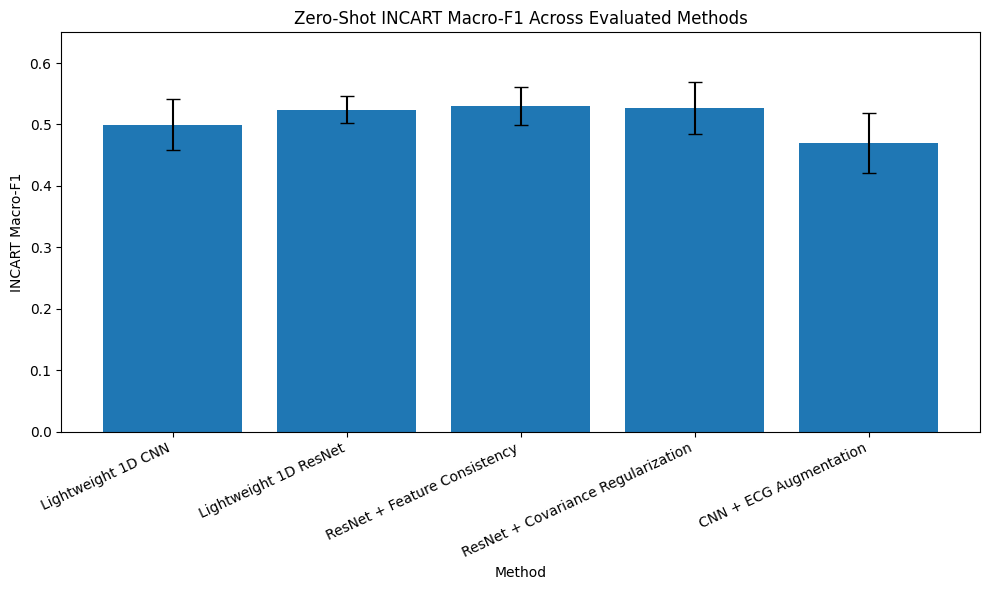

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/figure_incart_macro_f1_methods.png


In [ ]:
import matplotlib.pyplot as plt
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

methods = [
    "Lightweight 1D CNN",
    "Lightweight 1D ResNet",
    "ResNet + Feature Consistency",
    "ResNet + Covariance Regularization",
    "CNN + ECG Augmentation"
]

means = [0.499685, 0.524201, 0.529795, 0.526895, 0.470031]
sds = [0.041540, 0.022192, 0.030871, 0.042167, 0.048234]

plt.figure(figsize=(10, 6))
plt.bar(methods, means, yerr=sds, capsize=5)
plt.ylabel("INCART Macro-F1")
plt.xlabel("Method")
plt.title("Zero-Shot INCART Macro-F1 Across Evaluated Methods")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 0.65)
plt.tight_layout()

output_path = os.path.join(
    results_path,
    "figure_incart_macro_f1_methods.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

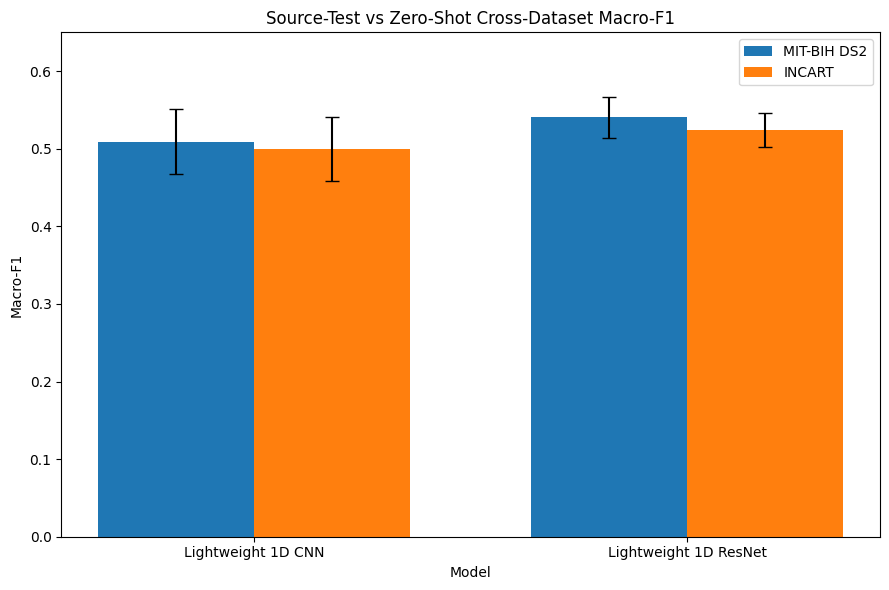

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/figure_ds2_vs_incart_macro_f1.png


In [ ]:
import matplotlib.pyplot as plt
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

models = ["Lightweight 1D CNN", "Lightweight 1D ResNet"]

ds2_mean = [0.508969, 0.540276]
ds2_sd = [0.042092, 0.025865]

incart_mean = [0.499685, 0.524201]
incart_sd = [0.041540, 0.022192]

x = range(len(models))
width = 0.36

plt.figure(figsize=(9, 6))

plt.bar(
    [i - width/2 for i in x],
    ds2_mean,
    width,
    yerr=ds2_sd,
    capsize=5,
    label="MIT-BIH DS2"
)

plt.bar(
    [i + width/2 for i in x],
    incart_mean,
    width,
    yerr=incart_sd,
    capsize=5,
    label="INCART"
)

plt.ylabel("Macro-F1")
plt.xlabel("Model")
plt.title("Source-Test vs Zero-Shot Cross-Dataset Macro-F1")
plt.xticks(list(x), models)
plt.ylim(0, 0.65)
plt.legend()
plt.tight_layout()

output_path = os.path.join(
    results_path,
    "figure_ds2_vs_incart_macro_f1.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

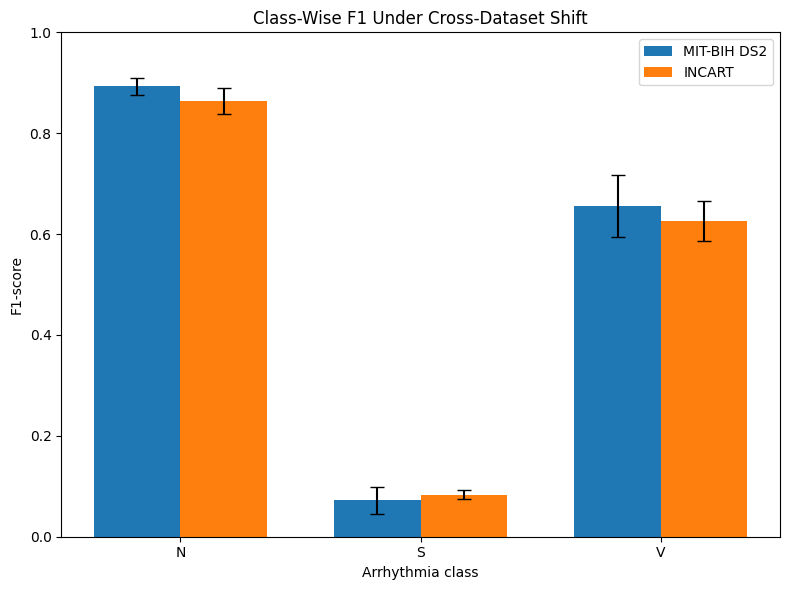

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/figure_classwise_domain_shift.png


In [ ]:
import matplotlib.pyplot as plt
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

classes = ["N", "S", "V"]

ds2_mean = [0.8928, 0.0721, 0.6558]
ds2_sd = [0.0171, 0.0273, 0.0614]

incart_mean = [0.8635, 0.0835, 0.6256]
incart_sd = [0.0256, 0.0090, 0.0395]

x = range(len(classes))
width = 0.36

plt.figure(figsize=(8, 6))

plt.bar(
    [i - width/2 for i in x],
    ds2_mean,
    width,
    yerr=ds2_sd,
    capsize=5,
    label="MIT-BIH DS2"
)

plt.bar(
    [i + width/2 for i in x],
    incart_mean,
    width,
    yerr=incart_sd,
    capsize=5,
    label="INCART"
)

plt.ylabel("F1-score")
plt.xlabel("Arrhythmia class")
plt.title("Class-Wise F1 Under Cross-Dataset Shift")
plt.xticks(list(x), classes)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

output_path = os.path.join(
    results_path,
    "figure_classwise_domain_shift.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

In [ ]:
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

print("Results folder exists:", os.path.exists(results_path))

if os.path.exists(results_path):
    print("\nCurrent saved artifacts:")
    for filename in sorted(os.listdir(results_path)):
        print("✓", filename)

Results folder exists: True

Current saved artifacts:
✓ X_ds1.npy
✓ X_ds2.npy
✓ aug_cnn_seed123_results.json
✓ aug_cnn_seed42_results.json
✓ aug_cnn_seed456_results.json
✓ augmentation_negative_result_summary.json
✓ checkpoint_manifest.json
✓ cnn_incart_results.csv
✓ cov_resnet_seed123_results.json
✓ cov_resnet_seed42_results.json
✓ cov_resnet_seed456_results.json
✓ dg_experiment_config.json
✓ efficiency_results.csv
✓ experiment_protocol.json
✓ experiment_summary.json
✓ figure_classwise_domain_shift.png
✓ figure_ds2_vs_incart_macro_f1.png
✓ figure_incart_macro_f1_methods.png
✓ final_generalization_comparison.csv
✓ master_experiment_results.csv
✓ multi_seed_generalization.csv
✓ resnet_classwise_f1_gap.csv
✓ resnet_incart_results.csv
✓ resnet_seed123.pt
✓ resnet_seed42.pt
✓ resnet_seed456.pt
✓ table_baseline_performance.csv
✓ table_classwise_domain_shift.csv
✓ table_generalization_methods.csv
✓ table_model_efficiency.csv
✓ y_ds1.npy
✓ y_ds2.npy


In [ ]:
import os
import tempfile

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
test_path = os.path.join(results_path, "_write_test.txt")

print("Folder exists:", os.path.exists(results_path))

try:
    with open(test_path, "w") as f:
        f.write("Drive write test")
    print("Drive writable:", True)
    print("Test file exists:", os.path.exists(test_path))
    os.remove(test_path)
except Exception as e:
    print("Drive writable:", False)
    print("Error:", repr(e))


Folder exists: True
Drive writable: True
Test file exists: True


In [ ]:
import matplotlib.pyplot as plt
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

models = ["Lightweight 1D CNN", "Lightweight 1D ResNet"]
parameters = [9347, 28115]
macro_f1 = [0.499685, 0.524201]

plt.figure(figsize=(8, 6))
plt.scatter(parameters, macro_f1, s=100)

for model, x, y in zip(models, parameters, macro_f1):
    plt.annotate(
        model,
        (x, y),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Trainable parameters")
plt.ylabel("INCART Macro-F1")
plt.title("Model Complexity vs Zero-Shot INCART Performance")
plt.tight_layout()

output_path = os.path.join(
    results_path,
    "figure_efficiency_vs_incart_macro_f1.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/figure_efficiency_vs_incart_macro_f1.png


In [ ]:
import numpy as np
from scipy.stats import ttest_rel, wilcoxon
import os
import json

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

baseline = np.array([0.523613, 0.546682, 0.502309])
feature_consistency = np.array([0.563925, 0.503821, 0.521640])

difference = feature_consistency - baseline

t_stat, t_p = ttest_rel(feature_consistency, baseline)
w_stat, w_p = wilcoxon(feature_consistency, baseline)

stats = {
    "comparison": "Baseline ResNet vs ResNet + Feature Consistency",
    "metric": "INCART Macro-F1",
    "seeds": [42, 123, 456],
    "baseline_mean": float(baseline.mean()),
    "baseline_sd": float(baseline.std(ddof=1)),
    "feature_consistency_mean": float(feature_consistency.mean()),
    "feature_consistency_sd": float(feature_consistency.std(ddof=1)),
    "mean_change": float(difference.mean()),
    "change_sd": float(difference.std(ddof=1)),
    "improved_seeds": int(np.sum(difference > 0)),
    "decreased_seeds": int(np.sum(difference < 0)),
    "paired_t_test": {
        "statistic": float(t_stat),
        "p_value": float(t_p)
    },
    "wilcoxon_signed_rank": {
        "statistic": float(w_stat),
        "p_value": float(w_p)
    },
    "interpretation": "The feature-consistency method has a small positive mean change, but the improvement is not statistically significant across the three seeds."
}

output_path = os.path.join(
    results_path,
    "statistical_comparison_feature_consistency.json"
)

with open(output_path, "w") as f:
    json.dump(stats, f, indent=2)

print(json.dumps(stats, indent=2))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

{
  "comparison": "Baseline ResNet vs ResNet + Feature Consistency",
  "metric": "INCART Macro-F1",
  "seeds": [
    42,
    123,
    456
  ],
  "baseline_mean": 0.5242013333333334,
  "baseline_sd": 0.02219234968031401,
  "feature_consistency_mean": 0.5297953333333334,
  "feature_consistency_sd": 0.03087077582979305,
  "mean_change": 0.005593999999999988,
  "change_sd": 0.043254662858471134,
  "improved_seeds": 2,
  "decreased_seeds": 1,
  "paired_t_test": {
    "statistic": 0.2240011036322928,
    "p_value": 0.8435575772353678
  },
  "wilcoxon_signed_rank": {
    "statistic": 3.0,
    "p_value": 1.0
  },
  "interpretation": "The feature-consistency method has a small positive mean change, but the improvement is not statistically significant across the three seeds."
}

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/statistical_comparison_feature_consistency.json


In [ ]:
import pandas as pd
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

stats_table = pd.DataFrame([
    {
        "Comparison": "Baseline ResNet vs Feature Consistency",
        "Baseline Macro-F1": "0.5242 ± 0.0222",
        "Feature Consistency Macro-F1": "0.5298 ± 0.0309",
        "Mean Change": "+0.0056",
        "Improved Seeds": "2/3",
        "Paired t-test p": 0.8436,
        "Wilcoxon p": 1.0000,
        "Conclusion": "Not statistically significant"
    }
])

output_path = os.path.join(
    results_path,
    "table_statistical_comparison.csv"
)

stats_table.to_csv(output_path, index=False)

print(stats_table.to_string(index=False))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

                            Comparison Baseline Macro-F1 Feature Consistency Macro-F1 Mean Change Improved Seeds  Paired t-test p  Wilcoxon p                    Conclusion
Baseline ResNet vs Feature Consistency   0.5242 ± 0.0222              0.5298 ± 0.0309     +0.0056            2/3           0.8436         1.0 Not statistically significant

Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/table_statistical_comparison.csv


In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

methods_record = {
    "project": "Cross-Dataset Generalization of Lightweight Deep Learning Models for ECG Arrhythmia Classification",
    "source_dataset": "MIT-BIH Arrhythmia Database",
    "source_training_split": "DS1",
    "source_test_split": "DS2",
    "target_dataset": "INCART",
    "evaluation_protocol": "Zero-shot cross-dataset evaluation",
    "target_training": False,
    "target_validation": False,
    "target_finetuning": False,
    "target_model_selection": False,
    "target_labels_used": False,
    "models": [
        "Lightweight 1D CNN",
        "Lightweight 1D ResNet"
    ],
    "classes": ["N", "S", "V"],
    "beat_window_samples": 256,
    "sampling_rate_hz": 360,
    "random_seeds": [42, 123, 456],
    "primary_metric": "Macro-F1",
    "secondary_metrics": [
        "Accuracy",
        "Per-class precision",
        "Per-class recall",
        "Per-class F1",
        "Confusion matrix"
    ],
    "efficiency_metrics": [
        "Parameter count",
        "Model size",
        "FLOPs/MACs",
        "CPU latency"
    ],
    "source_only_extensions": [
        "ECG augmentation",
        "Feature consistency",
        "Covariance regularization"
    ]
}

output_path = os.path.join(
    results_path,
    "methods_experimental_protocol.json"
)

with open(output_path, "w") as f:
    json.dump(methods_record, f, indent=2)

print(json.dumps(methods_record, indent=2))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

{
  "project": "Cross-Dataset Generalization of Lightweight Deep Learning Models for ECG Arrhythmia Classification",
  "source_dataset": "MIT-BIH Arrhythmia Database",
  "source_training_split": "DS1",
  "source_test_split": "DS2",
  "target_dataset": "INCART",
  "evaluation_protocol": "Zero-shot cross-dataset evaluation",
  "target_training": false,
  "target_validation": false,
  "target_finetuning": false,
  "target_model_selection": false,
  "target_labels_used": false,
  "models": [
    "Lightweight 1D CNN",
    "Lightweight 1D ResNet"
  ],
  "classes": [
    "N",
    "S",
    "V"
  ],
  "beat_window_samples": 256,
  "sampling_rate_hz": 360,
  "random_seeds": [
    42,
    123,
    456
  ],
  "primary_metric": "Macro-F1",
  "secondary_metrics": [
    "Accuracy",
    "Per-class precision",
    "Per-class recall",
    "Per-class F1",
    "Confusion matrix"
  ],
  "efficiency_metrics": [
    "Parameter count",
    "Model size",
    "FLOPs/MACs",
    "CPU latency"
  ],
  "source_only_

In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

preprocessing_record = {
    "representation": "Single-lead ECG",
    "lead_selection": {
        "MIT-BIH": "MLII when available, otherwise II",
        "INCART": "Lead II"
    },
    "sampling_rate": {
        "MIT-BIH_original_hz": 360,
        "INCART_original_hz": 257,
        "common_rate_hz": 360,
        "INCART_resampling": "257 Hz to 360 Hz using polyphase resampling"
    },
    "beat_extraction": {
        "window_length_samples": 256,
        "samples_before_annotation": 128,
        "samples_after_annotation": 128
    },
    "filtering": {
        "type": "Butterworth band-pass",
        "order": 4,
        "low_cutoff_hz": 0.5,
        "high_cutoff_hz": 45.0,
        "phase": "Zero-phase filtering"
    },
    "normalization": {
        "method": "Per-beat z-score normalization",
        "formula": "(x - mean(x)) / (std(x) + 1e-8)"
    },
    "label_mapping": {
        "N": ["N", "L", "R", "e", "j"],
        "S": ["A", "a", "J", "S"],
        "V": ["V", "E"]
    },
    "classes_used": ["N", "S", "V"],
    "excluded_classes": "F and Q were not included because of extreme sparsity in the target dataset."
}

output_path = os.path.join(
    results_path,
    "methods_preprocessing_and_label_mapping.json"
)

with open(output_path, "w") as f:
    json.dump(preprocessing_record, f, indent=2)

print(json.dumps(preprocessing_record, indent=2))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

{
  "representation": "Single-lead ECG",
  "lead_selection": {
    "MIT-BIH": "MLII when available, otherwise II",
    "INCART": "Lead II"
  },
  "sampling_rate": {
    "MIT-BIH_original_hz": 360,
    "INCART_original_hz": 257,
    "common_rate_hz": 360,
    "INCART_resampling": "257 Hz to 360 Hz using polyphase resampling"
  },
  "beat_extraction": {
    "window_length_samples": 256,
    "samples_before_annotation": 128,
    "samples_after_annotation": 128
  },
  "filtering": {
    "type": "Butterworth band-pass",
    "order": 4,
    "low_cutoff_hz": 0.5,
    "high_cutoff_hz": 45.0,
    "phase": "Zero-phase filtering"
  },
  "normalization": {
    "method": "Per-beat z-score normalization",
    "formula": "(x - mean(x)) / (std(x) + 1e-8)"
  },
  "label_mapping": {
    "N": [
      "N",
      "L",
      "R",
      "e",
      "j"
    ],
    "S": [
      "A",
      "a",
      "J",
      "S"
    ],
    "V": [
      "V",
      "E"
    ]
  },
  "classes_used": [
    "N",
    "S",
    "V"
  

In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

model_training_record = {
    "models": {
        "Lightweight 1D CNN": {
            "architecture": [
                "Conv1D 1->16, kernel 7",
                "BatchNorm1D",
                "ReLU",
                "MaxPool1D 2",
                "Conv1D 16->32, kernel 5",
                "BatchNorm1D",
                "ReLU",
                "MaxPool1D 2",
                "Conv1D 32->64, kernel 3",
                "BatchNorm1D",
                "ReLU",
                "AdaptiveAvgPool1D to 1",
                "Linear 64->3"
            ],
            "trainable_parameters": 9347
        },
        "Lightweight 1D ResNet": {
            "architecture": [
                "Conv1D 1->16, kernel 7",
                "BatchNorm1D",
                "ReLU",
                "MaxPool1D 2",
                "Residual block 16->16",
                "Residual block 16->32 with stride 2",
                "Residual block 32->64 with stride 2",
                "AdaptiveAvgPool1D to 1",
                "Linear 64->3"
            ],
            "trainable_parameters": 28115
        }
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "epochs": 10,
        "batch_size": 128,
        "loss": "Class-weighted cross-entropy",
        "class_weight_source": "Inverse-frequency weights calculated from MIT-BIH DS1",
        "random_seeds": [42, 123, 456]
    },
    "input": {
        "channels": 1,
        "samples": 256,
        "tensor_shape": "[batch, 1, 256]"
    }
}

output_path = os.path.join(
    results_path,
    "methods_model_architecture_and_training.json"
)

with open(output_path, "w") as f:
    json.dump(model_training_record, f, indent=2)

print(json.dumps(model_training_record, indent=2))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

{
  "models": {
    "Lightweight 1D CNN": {
      "architecture": [
        "Conv1D 1->16, kernel 7",
        "BatchNorm1D",
        "ReLU",
        "MaxPool1D 2",
        "Conv1D 16->32, kernel 5",
        "BatchNorm1D",
        "ReLU",
        "MaxPool1D 2",
        "Conv1D 32->64, kernel 3",
        "BatchNorm1D",
        "ReLU",
        "AdaptiveAvgPool1D to 1",
        "Linear 64->3"
      ],
      "trainable_parameters": 9347
    },
    "Lightweight 1D ResNet": {
      "architecture": [
        "Conv1D 1->16, kernel 7",
        "BatchNorm1D",
        "ReLU",
        "MaxPool1D 2",
        "Residual block 16->16",
        "Residual block 16->32 with stride 2",
        "Residual block 32->64 with stride 2",
        "AdaptiveAvgPool1D to 1",
        "Linear 64->3"
      ],
      "trainable_parameters": 28115
    }
  },
  "training": {
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "epochs": 10,
    "batch_size": 128,
    "loss": "Class-weighted cross-entropy",
    "class_w

In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

evaluation_record = {
    "primary_metric": {
        "name": "Macro-F1",
        "reason": "Primary metric selected because of substantial class imbalance."
    },
    "secondary_metrics": [
        "Accuracy",
        "Per-class precision",
        "Per-class recall",
        "Per-class F1",
        "Confusion matrix"
    ],
    "cross_dataset_evaluation": {
        "source_test": "MIT-BIH DS2",
        "target_test": "INCART",
        "target_training": False,
        "target_validation": False,
        "target_finetuning": False,
        "target_model_selection": False
    },
    "random_seeds": [42, 123, 456],
    "reported_statistics": [
        "Mean",
        "Sample standard deviation"
    ],
    "efficiency_measurement": {
        "metrics": [
            "Trainable parameter count",
            "Model size",
            "FLOPs",
            "MACs",
            "CPU inference latency"
        ],
        "latency_note": "CPU latency is environment-specific and is not interpreted as a direct wearable deployment measurement."
    },
    "feature_consistency_comparison": {
        "comparison": "Baseline ResNet vs ResNet + Feature Consistency",
        "paired_t_test": True,
        "wilcoxon_signed_rank_test": True,
        "number_of_seeds": 3,
        "interpretation": "Exploratory due to the small number of seeds; no statistically significant improvement was observed."
    }
}

output_path = os.path.join(
    results_path,
    "methods_evaluation_statistics_and_efficiency.json"
)

with open(output_path, "w") as f:
    json.dump(evaluation_record, f, indent=2)

print(json.dumps(evaluation_record, indent=2))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

{
  "primary_metric": {
    "name": "Macro-F1",
    "reason": "Primary metric selected because of substantial class imbalance."
  },
  "secondary_metrics": [
    "Accuracy",
    "Per-class precision",
    "Per-class recall",
    "Per-class F1",
    "Confusion matrix"
  ],
  "cross_dataset_evaluation": {
    "source_test": "MIT-BIH DS2",
    "target_test": "INCART",
    "target_training": false,
    "target_validation": false,
    "target_finetuning": false,
    "target_model_selection": false
  },
  "random_seeds": [
    42,
    123,
    456
  ],
  "reported_statistics": [
    "Mean",
    "Sample standard deviation"
  ],
  "efficiency_measurement": {
    "metrics": [
      "Trainable parameter count",
      "Model size",
      "FLOPs",
      "MACs",
      "CPU inference latency"
    ],
    "latency_note": "CPU latency is environment-specific and is not interpreted as a direct wearable deployment measurement."
  },
  "feature_consistency_comparison": {
    "comparison": "Baseline ResNet

In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

methods_outline = {
    "1_Study_design": [
        "Cross-dataset evaluation of lightweight deep-learning models for ECG arrhythmia classification",
        "Source-only training on MIT-BIH DS1",
        "Source test evaluation on MIT-BIH DS2",
        "Zero-shot evaluation on INCART",
        "INCART not used for training, validation, fine-tuning, or model selection"
    ],
    "2_Datasets_and_class_definition": [
        "MIT-BIH Arrhythmia Database",
        "INCART",
        "Three-class classification: N, S, V",
        "F and Q excluded because of extreme target-domain sparsity"
    ],
    "3_Preprocessing": [
        "Single-lead ECG representation",
        "MLII when available, otherwise II for MIT-BIH",
        "Lead II for INCART",
        "INCART resampled from 257 Hz to 360 Hz",
        "256-sample beat window centered on annotation",
        "4th-order 0.5–45 Hz Butterworth band-pass filtering",
        "Per-beat z-score normalization"
    ],
    "4_Model_architectures": [
        "Lightweight 1D CNN with 9,347 trainable parameters",
        "Lightweight 1D ResNet with 28,115 trainable parameters"
    ],
    "5_Training": [
        "Adam optimizer",
        "Learning rate 0.001",
        "10 training epochs",
        "Batch size 128",
        "Class-weighted cross-entropy",
        "Inverse-frequency class weights derived from MIT-BIH DS1",
        "Random seeds 42, 123, 456"
    ],
    "6_Evaluation": [
        "Macro-F1 as primary metric",
        "Accuracy and class-wise precision, recall, and F1 as secondary metrics",
        "Three-seed mean and sample standard deviation"
    ],
    "7_Efficiency_analysis": [
        "Trainable parameter count",
        "Model size",
        "FLOPs and MACs",
        "CPU inference latency"
    ],
    "8_Domain_generalization_experiments": [
        "Source-only ECG augmentation",
        "Source-only feature consistency",
        "Source-only covariance regularization",
        "Target data and labels excluded from all training and model-selection procedures"
    ],
    "9_Statistical_analysis": [
        "Paired t-test for baseline ResNet versus feature consistency",
        "Wilcoxon signed-rank test",
        "Three seeds treated as exploratory due to small sample size"
    ]
}

output_path = os.path.join(
    results_path,
    "methods_section_outline.json"
)

with open(output_path, "w") as f:
    json.dump(methods_outline, f, indent=2)

print(json.dumps(methods_outline, indent=2))
print("\nSaved successfully:", os.path.exists(output_path))
print("Path:", output_path)

{
  "1_Study_design": [
    "Cross-dataset evaluation of lightweight deep-learning models for ECG arrhythmia classification",
    "Source-only training on MIT-BIH DS1",
    "Source test evaluation on MIT-BIH DS2",
    "Zero-shot evaluation on INCART",
    "INCART not used for training, validation, fine-tuning, or model selection"
  ],
  "2_Datasets_and_class_definition": [
    "MIT-BIH Arrhythmia Database",
    "INCART",
    "Three-class classification: N, S, V",
    "F and Q excluded because of extreme target-domain sparsity"
  ],
  "3_Preprocessing": [
    "Single-lead ECG representation",
    "MLII when available, otherwise II for MIT-BIH",
    "Lead II for INCART",
    "INCART resampled from 257 Hz to 360 Hz",
    "256-sample beat window centered on annotation",
    "4th-order 0.5\u201345 Hz Butterworth band-pass filtering",
    "Per-beat z-score normalization"
  ],
  "4_Model_architectures": [
    "Lightweight 1D CNN with 9,347 trainable parameters",
    "Lightweight 1D ResNet wit

In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

master_results = {
    "baseline": {
        "CNN": {
            "MIT_BIH_DS2": {
                "accuracy_mean": 0.825172,
                "accuracy_sd": 0.069520,
                "macro_f1_mean": 0.508969,
                "macro_f1_sd": 0.042092
            },
            "INCART_zero_shot": {
                "accuracy_mean": 0.782023,
                "accuracy_sd": 0.097247,
                "macro_f1_mean": 0.499685,
                "macro_f1_sd": 0.041540
            }
        },
        "ResNet": {
            "MIT_BIH_DS2": {
                "accuracy_mean": 0.817423,
                "accuracy_sd": 0.026253,
                "macro_f1_mean": 0.540276,
                "macro_f1_sd": 0.025865
            },
            "INCART_zero_shot": {
                "accuracy_mean": 0.775650,
                "accuracy_sd": 0.033982,
                "macro_f1_mean": 0.524201,
                "macro_f1_sd": 0.022192
            }
        }
    },
    "generalization_methods": {
        "ResNet_feature_consistency": {
            "INCART_macro_f1_mean": 0.529795,
            "INCART_macro_f1_sd": 0.030871,
            "change_vs_ResNet_baseline": 0.005594,
            "improved_seeds": "2/3",
            "statistically_significant": False
        },
        "ResNet_covariance_regularization": {
            "INCART_macro_f1_mean": 0.526895,
            "INCART_macro_f1_sd": 0.042167,
            "change_vs_ResNet_baseline": 0.002694
        },
        "CNN_ECG_augmentation": {
            "INCART_macro_f1_mean": 0.470031,
            "INCART_macro_f1_sd": 0.048234,
            "change_vs_CNN_baseline": -0.029655
        }
    },
    "efficiency": {
        "CNN": {
            "parameters": 9347,
            "model_size_MB": 0.036533,
            "FLOPs": 803072,
            "MACs": 401536,
            "CPU_latency_ms_per_sample": 0.767802
        },
        "ResNet": {
            "parameters": 28115,
            "model_size_MB": 0.109882,
            "FLOPs": 1292544,
            "MACs": 646272,
            "CPU_latency_ms_per_sample": 2.680134
        }
    },
    "statistical_test_feature_consistency": {
        "paired_t_test_p": 0.8435576,
        "wilcoxon_p": 1.0,
        "n_seeds": 3,
        "conclusion": "No statistically significant improvement"
    }
}

output_path = os.path.join(
    results_path,
    "master_results_locked_for_paper.json"
)

with open(output_path, "w") as f:
    json.dump(master_results, f, indent=2)

print("Master results locked successfully:", os.path.exists(output_path))
print("Path:", output_path)

Master results locked successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/master_results_locked_for_paper.json


In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

results_outline = {
    "1_baseline_performance": [
        "Compare lightweight CNN and lightweight ResNet on MIT-BIH DS2",
        "Report mean and sample standard deviation across three seeds",
        "Report zero-shot INCART performance"
    ],
    "2_cross_dataset_domain_shift": [
        "Compare MIT-BIH DS2 and INCART performance",
        "Report accuracy and Macro-F1 changes",
        "Analyze class-wise N, S and V behavior",
        "Interpret confusion matrices"
    ],
    "3_model_efficiency": [
        "Compare trainable parameters",
        "Compare model size",
        "Compare FLOPs and MACs",
        "Compare CPU inference latency",
        "Relate efficiency to zero-shot INCART Macro-F1"
    ],
    "4_generalization_improvement": [
        "ResNet + feature consistency",
        "ResNet + covariance regularization",
        "CNN + ECG augmentation",
        "Compare methods against corresponding baselines",
        "Report seed-level and mean changes",
        "Report exploratory statistical tests for feature consistency"
    ],
    "5_key_findings": [
        "Identify the strongest baseline model",
        "Characterize cross-dataset generalization",
        "Identify class-specific weaknesses",
        "Assess efficiency-generalization trade-off",
        "Assess whether source-only generalization methods produced consistent gains"
    ]
}

output_path = os.path.join(
    results_path,
    "results_section_outline.json"
)

with open(output_path, "w") as f:
    json.dump(results_outline, f, indent=2)

print("Results outline saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Results outline saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/results_section_outline.json


In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))
print("Results folder:", os.path.exists(results_path))

Mounted at /content/drive
Drive mounted: True
Results folder: True


In [ ]:
from google.colab import drive
import os
import json

drive.mount("/content/drive", force_remount=True)

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

baseline_performance = {
    "title": "Baseline Performance",
    "paragraphs": [
        "The two lightweight models were first evaluated on the held-out MIT-BIH DS2 split and subsequently evaluated without any target-domain adaptation on INCART. Across three random seeds, the lightweight 1D CNN achieved a mean accuracy of 82.52% ± 6.95% and a mean Macro-F1 of 0.509 ± 0.042 on MIT-BIH DS2. The lightweight 1D ResNet achieved a mean accuracy of 81.74% ± 2.63% and a mean Macro-F1 of 0.540 ± 0.026. Although the CNN obtained slightly higher mean accuracy on the source-dataset test split, the ResNet achieved the higher Macro-F1, indicating more balanced performance across the three classes.",
        "Under zero-shot evaluation on INCART, the CNN obtained a mean accuracy of 78.20% ± 9.72% and a mean Macro-F1 of 0.500 ± 0.042. The ResNet obtained a mean accuracy of 77.57% ± 3.40% and a mean Macro-F1 of 0.524 ± 0.022. The ResNet therefore maintained the stronger Macro-F1 performance on the unseen dataset, while also showing substantially lower seed-to-seed variation in accuracy than the CNN.",
        "Overall, the results indicate that both lightweight architectures retained a substantial portion of their source-dataset performance during zero-shot evaluation on INCART. However, the Macro-F1 results show that accuracy alone does not fully characterize cross-dataset behavior, motivating the subsequent class-wise and confusion-matrix analysis."
    ]
}

output_path = os.path.join(results_path, "results_baseline_performance.json")

with open(output_path, "w") as f:
    json.dump(baseline_performance, f, indent=2)

print("Saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Mounted at /content/drive
Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/results_baseline_performance.json


In [ ]:
from google.colab import drive
import json
import os

drive.mount("/content/drive", force_remount=True)

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

domain_shift = {
    "title": "Cross-Dataset Domain Shift",
    "paragraphs": [
        "To quantify cross-dataset generalization, the performance of each baseline model on the held-out MIT-BIH DS2 split was compared with its zero-shot performance on INCART. The lightweight CNN showed a decrease of 4.31 percentage points in mean accuracy, from 82.52% to 78.20%, while its Macro-F1 changed from 0.509 to 0.500, corresponding to a decrease of 0.93 percentage points. The lightweight ResNet showed a decrease of 4.18 percentage points in mean accuracy, from 81.74% to 77.57%, while Macro-F1 changed from 0.540 to 0.524, corresponding to a decrease of 1.61 percentage points.",
        "The class-wise results for the ResNet indicate that the domain shift did not affect all classes uniformly. Mean F1 for the N class decreased from 0.893 on MIT-BIH DS2 to 0.864 on INCART, while V-class F1 decreased from 0.656 to 0.626. In contrast, S-class F1 increased slightly from 0.072 to 0.084, but remained very low in both datasets. Therefore, the S class should be interpreted as a persistent classification difficulty rather than as a class experiencing a clear additional F1 degradation on INCART.",
        "The row-normalized confusion matrices provide further evidence of a change in decision behavior. For the N class, the mean correct-classification rate decreased from approximately 83.9% on MIT-BIH DS2 to 77.6% on INCART, with more N beats being assigned to S or V. For V, the correct-classification rate decreased from approximately 91.9% to 79.9%, accompanied by increased confusion with both N and S. The S-class correct-classification rate increased from approximately 11.9% to 50.1%; however, S precision remained extremely low because a substantial number of N beats were also predicted as S.",
        "These results suggest that cross-dataset shift primarily changes the models' class decision behavior rather than producing a uniform collapse in performance. The relatively modest changes in overall Macro-F1 coexist with substantial changes in class-specific confusion patterns, demonstrating why class-wise metrics and confusion matrices are important for evaluating ECG models under dataset shift."
    ]
}

output_path = os.path.join(
    results_path,
    "results_cross_dataset_domain_shift.json"
)

with open(output_path, "w") as f:
    json.dump(domain_shift, f, indent=2)

print("Saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Mounted at /content/drive
Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/results_cross_dataset_domain_shift.json


In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

efficiency = {
    "title": "Model Efficiency",
    "paragraphs": [
        "The computational efficiency of the two lightweight architectures was assessed using trainable parameter count, model size, FLOPs, MACs, and CPU inference latency. The lightweight 1D CNN contained 9,347 trainable parameters, had a model size of approximately 0.0365 MB, and required 803,072 FLOPs (401,536 MACs) for a single 256-sample input. Its measured CPU inference latency was approximately 0.768 ms per sample.",
        "The lightweight 1D ResNet contained 28,115 trainable parameters, corresponding to a model size of approximately 0.1099 MB. Its computational requirement was 1,292,544 FLOPs (646,272 MACs) per input, with a measured CPU inference latency of approximately 2.680 ms per sample.",
        "Relative to the CNN, the ResNet used approximately three times as many trainable parameters and had approximately 61% higher FLOPs. Its measured CPU latency was approximately 3.5 times higher. Despite this additional computational cost, the ResNet achieved a 2.45-percentage-point higher mean Macro-F1 than the CNN on zero-shot INCART evaluation (0.524 versus 0.500).",
        "These measurements indicate a trade-off between computational efficiency and cross-dataset classification performance. The CNN provides the smaller and faster architecture, whereas the ResNet provides stronger zero-shot Macro-F1 performance. The efficiency measurements represent software-level computational characteristics under the reported evaluation environment and should not be interpreted as direct evidence of deployment performance on a specific wearable or embedded device."
    ],
    "metrics": {
        "CNN": {
            "parameters": 9347,
            "model_size_MB": 0.036533,
            "FLOPs": 803072,
            "MACs": 401536,
            "CPU_latency_ms_per_sample": 0.767802,
            "INCART_macro_f1": 0.499685
        },
        "ResNet": {
            "parameters": 28115,
            "model_size_MB": 0.109882,
            "FLOPs": 1292544,
            "MACs": 646272,
            "CPU_latency_ms_per_sample": 2.680134,
            "INCART_macro_f1": 0.524201
        }
    }
}

output_path = os.path.join(results_path, "results_model_efficiency.json")

with open(output_path, "w") as f:
    json.dump(efficiency, f, indent=2)

print("Model Efficiency subsection saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Model Efficiency subsection saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/results_model_efficiency.json


In [ ]:
from google.colab import drive
import json
import os

drive.mount("/content/drive", force_remount=True)

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

generalization = {
    "title": "Generalization Improvement Experiments",
    "paragraphs": [
        "Three source-only strategies were evaluated to investigate whether cross-dataset generalization could be improved without using INCART data during training, validation, fine-tuning, or model selection: ECG augmentation with the lightweight CNN, feature consistency regularization with the lightweight ResNet, and covariance regularization with the lightweight ResNet.",
        "The feature-consistency approach produced the highest mean INCART Macro-F1 among the tested generalization extensions. Its mean Macro-F1 was 0.5298 ± 0.0309, compared with 0.5242 ± 0.0222 for the baseline ResNet, corresponding to a mean improvement of 0.0056. Performance improved for two of the three random seeds, while one seed showed a decrease. The paired t-test produced p = 0.8436 and the Wilcoxon signed-rank test produced p = 1.0000. Therefore, the observed improvement was not statistically significant and should be considered exploratory.",
        "Covariance regularization produced a mean INCART Macro-F1 of 0.5269 ± 0.0422, representing a small mean increase of 0.0027 over the baseline ResNet. The result was mixed across seeds and did not demonstrate a consistent improvement over the baseline.",
        "The source-only ECG augmentation experiment produced a mean INCART Macro-F1 of 0.4700 ± 0.0482 for the lightweight CNN, compared with 0.4997 ± 0.0415 for the corresponding CNN baseline. This represents a mean decrease of 0.0297 Macro-F1 points. Thus, the tested augmentation configuration did not improve zero-shot cross-dataset generalization.",
        "Overall, feature consistency provided the strongest mean result among the evaluated source-only generalization strategies, but the small effect size and limited number of random seeds prevent a strong claim of improvement. The experiments instead demonstrate that source-only regularization strategies can have different effects under dataset shift and that their effectiveness should be evaluated across multiple seeds rather than inferred from a single run."
    ]
}

output_path = os.path.join(
    results_path,
    "results_generalization_improvement.json"
)

with open(output_path, "w") as f:
    json.dump(generalization, f, indent=2)

print("Saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Mounted at /content/drive
Saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/results_generalization_improvement.json


In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

key_findings = {
    "title": "Key Findings",
    "paragraphs": [
        "Across the baseline experiments, the lightweight 1D ResNet provided the strongest Macro-F1 performance on both the held-out MIT-BIH DS2 split and the unseen INCART dataset, despite the lightweight CNN achieving slightly higher mean accuracy on MIT-BIH DS2. The ResNet achieved a mean Macro-F1 of 0.540 on MIT-BIH DS2 and 0.524 on zero-shot INCART, compared with 0.509 and 0.500 for the CNN, respectively.",
        "The cross-dataset evaluation showed that both models retained most of their overall source-domain performance on INCART, with mean accuracy decreases of approximately 4.3 percentage points for the CNN and 4.2 percentage points for the ResNet. However, the class-wise analysis revealed meaningful changes in decision behavior, particularly for the N and V classes, while the S class remained consistently difficult and exhibited very low F1 values.",
        "The efficiency analysis demonstrated a clear computational trade-off. The CNN was substantially smaller and faster, with 9,347 parameters and approximately 0.768 ms CPU latency per sample, whereas the ResNet used 28,115 parameters and approximately 2.680 ms per sample. The ResNet nevertheless provided a higher zero-shot INCART Macro-F1, suggesting that the additional computational cost was associated with a modest gain in cross-dataset classification performance.",
        "Among the source-only generalization strategies, feature consistency achieved the highest mean INCART Macro-F1 at 0.530, slightly above the baseline ResNet value of 0.524. Covariance regularization produced a similar but smaller improvement, while the tested ECG augmentation strategy reduced performance. The feature-consistency improvement was not statistically significant across the three seeds, so the result should be regarded as exploratory rather than conclusive.",
        "Taken together, the experiments show that lightweight ECG classifiers can retain substantial overall performance under zero-shot cross-dataset evaluation, but aggregate accuracy and Macro-F1 alone can conceal important class-specific changes. The results support evaluating lightweight ECG models using multiple random seeds, class-wise metrics, confusion matrices, and computational-efficiency measures when studying robustness to dataset shift."
    ]
}

output_path = os.path.join(
    results_path,
    "results_key_findings.json"
)

with open(output_path, "w") as f:
    json.dump(key_findings, f, indent=2)

print("Key Findings subsection saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Key Findings subsection saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/results_key_findings.json


In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

discussion_baseline = {
    "title": "Discussion: Baseline and Cross-Dataset Findings",
    "paragraphs": [
        "The primary objective of this study was to examine how lightweight ECG arrhythmia classifiers trained on one dataset behave when evaluated on an unseen dataset without target-domain adaptation. The baseline results show that both the lightweight 1D CNN and lightweight 1D ResNet retained substantial overall performance during zero-shot evaluation on INCART. The ResNet achieved a mean Macro-F1 of 0.524 on INCART compared with 0.540 on MIT-BIH DS2, while the CNN achieved 0.500 on INCART compared with 0.509 on MIT-BIH DS2.",

        "These results suggest that the dataset shift between MIT-BIH and INCART did not cause a uniform or catastrophic reduction in classification performance. Instead, the effect was more apparent in the distribution of class-level errors. For the ResNet, the mean F1 scores for the N and V classes decreased on INCART, while the S class remained difficult on both datasets. The very low S-class F1 indicates that class imbalance and class separability remain important challenges even when the overall Macro-F1 appears relatively stable.",

        "The confusion-matrix analysis further indicates that the cross-dataset shift altered the models' decision boundaries. On INCART, the model produced more confusion involving the N and V classes, while the S class showed a higher fraction of correct predictions but very low precision. This pattern suggests that the observed domain shift is not simply a reduction in the ability to recognize every class. Instead, changes in the signal distribution appear to modify how the model distributes predictions among the available classes.",

        "The results also highlight the importance of using Macro-F1 alongside accuracy in imbalanced ECG classification. The CNN achieved slightly higher mean accuracy than the ResNet on MIT-BIH DS2, but the ResNet obtained the higher Macro-F1. This difference indicates that accuracy alone can favor performance dominated by the majority N class and may not adequately represent behavior on minority arrhythmia classes.",

        "From a lightweight-model perspective, the ResNet provided the strongest cross-dataset Macro-F1 but required more parameters and computational resources than the CNN. This represents a practical trade-off rather than a simple winner-takes-all comparison: the CNN is more computationally efficient, whereas the ResNet provides stronger balanced classification performance under the evaluated dataset shift."
    ]
}

output_path = os.path.join(
    results_path,
    "discussion_baseline_cross_dataset.json"
)

with open(output_path, "w") as f:
    json.dump(discussion_baseline, f, indent=2)

print("Discussion subsection saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Discussion subsection saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/discussion_baseline_cross_dataset.json


In [ ]:
import json
import os

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

discussion_generalization = {
    "title": "Discussion: Generalization Improvement Experiments",
    "paragraphs": [
        "The source-only generalization experiments produced mixed results, indicating that improving cross-dataset robustness is not straightforward even when the target dataset is completely excluded from model development. Feature consistency produced the highest mean INCART Macro-F1 among the tested extensions, increasing the mean from 0.524 for the baseline ResNet to 0.530. However, the absolute improvement was small, occurred in only two of the three seeds, and was not statistically significant. Therefore, the experiment provides an exploratory indication rather than evidence of a reliable improvement.",

        "One possible interpretation is that feature consistency encourages the model to retain representations that are less sensitive to small input-level variations. This may help preserve useful ECG morphology under some forms of distribution shift. However, the small average gain and seed dependence indicate that the regularization strength and augmentation design may not have been sufficient to produce robust domain-invariant representations.",

        "Covariance regularization produced a similarly small improvement in mean INCART Macro-F1, from 0.524 to 0.527. The limited magnitude of this change and variation across seeds suggest that the regularization constraint did not consistently alter the learned representation in a way that improved zero-shot target performance. This result reinforces the need for multiple-seed evaluation when assessing proposed generalization techniques.",

        "The tested ECG augmentation strategy produced the opposite effect. The CNN Macro-F1 decreased from 0.500 for the baseline to 0.470 with augmentation. This suggests that the selected augmentation configuration may have introduced variations that were not beneficial for the cross-dataset characteristics represented by INCART. Importantly, this negative result should not be interpreted as evidence that ECG augmentation is generally ineffective; rather, it indicates that the specific source-only augmentation configuration evaluated in this study did not improve the investigated zero-shot setting.",

        "Taken together, the experiments suggest that source-only generalization methods require careful matching between the assumed augmentation or regularization effects and the actual sources of dataset variation. Because INCART was not used during training or model selection, the observed differences provide a genuinely held-out assessment of generalization behavior. At the same time, the small number of seeds limits the statistical strength of these comparisons and motivates larger repeated experiments in future work."
    ]
}

output_path = os.path.join(
    results_path,
    "discussion_generalization_experiments.json"
)

with open(output_path, "w") as f:
    json.dump(discussion_generalization, f, indent=2)

print("Discussion subsection saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Discussion subsection saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/discussion_generalization_experiments.json


In [ ]:
from google.colab import drive
import json
import os

drive.mount("/content/drive", force_remount=True)

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

discussion_literature = {
    "title": "Discussion: Positioning Relative to Prior Literature",
    "paragraphs": [
        "The findings should be interpreted in the context of a broader literature on ECG cross-dataset generalization. The reviewed studies show that several distinct transfer settings are often grouped under the broad term of generalization, including zero-shot cross-dataset evaluation, unsupervised domain adaptation, test-time adaptation, and label-efficient transfer. These settings are not directly equivalent because they differ in whether target-domain data or labels are available during model development.",

        "The present study adopts a strict zero-shot protocol in which the INCART dataset is excluded from training, validation, fine-tuning, and model selection and is used only for final evaluation and post hoc analysis. This makes the experiment more directly focused on out-of-dataset generalization than approaches that use unlabeled target data for domain alignment or a limited number of target labels for transfer learning.",

        "The literature synthesis also indicates that cross-dataset ECG performance can be affected by differences in lead configuration, sampling frequency, preprocessing, label mapping, and class distribution. The experimental design in this study explicitly standardizes several of these factors by using a common single-lead representation, resampling INCART from 257 Hz to 360 Hz, applying the same beat-window length and filtering procedure, and evaluating the common N/S/V classification problem.",

        "Prior work reviewed for this study also demonstrates that high in-dataset performance does not necessarily translate into equivalent cross-dataset performance and that minority classes can remain particularly difficult under dataset shift. The current experiments are consistent with this general observation: the overall ResNet Macro-F1 reduction from MIT-BIH DS2 to INCART was relatively modest, but the class-wise analysis showed changes in N and V performance and persistently weak S-class discrimination.",

        "The results therefore support a cautious interpretation of cross-dataset ECG robustness. Rather than presenting the work as the first study of cross-dataset ECG generalization, the contribution is better framed as a reproducible lightweight-model benchmark that combines a fixed zero-shot protocol, explicit preprocessing and label definitions, multi-seed evaluation, class-wise analysis, efficiency measurements, and exploratory source-only generalization experiments.",

        "This positioning is important because the reviewed literature contains studies using MIT-BIH, INCART, cross-lead settings, domain adaptation, and domain-generalization methods. The contribution of the present work is consequently methodological and evaluative: it emphasizes transparent experimental controls and reporting that make the behavior of lightweight models under dataset shift easier to interpret and reproduce."
    ]
}

output_path = os.path.join(
    results_path,
    "discussion_literature_positioning.json"
)

with open(output_path, "w") as f:
    json.dump(discussion_literature, f, indent=2)

print("Literature positioning subsection saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Mounted at /content/drive
Literature positioning subsection saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/discussion_literature_positioning.json


In [ ]:
from google.colab import drive
import json
import os

drive.mount("/content/drive", force_remount=True)

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

limitations = {
    "title": "Limitations",
    "paragraphs": [
        "Several limitations should be considered when interpreting the results. First, the experiments were repeated using three random seeds (42, 123, and 456). Although multi-seed evaluation provides an indication of variability, three repetitions are insufficient to establish strong statistical conclusions. The statistical comparison of the baseline ResNet and feature-consistency model should therefore be regarded as exploratory.",

        "Second, the classification task was restricted to three AAMI-derived classes: N, S, and V. The F and Q categories were excluded because of their extreme sparsity in the target-domain data. Consequently, the findings cannot be directly generalized to a complete multi-class ECG arrhythmia classification setting.",

        "Third, the MIT-BIH evaluation used a predefined record-based DS1/DS2 split. The split provides a held-out source-domain evaluation, but it should not be described as a strictly subject-independent partition without additional verification of subject-level separation.",

        "Fourth, the study used a single-lead representation. MIT-BIH records used MLII when available and otherwise Lead II, while Lead II was selected for INCART. Although this provides a controlled common representation, it does not capture the additional information available from multi-lead ECG recordings.",

        "Fifth, the cross-dataset evaluation was intentionally zero-shot. INCART was not used for training, validation, fine-tuning, or model selection. This strengthens the evaluation of out-of-dataset generalization but also means that the study does not investigate whether target-domain adaptation could recover performance lost under dataset shift.",

        "Finally, the efficiency measurements, particularly CPU inference latency, are dependent on the software and hardware environment used for measurement. Parameter count, FLOPs, and model size provide architecture-level indicators, but the reported latency should not be interpreted as a universal deployment-time measurement or as direct evidence of performance on a particular wearable or embedded device."
    ]
}

output_path = os.path.join(
    results_path,
    "discussion_limitations.json"
)

with open(output_path, "w") as f:
    json.dump(limitations, f, indent=2)

print("Limitations subsection saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Mounted at /content/drive
Limitations subsection saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/discussion_limitations.json


In [ ]:
from google.colab import drive
import json
import os

drive.mount("/content/drive", force_remount=True)

results_path = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
os.makedirs(results_path, exist_ok=True)

conclusion = {
    "title": "Conclusion",
    "paragraphs": [
        "This study investigated the cross-dataset generalization of lightweight deep-learning models for ECG arrhythmia classification using a source-only training protocol and zero-shot evaluation on an unseen target dataset. A lightweight 1D CNN and a lightweight 1D ResNet were trained on MIT-BIH DS1 and evaluated on the held-out MIT-BIH DS2 split and on INCART without target-domain training, fine-tuning, validation, or model selection.",

        "The results showed that both architectures retained substantial overall performance under zero-shot evaluation on INCART. The lightweight ResNet achieved the strongest mean Macro-F1 among the baseline models, with 0.540 on MIT-BIH DS2 and 0.524 on INCART. The class-wise analysis demonstrated that overall performance stability can coexist with meaningful changes in class-specific decision behavior, particularly for the N and V classes, while the S class remained a persistent classification challenge.",

        "The efficiency analysis demonstrated that the lightweight CNN offered a substantially smaller computational footprint, while the ResNet provided stronger zero-shot Macro-F1 at the cost of increased parameters, FLOPs, and CPU inference latency. This highlights the importance of considering both predictive performance and computational efficiency when selecting lightweight ECG architectures.",

        "Source-only generalization experiments produced mixed outcomes. Feature consistency achieved the highest mean INCART Macro-F1 among the tested extensions, but its improvement over the baseline ResNet was small and not statistically significant across the three evaluated seeds. Covariance regularization produced only a marginal improvement, while the tested ECG augmentation configuration reduced zero-shot performance.",

        "Overall, the study demonstrates the value of a controlled and reproducible evaluation framework for understanding lightweight ECG classifiers under dataset shift. The findings emphasize that cross-dataset robustness should be assessed using multiple seeds, class-wise metrics, confusion matrices, and efficiency measures rather than relying solely on in-dataset accuracy. Future work should investigate larger-scale repeated experiments, additional ECG datasets and leads, broader arrhythmia classes, and target-domain adaptation or domain-generalization methods designed around the specific sources of ECG distribution shift."
    ]
}

output_path = os.path.join(
    results_path,
    "conclusion.json"
)

with open(output_path, "w") as f:
    json.dump(conclusion, f, indent=2)

print("Conclusion saved successfully:", os.path.exists(output_path))
print("Path:", output_path)

Mounted at /content/drive
Conclusion saved successfully: True
Path: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/conclusion.json


In [ ]:
import os
import sys

print("=== RUNTIME CHECK ===")
print("Python:", sys.version.split()[0])

try:
    import torch

    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

except Exception as e:
    print("PyTorch check failed:", repr(e))

print("\n=== DATA PATH CHECK ===")

paths = {
    "Google Drive": "/content/drive/MyDrive",
    "MIT-BIH": "/content/mit_bih_data/1.0.0",
    "INCART": "/content/incart",
    "Research results": "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
}

for name, path in paths.items():
    print(f"{name}: {'FOUND' if os.path.exists(path) else 'NOT FOUND'}")

print("\n=== CHECK COMPLETE ===")

=== RUNTIME CHECK ===
Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

=== DATA PATH CHECK ===
Google Drive: FOUND
MIT-BIH: NOT FOUND
INCART: NOT FOUND
Research results: FOUND

=== CHECK COMPLETE ===


In [ ]:
import os

BASE_DRIVE = "/content/drive/MyDrive/ECG_Arrhythmia_Research"

print("=== DRIVE PROJECT CHECK ===")

for name in ["MIT-BIH", "INCART", "ecg_research_results"]:
    path = os.path.join(BASE_DRIVE, name)
    print(f"\n{name}: {'FOUND' if os.path.exists(path) else 'NOT FOUND'}")

    if os.path.exists(path):
        print("Contents:", os.listdir(path)[:15])

print("\n=== CHECK COMPLETE ===")

=== DRIVE PROJECT CHECK ===

MIT-BIH: NOT FOUND

INCART: NOT FOUND

ecg_research_results: FOUND
Contents: ['resnet_incart_results.csv', 'experiment_summary.json', 'multi_seed_generalization.csv', 'resnet_classwise_f1_gap.csv', 'efficiency_results.csv', 'cnn_incart_results.csv', 'experiment_protocol.json', 'checkpoint_manifest.json', 'resnet_seed456.pt', 'resnet_seed123.pt', 'resnet_seed42.pt', 'X_ds1.npy', 'y_ds1.npy', 'X_ds2.npy', 'y_ds2.npy']

=== CHECK COMPLETE ===


In [ ]:
!pip install wfdb -q
import wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.9 MB/s eta 0:00:00


In [ ]:
!wget -q -r -N -c -np -nH --cut-dirs=2 \
    https://physionet.org/files/mitdb/1.0.0/ \
    -P /content/mit_bih_data

print("MIT-BIH download completed.")

MIT-BIH download completed.


In [ ]:
import os

print("=== MIT-BIH DOWNLOAD CHECK ===")

base = "/content/mit_bih_data"

print("Base folder exists:", os.path.exists(base))

if os.path.exists(base):
    print("\nBase folder contents:")
    print(os.listdir(base)[:30])

    print("\nSearching for record 100 files...")

    found = []

    for root, dirs, files in os.walk(base):
        for filename in files:
            if filename.startswith("100."):
                found.append(os.path.join(root, filename))

    print("Found:", found)

print("\n=== CHECK COMPLETE ===")

=== MIT-BIH DOWNLOAD CHECK ===
Base folder exists: True

Base folder contents:
['robots.txt', '1.0.0']

Searching for record 100 files...
Found: ['/content/mit_bih_data/1.0.0/100.hea', '/content/mit_bih_data/1.0.0/100.xws', '/content/mit_bih_data/1.0.0/100.dat', '/content/mit_bih_data/1.0.0/100.atr']

=== CHECK COMPLETE ===


In [ ]:
import os
import wfdb

MIT_DATA_DIR = "/content/mit_bih_data/1.0.0"

record = wfdb.rdrecord(os.path.join(MIT_DATA_DIR, "100"))
annotation = wfdb.rdann(
    os.path.join(MIT_DATA_DIR, "100"),
    "atr"
)

print("MIT-BIH path:", os.path.exists(MIT_DATA_DIR))
print("Record 100 loaded:", record.sig_name)
print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)
print("Annotations:", len(annotation.sample))
print("First 5 annotation samples:", annotation.sample[:5])
print("First 5 annotation symbols:", annotation.symbol[:5])

MIT-BIH path: True
Record 100 loaded: ['MLII', 'V5']
Sampling frequency: 360
Signal shape: (650000, 2)
Annotations: 2274
First 5 annotation samples: [ 18  77 370 662 946]
First 5 annotation symbols: ['+', 'N', 'N', 'N', 'N']


In [ ]:
from collections import Counter

symbol_counts = Counter(annotation.symbol)

print("=== ANNOTATION SYMBOL CHECK ===")
print("Total annotations:", len(annotation.symbol))

print("\nMost common annotation symbols:")
for symbol, count in symbol_counts.most_common(20):
    print(f"{repr(symbol)} : {count}")

print("\nSymbols in our current N/S/V mapping:")
mapped = {
    symbol: count
    for symbol, count in symbol_counts.items()
    if symbol in MIT_AAMI_3CLASS
}

for symbol, count in sorted(mapped.items(), key=lambda x: -x[1]):
    print(f"{repr(symbol)} : {count}")

print("\nMapped beat annotations:", sum(mapped.values()))
print("=== CHECK COMPLETE ===")

=== ANNOTATION SYMBOL CHECK ===
Total annotations: 2274

Most common annotation symbols:
'N' : 2239
'A' : 33
'+' : 1
'V' : 1

Symbols in our current N/S/V mapping:
'N' : 2239
'A' : 33
'V' : 1

Mapped beat annotations: 2273
=== CHECK COMPLETE ===


In [ ]:
# Define standard beat annotation symbols used for RR calculation
import numpy as np
BEAT_SYMBOLS = {
    'N', 'L', 'R', 'B',
    'A', 'a', 'J', 'S',
    'V', 'r',
    'F', 'e', 'j', 'n',
    'E', '/', 'f', 'Q', '?'
}

beat_samples = np.array([
    sample
    for sample, symbol in zip(annotation.sample, annotation.symbol)
    if symbol in BEAT_SYMBOLS
], dtype=np.int64)

beat_symbols = [
    symbol
    for symbol in annotation.symbol
    if symbol in BEAT_SYMBOLS
]

rr_samples = np.diff(beat_samples)
rr_seconds = rr_samples / record.fs

print("=== RR INTERVAL CHECK ===")
print("Beat annotations:", len(beat_samples))
print("RR intervals:", len(rr_seconds))
print("First 10 RR intervals (seconds):")
print(rr_seconds[:10])

print("\nRR statistics:")
print("Minimum:", rr_seconds.min())
print("Maximum:", rr_seconds.max())
print("Median:", np.median(rr_seconds))
print("Mean:", np.mean(rr_seconds))

print("\nFirst 10 beat symbols:")
print(beat_symbols[:10])

print("=== CHECK COMPLETE ===")

=== RR INTERVAL CHECK ===
Beat annotations: 2273
RR intervals: 2272
First 10 RR intervals (seconds):
[0.81388889 0.81111111 0.78888889 0.79166667 0.78888889 0.81666667
 0.65277778 0.99444444 0.84444444 0.81111111]

RR statistics:
Minimum: 0.5222222222222223
Maximum: 1.1305555555555555
Median: 0.7972222222222223
Mean: 0.794593603286385

First 10 beat symbols:
['N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N']
=== CHECK COMPLETE ===


In [ ]:
# Build RR features for mapped N/S/V beats using all valid beat annotations

BEAT_SYMBOLS = {
    'N', 'L', 'R', 'B',
    'A', 'a', 'J', 'S',
    'V', 'r',
    'F', 'e', 'j', 'n',
    'E', '/', 'f', 'Q', '?'
}

# Keep all beat annotations for correct RR calculation
all_beat_samples = np.array([
    sample
    for sample, symbol in zip(annotation.sample, annotation.symbol)
    if symbol in BEAT_SYMBOLS
], dtype=np.int64)

all_beat_symbols = [
    symbol
    for symbol in annotation.symbol
    if symbol in BEAT_SYMBOLS
]

all_rr_seconds = np.diff(all_beat_samples) / record.fs

LOCAL_RR_RADIUS = 5

rr_features = []
rr_labels = []
rr_symbols = []

for i in range(1, len(all_beat_samples) - 1):

    symbol = all_beat_symbols[i]

    # Only keep beats belonging to our N/S/V task
    if symbol not in MIT_AAMI_3CLASS:
        continue

    pre_rr = all_rr_seconds[i - 1]
    post_rr = all_rr_seconds[i]

    # Local median RR around the current beat
    left = max(0, i - LOCAL_RR_RADIUS)
    right = min(len(all_rr_seconds), i + LOCAL_RR_RADIUS + 1)

    local_median_rr = np.median(all_rr_seconds[left:right])

    pre_rr_norm = pre_rr / (local_median_rr + 1e-8)
    post_rr_norm = post_rr / (local_median_rr + 1e-8)

    rr_features.append([pre_rr_norm, post_rr_norm])
    rr_labels.append(MIT_AAMI_3CLASS[symbol])
    rr_symbols.append(symbol)

rr_features = np.asarray(rr_features, dtype=np.float32)
rr_labels = np.asarray(rr_labels, dtype=np.int64)

print("=== RR FEATURE TEST ===")
print("RR feature shape:", rr_features.shape)
print("RR label shape:", rr_labels.shape)
print("All values finite:", np.isfinite(rr_features).all())

print("\nFeature names:")
print("Column 0: normalized pre-RR")
print("Column 1: normalized post-RR")

print("\nFirst 10 RR feature rows:")
print(rr_features[:10])

print("\nClass counts:")
print(np.bincount(rr_labels, minlength=3))

print("\nS-class RR features:")
s_mask = rr_labels == 1
print("Number of S beats:", s_mask.sum())
print("First 10 S features:")
print(rr_features[s_mask][:10])

print("\nRR feature statistics:")
print("Pre-RR normalized median:", np.median(rr_features[:, 0]))
print("Post-RR normalized median:", np.median(rr_features[:, 1]))

print("=== CHECK COMPLETE ===")

=== RR FEATURE TEST ===
RR feature shape: (2271, 2)
RR label shape: (2271,)
All values finite: True

Feature names:
Column 0: normalized pre-RR
Column 1: normalized post-RR

First 10 RR feature rows:
[[1.0280702  1.0245614 ]
 [1.0121317  0.98440206]
 [0.9726027  0.97602737]
 [0.97602737 0.9726027 ]
 [0.9726027  1.0068493 ]
 [1.0315789  0.8245614 ]
 [0.8245614  1.2561404 ]
 [1.2260274  1.0410959 ]
 [1.0340136  0.99319726]
 [0.9864865  0.9594594 ]]

Class counts:
[2237   33    1]

S-class RR features:
Number of S beats: 33
First 10 S features:
[[0.8245614  1.2561404 ]
 [0.6438356  1.1575342 ]
 [0.7630662  1.2055749 ]
 [0.6840278  1.21875   ]
 [0.69175625 1.2114695 ]
 [0.797153   1.2633451 ]
 [0.6554054  1.1554054 ]
 [0.7361111  1.1319444 ]
 [0.7938144  1.0893471 ]
 [0.7773852  1.3003533 ]]

RR feature statistics:
Pre-RR normalized median: 1.0
Post-RR normalized median: 1.0
=== CHECK COMPLETE ===


In [ ]:
def extract_rr_features_from_annotations(annotation, fs=360):
    BEAT_SYMBOLS = {
        'N', 'L', 'R', 'B',
        'A', 'a', 'J', 'S',
        'V', 'r',
        'F', 'e', 'j', 'n',
        'E', '/', 'f', 'Q', '?'
    }

    beat_samples = np.array([
        sample
        for sample, symbol in zip(annotation.sample, annotation.symbol)
        if symbol in BEAT_SYMBOLS
    ], dtype=np.int64)

    beat_symbols = [
        symbol
        for symbol in annotation.symbol
        if symbol in BEAT_SYMBOLS
    ]

    rr_seconds = np.diff(beat_samples) / fs

    rr_features = []
    rr_labels = []
    valid_symbols = []
    valid_samples = []

    local_radius = 5

    for i in range(1, len(beat_samples) - 1):

        symbol = beat_symbols[i]

        if symbol not in MIT_AAMI_3CLASS:
            continue

        pre_rr = rr_seconds[i - 1]
        post_rr = rr_seconds[i]

        left = max(0, i - local_radius)
        right = min(len(rr_seconds), i + local_radius + 1)

        local_median_rr = np.median(rr_seconds[left:right])

        pre_rr_norm = pre_rr / (local_median_rr + 1e-8)
        post_rr_norm = post_rr / (local_median_rr + 1e-8)

        rr_features.append([
            pre_rr_norm,
            post_rr_norm
        ])

        rr_labels.append(
            MIT_AAMI_3CLASS[symbol]
        )

        valid_symbols.append(symbol)
        valid_samples.append(beat_samples[i])

    return (
        np.asarray(rr_features, dtype=np.float32),
        np.asarray(rr_labels, dtype=np.int64),
        np.asarray(valid_symbols),
        np.asarray(valid_samples, dtype=np.int64)
    )


rr100, rr_labels100, rr_symbols100, rr_samples100 = (
    extract_rr_features_from_annotations(annotation, record.fs)
)

print("=== RR FEATURE FUNCTION CHECK ===")
print("RR feature shape:", rr100.shape)
print("RR label shape:", rr_labels100.shape)
print("Symbol shape:", rr_symbols100.shape)
print("Sample-position shape:", rr_samples100.shape)

print("\nAll finite:", np.isfinite(rr100).all())

print("\nClass counts:")
print(np.bincount(rr_labels100, minlength=3))

print("\nFirst 5 sample positions:")
print(rr_samples100[:5])

print("\nFirst 5 symbols:")
print(rr_symbols100[:5])

print("\nFirst 5 RR features:")
print(rr100[:5])

print("=== CHECK COMPLETE ===")

=== RR FEATURE FUNCTION CHECK ===
RR feature shape: (2271, 2)
RR label shape: (2271,)
Symbol shape: (2271,)
Sample-position shape: (2271,)

All finite: True

Class counts:
[2237   33    1]

First 5 sample positions:
[ 370  662  946 1231 1515]

First 5 symbols:
['N' 'N' 'N' 'N' 'N']

First 5 RR features:
[[1.0280702  1.0245614 ]
 [1.0121317  0.98440206]
 [0.9726027  0.97602737]
 [0.97602737 0.9726027 ]
 [0.9726027  1.0068493 ]]
=== CHECK COMPLETE ===


In [ ]:
from scipy.signal import butter, filtfilt

print("SciPy filter functions loaded successfully.")
def preprocess_mit_record_with_rr(record_name):
    record_path = os.path.join(MIT_DATA_DIR, record_name)

    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")

    signal_names = [name.upper() for name in record.sig_name]

    if "MLII" in signal_names:
        lead_idx = signal_names.index("MLII")
    elif "II" in signal_names:
        lead_idx = signal_names.index("II")
    else:
        raise ValueError(
            f"No MLII or II lead found in record {record_name}"
        )

    signal = record.p_signal[:, lead_idx]
    fs = record.fs

    if fs != 360:
        raise ValueError(
            f"Unexpected sampling frequency in {record_name}: {fs}"
        )

    b, a = butter(
        4,
        [0.5 / (fs / 2), 45 / (fs / 2)],
        btype="band"
    )

    filtered = filtfilt(b, a, signal)

    beat_symbols_all = []
    beat_samples_all = []

    for sample, symbol in zip(
        annotation.sample,
        annotation.symbol
    ):
        if symbol in BEAT_SYMBOLS:
            beat_samples_all.append(sample)
            beat_symbols_all.append(symbol)

    beat_samples_all = np.asarray(
        beat_samples_all,
        dtype=np.int64
    )

    rr_seconds_all = (
        np.diff(beat_samples_all) / fs
    )

    X = []
    y = []
    rr_features = []

    local_radius = 5

    for i in range(1, len(beat_samples_all) - 1):

        symbol = beat_symbols_all[i]

        if symbol not in MIT_AAMI_3CLASS:
            continue

        sample = beat_samples_all[i]

        start = sample - 128
        end = sample + 128

        if start < 0 or end > len(filtered):
            continue

        beat = filtered[start:end]

        if len(beat) != 256:
            continue

        pre_rr = rr_seconds_all[i - 1]
        post_rr = rr_seconds_all[i]

        left = max(0, i - local_radius)
        right = min(
            len(rr_seconds_all),
            i + local_radius + 1
        )

        local_median_rr = np.median(
            rr_seconds_all[left:right]
        )

        pre_rr_norm = (
            pre_rr / (local_median_rr + 1e-8)
        )

        post_rr_norm = (
            post_rr / (local_median_rr + 1e-8)
        )

        X.append(
            beat.astype(np.float32)
        )

        y.append(
            MIT_AAMI_3CLASS[symbol]
        )

        rr_features.append([
            pre_rr_norm,
            post_rr_norm
        ])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)
    rr_features = np.asarray(
        rr_features,
        dtype=np.float32
    )

    return X, y, rr_features


X100_rr, y100_rr, rr100_check = (
    preprocess_mit_record_with_rr("100")
)

print("=== MIT-BIH RR PREPROCESSING CHECK ===")
print("ECG shape:", X100_rr.shape)
print("Labels shape:", y100_rr.shape)
print("RR feature shape:", rr100_check.shape)

print("\nAll ECG values finite:",
      np.isfinite(X100_rr).all())

print("All RR values finite:",
      np.isfinite(rr100_check).all())

print("\nClass counts:")
print(np.bincount(y100_rr, minlength=3))

print("\nFirst ECG beat shape:",
      X100_rr[0].shape)

print("\nFirst 5 RR features:")
print(rr100_check[:5])

print("=== CHECK COMPLETE ===")

SciPy filter functions loaded successfully.
=== MIT-BIH RR PREPROCESSING CHECK ===
ECG shape: (2271, 256)
Labels shape: (2271,)
RR feature shape: (2271, 2)

All ECG values finite: True
All RR values finite: True

Class counts:
[2237   33    1]

First ECG beat shape: (256,)

First 5 RR features:
[[1.0280702  1.0245614 ]
 [1.0121317  0.98440206]
 [0.9726027  0.97602737]
 [0.97602737 0.9726027 ]
 [0.9726027  1.0068493 ]]
=== CHECK COMPLETE ===


In [ ]:
# Build the complete MIT-BIH datasets with aligned ECG + RR features

def build_mit_dataset_with_rr(record_list):

    X_parts = []
    y_parts = []
    rr_parts = []

    for i, record_name in enumerate(record_list, 1):

        print(
            f"Processing {i}/{len(record_list)}: "
            f"record {record_name}"
        )

        X_record, y_record, rr_record = (
            preprocess_mit_record_with_rr(record_name)
        )

        X_parts.append(X_record)
        y_parts.append(y_record)
        rr_parts.append(rr_record)

        print(
            f"  Beats: {len(y_record)} | "
            f"RR features: {len(rr_record)}"
        )

    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    rr = np.concatenate(rr_parts, axis=0)

    return X, y, rr


print("=== BUILDING MIT-BIH DS1 WITH RR ===")

X_mit_train_rr, y_mit_train_rr, rr_mit_train = (
    build_mit_dataset_with_rr(MIT_D1)
)

print("\nDS1 complete.")
print("ECG shape:", X_mit_train_rr.shape)
print("Labels shape:", y_mit_train_rr.shape)
print("RR shape:", rr_mit_train.shape)
print(
    "Class counts:",
    np.bincount(y_mit_train_rr, minlength=3)
)


print("\n=== BUILDING MIT-BIH DS2 WITH RR ===")

X_mit_test_rr, y_mit_test_rr, rr_mit_test = (
    build_mit_dataset_with_rr(MIT_D2)
)

print("\nDS2 complete.")
print("ECG shape:", X_mit_test_rr.shape)
print("Labels shape:", y_mit_test_rr.shape)
print("RR shape:", rr_mit_test.shape)
print(
    "Class counts:",
    np.bincount(y_mit_test_rr, minlength=3)
)


print("\n=== FINAL ALIGNMENT CHECK ===")

print(
    "DS1 ECG/RR aligned:",
    len(X_mit_train_rr) == len(rr_mit_train)
)

print(
    "DS2 ECG/RR aligned:",
    len(X_mit_test_rr) == len(rr_mit_test)
)

print(
    "DS1 finite:",
    np.isfinite(X_mit_train_rr).all()
    and np.isfinite(rr_mit_train).all()
)

print(
    "DS2 finite:",
    np.isfinite(X_mit_test_rr).all()
    and np.isfinite(rr_mit_test).all()
)

print("=== CHECK COMPLETE ===")

=== BUILDING MIT-BIH DS1 WITH RR ===
Processing 1/22: record 101
  Beats: 1861 | RR features: 1861
Processing 2/22: record 106
  Beats: 2025 | RR features: 2025
Processing 3/22: record 108
  Beats: 1759 | RR features: 1759
Processing 4/22: record 109
  Beats: 2528 | RR features: 2528
Processing 5/22: record 112
  Beats: 2537 | RR features: 2537
Processing 6/22: record 114
  Beats: 1873 | RR features: 1873
Processing 7/22: record 115
  Beats: 1951 | RR features: 1951
Processing 8/22: record 116
  Beats: 2410 | RR features: 2410
Processing 9/22: record 118
  Beats: 2276 | RR features: 2276
Processing 10/22: record 119
  Beats: 1985 | RR features: 1985
Processing 11/22: record 122
  Beats: 2474 | RR features: 2474
Processing 12/22: record 124
  Beats: 1612 | RR features: 1612
Processing 13/22: record 201
  Beats: 1959 | RR features: 1959
Processing 14/22: record 203
  Beats: 2973 | RR features: 2973
Processing 15/22: record 205
  Beats: 2643 | RR features: 2643
Processing 16/22: record 20

In [ ]:
import os
import numpy as np

RR_RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "ECG_Arrhythmia_Research/"
    "ecg_research_results"
)

os.makedirs(RR_RESULTS_DIR, exist_ok=True)

np.save(
    os.path.join(RR_RESULTS_DIR, "X_mit_train_rr.npy"),
    X_mit_train_rr
)

np.save(
    os.path.join(RR_RESULTS_DIR, "y_mit_train_rr.npy"),
    y_mit_train_rr
)

np.save(
    os.path.join(RR_RESULTS_DIR, "rr_mit_train.npy"),
    rr_mit_train
)

np.save(
    os.path.join(RR_RESULTS_DIR, "X_mit_test_rr.npy"),
    X_mit_test_rr
)

np.save(
    os.path.join(RR_RESULTS_DIR, "y_mit_test_rr.npy"),
    y_mit_test_rr
)

np.save(
    os.path.join(RR_RESULTS_DIR, "rr_mit_test.npy"),
    rr_mit_test
)

print("=== RR DATA SAVED ===")

saved_files = [
    "X_mit_train_rr.npy",
    "y_mit_train_rr.npy",
    "rr_mit_train.npy",
    "X_mit_test_rr.npy",
    "y_mit_test_rr.npy",
    "rr_mit_test.npy"
]

for filename in saved_files:
    path = os.path.join(RR_RESULTS_DIR, filename)
    print(filename, "->", os.path.getsize(path), "bytes")

print("=== SAVE COMPLETE ===")

=== RR DATA SAVED ===
X_mit_train_rr.npy -> 51768448 bytes
y_mit_train_rr.npy -> 404568 bytes
rr_mit_train.npy -> 404568 bytes
X_mit_test_rr.npy -> 50455680 bytes
y_mit_test_rr.npy -> 394312 bytes
rr_mit_test.npy -> 394312 bytes
=== SAVE COMPLETE ===


In [ ]:
def normalize_beats_safe(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    return (X - mean) / (std + 1e-8)


X_mit_train_rr_norm = normalize_beats_safe(
    X_mit_train_rr
)

X_mit_test_rr_norm = normalize_beats_safe(
    X_mit_test_rr
)

print("=== RR DATA NORMALIZATION CHECK ===")

print("DS1 shape:", X_mit_train_rr_norm.shape)
print("DS2 shape:", X_mit_test_rr_norm.shape)

print(
    "DS1 first beat mean:",
    X_mit_train_rr_norm[0].mean()
)

print(
    "DS1 first beat std:",
    X_mit_train_rr_norm[0].std()
)

print(
    "DS2 first beat mean:",
    X_mit_test_rr_norm[0].mean()
)

print(
    "DS2 first beat std:",
    X_mit_test_rr_norm[0].std()
)

print(
    "DS1 ECG finite:",
    np.isfinite(X_mit_train_rr_norm).all()
)

print(
    "DS2 ECG finite:",
    np.isfinite(X_mit_test_rr_norm).all()
)

print(
    "DS1 RR finite:",
    np.isfinite(rr_mit_train).all()
)

print(
    "DS2 RR finite:",
    np.isfinite(rr_mit_test).all()
)

print("=== CHECK COMPLETE ===")

=== RR DATA NORMALIZATION CHECK ===
DS1 shape: (50555, 256)
DS2 shape: (49273, 256)
DS1 first beat mean: 7.450581e-09
DS1 first beat std: 0.99999994
DS2 first beat mean: -7.450581e-09
DS2 first beat std: 0.9999999
DS1 ECG finite: True
DS2 ECG finite: True
DS1 RR finite: True
DS2 RR finite: True
=== CHECK COMPLETE ===


In [ ]:
RR_RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "ECG_Arrhythmia_Research/"
    "ecg_research_results"
)

os.makedirs(RR_RESULTS_DIR, exist_ok=True)

np.save(
    os.path.join(RR_RESULTS_DIR, "X_mit_train_rr_norm.npy"),
    X_mit_train_rr_norm
)

np.save(
    os.path.join(RR_RESULTS_DIR, "X_mit_test_rr_norm.npy"),
    X_mit_test_rr_norm
)

print("=== NORMALIZED RR DATA SAVED ===")

for filename in [
    "X_mit_train_rr_norm.npy",
    "X_mit_test_rr_norm.npy"
]:
    path = os.path.join(RR_RESULTS_DIR, filename)
    print(
        filename,
        "->",
        os.path.getsize(path),
        "bytes"
    )

print("=== SAVE COMPLETE ===")

=== NORMALIZED RR DATA SAVED ===
X_mit_train_rr_norm.npy -> 51768448 bytes
X_mit_test_rr_norm.npy -> 50455680 bytes
=== SAVE COMPLETE ===


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from scipy import signal as scipy_signal

print("Dataset and DataLoader imported successfully.")
class ResearchECGRRDataset(Dataset):
    def __init__(self, X, rr_features, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        ).unsqueeze(1)

        self.rr_features = torch.tensor(
            rr_features,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.rr_features[idx],
            self.y[idx]
        )


rr_train_dataset = ResearchECGRRDataset(
    X_mit_train_rr_norm,
    rr_mit_train,
    y_mit_train_rr
)

rr_test_dataset = ResearchECGRRDataset(
    X_mit_test_rr_norm,
    rr_mit_test,
    y_mit_test_rr
)


print("=== RR PYTORCH DATASET CHECK ===")
print("Training samples:", len(rr_train_dataset))
print("Test samples:", len(rr_test_dataset))

sample_ecg, sample_rr, sample_y = rr_train_dataset[0]

print("\nSingle sample:")
print("ECG shape:", sample_ecg.shape)
print("RR shape:", sample_rr.shape)
print("Label:", sample_y)
print("ECG dtype:", sample_ecg.dtype)
print("RR dtype:", sample_rr.dtype)
print("Label dtype:", sample_y.dtype)

print("\n=== CHECK COMPLETE ===")

Dataset and DataLoader imported successfully.
=== RR PYTORCH DATASET CHECK ===
Training samples: 50555
Test samples: 49273

Single sample:
ECG shape: torch.Size([1, 256])
RR shape: torch.Size([2])
Label: tensor(0)
ECG dtype: torch.float32
RR dtype: torch.float32
Label dtype: torch.int64

=== CHECK COMPLETE ===


In [ ]:
RR_BATCH_SIZE = 128

rr_train_loader = DataLoader(
    rr_train_dataset,
    batch_size=RR_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

rr_test_loader = DataLoader(
    rr_test_dataset,
    batch_size=RR_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("=== RR DATALOADER CHECK ===")

print("Training batches:", len(rr_train_loader))
print("Test batches:", len(rr_test_loader))

batch_ecg, batch_rr, batch_targets = next(
    iter(rr_train_loader)
)

print("\nBatch ECG shape:", batch_ecg.shape)
print("Batch RR shape:", batch_rr.shape)
print("Batch target shape:", batch_targets.shape)

print("ECG dtype:", batch_ecg.dtype)
print("RR dtype:", batch_rr.dtype)
print("Target dtype:", batch_targets.dtype)

print("\nECG finite:", torch.isfinite(batch_ecg).all().item())
print("RR finite:", torch.isfinite(batch_rr).all().item())
print("Targets valid:", batch_targets.min().item() >= 0 and batch_targets.max().item() <= 2)

print("=== CHECK COMPLETE ===")

=== RR DATALOADER CHECK ===
Training batches: 395
Test batches: 385

Batch ECG shape: torch.Size([128, 1, 256])
Batch RR shape: torch.Size([128, 2])
Batch target shape: torch.Size([128])
ECG dtype: torch.float32
RR dtype: torch.float32
Target dtype: torch.int64

ECG finite: True
RR finite: True
Targets valid: True
=== CHECK COMPLETE ===


In [ ]:
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

class LightweightECGCNNWithRR(nn.Module):
    def __init__(self, num_classes=3, rr_features=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                1, 16,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                16, 32,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Linear(
            64 + rr_features,
            num_classes
        )

    def forward_features(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        return x

    def forward(self, x, rr):
        morphology_features = self.forward_features(x)

        combined_features = torch.cat(
            [morphology_features, rr],
            dim=1
        )

        return self.classifier(combined_features)


cnn_rr_model = LightweightECGCNNWithRR(
    num_classes=3,
    rr_features=2
).to(device)


trainable_params = sum(
    p.numel()
    for p in cnn_rr_model.parameters()
    if p.requires_grad
)


print("=== RR-AWARE CNN CHECK ===")
print("Trainable parameters:", trainable_params)

test_outputs = cnn_rr_model(
    batch_ecg.to(device),
    batch_rr.to(device)
)

print("Input ECG shape:", batch_ecg.shape)
print("Input RR shape:", batch_rr.shape)
print("Output shape:", test_outputs.shape)
print(
    "Output finite:",
    torch.isfinite(test_outputs).all().item()
)

print("=== CHECK COMPLETE ===")

Using device: cuda
GPU: Tesla T4
=== RR-AWARE CNN CHECK ===
Trainable parameters: 9353
Input ECG shape: torch.Size([128, 1, 256])
Input RR shape: torch.Size([128, 2])
Output shape: torch.Size([128, 3])
Output finite: True
=== CHECK COMPLETE ===


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [ ]:
import os
import numpy as np

RR_RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "ECG_Arrhythmia_Research/"
    "ecg_research_results"
)

X_mit_train_rr_norm = np.load(
    os.path.join(
        RR_RESULTS_DIR,
        "X_mit_train_rr_norm.npy"
    )
)

X_mit_test_rr_norm = np.load(
    os.path.join(
        RR_RESULTS_DIR,
        "X_mit_test_rr_norm.npy"
    )
)

y_mit_train_rr = np.load(
    os.path.join(
        RR_RESULTS_DIR,
        "y_mit_train_rr.npy"
    )
)

y_mit_test_rr = np.load(
    os.path.join(
        RR_RESULTS_DIR,
        "y_mit_test_rr.npy"
    )
)

rr_mit_train = np.load(
    os.path.join(
        RR_RESULTS_DIR,
        "rr_mit_train.npy"
    )
)

rr_mit_test = np.load(
    os.path.join(
        RR_RESULTS_DIR,
        "rr_mit_test.npy"
    )
)

print("=== RR DATA RESTORE CHECK ===")

print("DS1 ECG:", X_mit_train_rr_norm.shape)
print("DS1 RR:", rr_mit_train.shape)
print("DS1 labels:", y_mit_train_rr.shape)

print("DS2 ECG:", X_mit_test_rr_norm.shape)
print("DS2 RR:", rr_mit_test.shape)
print("DS2 labels:", y_mit_test_rr.shape)

print("\nDS1 aligned:",
      len(X_mit_train_rr_norm)
      == len(rr_mit_train)
      == len(y_mit_train_rr))

print("DS2 aligned:",
      len(X_mit_test_rr_norm)
      == len(rr_mit_test)
      == len(y_mit_test_rr))

print("\nAll files restored successfully.")

=== RR DATA RESTORE CHECK ===
DS1 ECG: (50555, 256)
DS1 RR: (50555, 2)
DS1 labels: (50555,)
DS2 ECG: (49273, 256)
DS2 RR: (49273, 2)
DS2 labels: (49273,)

DS1 aligned: True
DS2 aligned: True

All files restored successfully.


In [ ]:
from torch.utils.data import Dataset, DataLoader


class ResearchECGRRDataset(Dataset):
    def __init__(self, X, rr_features, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        ).unsqueeze(1)

        self.rr_features = torch.tensor(
            rr_features,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.rr_features[idx],
            self.y[idx]
        )


rr_train_dataset = ResearchECGRRDataset(
    X_mit_train_rr_norm,
    rr_mit_train,
    y_mit_train_rr
)

rr_test_dataset = ResearchECGRRDataset(
    X_mit_test_rr_norm,
    rr_mit_test,
    y_mit_test_rr
)


print("=== RR DATASET RESTORED ===")
print("Training samples:", len(rr_train_dataset))
print("Test samples:", len(rr_test_dataset))

sample_ecg, sample_rr, sample_y = rr_train_dataset[0]

print("ECG shape:", sample_ecg.shape)
print("RR shape:", sample_rr.shape)
print("Label:", sample_y)

print("=== CHECK COMPLETE ===")

=== RR DATASET RESTORED ===
Training samples: 50555
Test samples: 49273
ECG shape: torch.Size([1, 256])
RR shape: torch.Size([2])
Label: tensor(0)
=== CHECK COMPLETE ===


In [ ]:
import torch
import torch.nn as nn


class ResidualBlock1D_RR(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU()

        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class LightweightECGResNetWithRR(nn.Module):
    def __init__(self, num_classes=3, rr_features=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(
                1,
                16,
                kernel_size=7,
                padding=3,
                bias=False
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.layer1 = ResidualBlock1D_RR(
            16, 16
        )

        self.layer2 = ResidualBlock1D_RR(
            16, 32,
            stride=2
        )

        self.layer3 = ResidualBlock1D_RR(
            32, 64,
            stride=2
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Linear(
            64 + rr_features,
            num_classes
        )

    def forward_features(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = x.squeeze(-1)

        return x

    def forward(self, x, rr):
        morphology_features = self.forward_features(x)

        combined_features = torch.cat(
            [
                morphology_features,
                rr
            ],
            dim=1
        )

        return self.classifier(
            combined_features
        )


rr_resnet_model = LightweightECGResNetWithRR(
    num_classes=3,
    rr_features=2
).to(device)


trainable_params = sum(
    p.numel()
    for p in rr_resnet_model.parameters()
    if p.requires_grad
)

test_outputs = rr_resnet_model(
    batch_ecg.to(device),
    batch_rr.to(device)
)

print("=== RR-AWARE RESNET CHECK ===")
print("Device:", device)
print("Trainable parameters:", trainable_params)
print("Input ECG shape:", batch_ecg.shape)
print("Input RR shape:", batch_rr.shape)
print("Output shape:", test_outputs.shape)
print(
    "Output finite:",
    torch.isfinite(test_outputs).all().item()
)
print("=== CHECK COMPLETE ===")

=== RR-AWARE RESNET CHECK ===
Device: cuda
Trainable parameters: 28121
Input ECG shape: torch.Size([128, 1, 256])
Input RR shape: torch.Size([128, 2])
Output shape: torch.Size([128, 3])
Output finite: True
=== CHECK COMPLETE ===


In [ ]:
import random
import torch.optim as optim


def set_seed_rr(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class_counts_rr = np.bincount(
    y_mit_train_rr,
    minlength=3
)

class_weights_rr = (
    len(y_mit_train_rr)
    / (3 * class_counts_rr)
)

class_weights_rr_tensor = torch.tensor(
    class_weights_rr,
    dtype=torch.float32,
    device=device
)

RR_EPOCHS = 10
RR_LEARNING_RATE = 1e-3
RR_BATCH_SIZE = 128

print("=== RR TRAINING SETUP ===")
print("Device:", device)
print("Class counts:", class_counts_rr)
print("Class weights:", class_weights_rr)
print("Epochs:", RR_EPOCHS)
print("Learning rate:", RR_LEARNING_RATE)
print("Batch size:", RR_BATCH_SIZE)
print("=== SETUP COMPLETE ===")

=== RR TRAINING SETUP ===
Device: cuda
Class counts: [45824   943  3788]
Class weights: [ 0.36774761 17.87027218  4.44869764]
Epochs: 10
Learning rate: 0.001
Batch size: 128
=== SETUP COMPLETE ===


In [ ]:
def train_rr_model(
    model,
    train_dataset,
    class_weights_tensor,
    seed,
    epochs=10,
    lr=1e-3
):
    set_seed_rr(seed)

    model = model.to(device)

    loader = DataLoader(
        train_dataset,
        batch_size=RR_BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = []

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0

        for inputs, rr_features, targets in loader:

            inputs = inputs.to(device)
            rr_features = rr_features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(
                inputs,
                rr_features
            )

            loss = criterion(
                outputs,
                targets
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * inputs.size(0)
            )

        epoch_loss = (
            running_loss
            / len(loader.dataset)
        )

        history.append(epoch_loss)

        print(
            f"Seed {seed} | "
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, history


print("RR training function created successfully.")

RR training function created successfully.


In [ ]:
set_seed_rr(42)

smoke_model = LightweightECGResNetWithRR(
    num_classes=3,
    rr_features=2
).to(device)

smoke_optimizer = optim.Adam(
    smoke_model.parameters(),
    lr=RR_LEARNING_RATE
)

smoke_criterion = nn.CrossEntropyLoss(
    weight=class_weights_rr_tensor
)

smoke_loader = DataLoader(
    rr_train_dataset,
    batch_size=RR_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

smoke_ecg, smoke_rr, smoke_targets = next(
    iter(smoke_loader)
)

smoke_ecg = smoke_ecg.to(device)
smoke_rr = smoke_rr.to(device)
smoke_targets = smoke_targets.to(device)

smoke_optimizer.zero_grad()

smoke_outputs = smoke_model(
    smoke_ecg,
    smoke_rr
)

smoke_loss = smoke_criterion(
    smoke_outputs,
    smoke_targets
)

smoke_loss.backward()

gradient_values = [
    p.grad.detach().abs().mean().item()
    for p in smoke_model.parameters()
    if p.grad is not None
]

smoke_optimizer.step()

print("=== RR TRAINING SMOKE TEST ===")
print("Device:", device)
print("Loss:", smoke_loss.item())
print("Loss finite:", torch.isfinite(smoke_loss).item())
print("Output shape:", smoke_outputs.shape)
print("Parameters with gradients:", len(gradient_values))

if gradient_values:
    print(
        "Mean gradient magnitude:",
        float(np.mean(gradient_values))
    )
    print(
        "Gradients finite:",
        bool(np.isfinite(gradient_values).all())
    )

print("=== SMOKE TEST COMPLETE ===")

=== RR TRAINING SMOKE TEST ===
Device: cuda
Loss: 1.1724846363067627
Loss finite: True
Output shape: torch.Size([128, 3])
Parameters with gradients: 29
Mean gradient magnitude: 0.013379101003199044
Gradients finite: True
=== SMOKE TEST COMPLETE ===


In [ ]:
import json
import os

set_seed_rr(42)

rr_resnet_seed42 = LightweightECGResNetWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_resnet_seed42, rr_resnet_seed42_history = train_rr_model(
    rr_resnet_seed42,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=42,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed42.pt"
)

torch.save(
    rr_resnet_seed42.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed42_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 42,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGResNetWithRR",
            "history": rr_resnet_seed42_history
        },
        f,
        indent=2
    )

print("=== RR-RESNET SEED 42 COMPLETE ===")
print("Final training loss:", rr_resnet_seed42_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 42 | Epoch 1/10 | Loss: 0.4294
Seed 42 | Epoch 2/10 | Loss: 0.2450
Seed 42 | Epoch 3/10 | Loss: 0.1996
Seed 42 | Epoch 4/10 | Loss: 0.1676
Seed 42 | Epoch 5/10 | Loss: 0.1526
Seed 42 | Epoch 6/10 | Loss: 0.1386
Seed 42 | Epoch 7/10 | Loss: 0.1222
Seed 42 | Epoch 8/10 | Loss: 0.1087
Seed 42 | Epoch 9/10 | Loss: 0.0961
Seed 42 | Epoch 10/10 | Loss: 0.0932
=== RR-RESNET SEED 42 COMPLETE ===
Final training loss: 0.09321699905376055
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed42.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed42_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

rr_test_loader = DataLoader(
    rr_test_dataset,
    batch_size=RR_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


def evaluate_rr_model(model, data_loader):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, rr_features, targets in data_loader:

            inputs = inputs.to(device)
            rr_features = rr_features.to(device)
            targets = targets.to(device)

            outputs = model(
                inputs,
                rr_features
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

    y_true = np.asarray(all_targets)
    y_pred = np.asarray(all_predictions)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    return (
        accuracy,
        macro_f1,
        y_true,
        y_pred
    )


rr42_ds2_acc, rr42_ds2_f1, rr42_ds2_true, rr42_ds2_pred = (
    evaluate_rr_model(
        rr_resnet_seed42,
        rr_test_loader
    )
)

rr42_ds2_cm = confusion_matrix(
    rr42_ds2_true,
    rr42_ds2_pred
)

print("=== RR-RESNET SEED 42 — DS2 EVALUATION ===")
print(f"Accuracy: {rr42_ds2_acc:.6f}")
print(f"Macro-F1: {rr42_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr42_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr42_ds2_true,
        rr42_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG ResNet with RR features",
    "seed": 42,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr42_ds2_acc),
    "macro_f1": float(rr42_ds2_f1),
    "confusion_matrix": rr42_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed42_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(
        result,
        f,
        indent=2
    )

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-RESNET SEED 42 — DS2 EVALUATION ===
Accuracy: 0.762081
Macro-F1: 0.515321

Confusion matrix:
[[34267  6888  3063]
 [ 1398   217   221]
 [   94    59  3066]]

Classification report:
              precision    recall  f1-score   support

           N   0.958276  0.774956  0.856921     44218
           S   0.030290  0.118192  0.048222      1836
           V   0.482835  0.952470  0.640819      3219

    accuracy                       0.762081     49273
   macro avg   0.490467  0.615206  0.515321     49273
weighted avg   0.892637  0.762081  0.812670     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed42_ds2_results.json
File exists: True


In [ ]:
import json
import os

set_seed_rr(123)

rr_resnet_seed123 = LightweightECGResNetWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_resnet_seed123, rr_resnet_seed123_history = train_rr_model(
    rr_resnet_seed123,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=123,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed123.pt"
)

torch.save(
    rr_resnet_seed123.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed123_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 123,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGResNetWithRR",
            "history": rr_resnet_seed123_history
        },
        f,
        indent=2
    )

print("=== RR-RESNET SEED 123 COMPLETE ===")
print("Final training loss:", rr_resnet_seed123_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))


Seed 123 | Epoch 1/10 | Loss: 0.4050
Seed 123 | Epoch 2/10 | Loss: 0.2488
Seed 123 | Epoch 3/10 | Loss: 0.2000
Seed 123 | Epoch 4/10 | Loss: 0.1743
Seed 123 | Epoch 5/10 | Loss: 0.1495
Seed 123 | Epoch 6/10 | Loss: 0.1375
Seed 123 | Epoch 7/10 | Loss: 0.1254
Seed 123 | Epoch 8/10 | Loss: 0.1193
Seed 123 | Epoch 9/10 | Loss: 0.1095
Seed 123 | Epoch 10/10 | Loss: 0.0951
=== RR-RESNET SEED 123 COMPLETE ===
Final training loss: 0.0950674170290147
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed123.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed123_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr123_ds2_acc, rr123_ds2_f1, rr123_ds2_true, rr123_ds2_pred = (
    evaluate_rr_model(
        rr_resnet_seed123,
        rr_test_loader
    )
)

rr123_ds2_cm = confusion_matrix(
    rr123_ds2_true,
    rr123_ds2_pred
)

print("=== RR-RESNET SEED 123 — DS2 EVALUATION ===")
print(f"Accuracy: {rr123_ds2_acc:.6f}")
print(f"Macro-F1: {rr123_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr123_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr123_ds2_true,
        rr123_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG ResNet with RR features",
    "seed": 123,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr123_ds2_acc),
    "macro_f1": float(rr123_ds2_f1),
    "confusion_matrix": rr123_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed123_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(
        result,
        f,
        indent=2
    )

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-RESNET SEED 123 — DS2 EVALUATION ===
Accuracy: 0.659286
Macro-F1: 0.478953

Confusion matrix:
[[28814 11120  4284]
 [ 1071   601   164]
 [   91    58  3070]]

Classification report:
              precision    recall  f1-score   support

           N   0.961236  0.651635  0.776720     44218
           S   0.051023  0.327342  0.088285      1836
           V   0.408353  0.953712  0.571854      3219

    accuracy                       0.659286     49273
   macro avg   0.473537  0.644230  0.478953     49273
weighted avg   0.891200  0.659286  0.737684     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed123_ds2_results.json
File exists: True


In [ ]:
import json
import os

set_seed_rr(456)

rr_resnet_seed456 = LightweightECGResNetWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_resnet_seed456, rr_resnet_seed456_history = train_rr_model(
    rr_resnet_seed456,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=456,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed456.pt"
)

torch.save(
    rr_resnet_seed456.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed456_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 456,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGResNetWithRR",
            "history": rr_resnet_seed456_history
        },
        f,
        indent=2
    )

print("=== RR-RESNET SEED 456 COMPLETE ===")
print("Final training loss:", rr_resnet_seed456_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 456 | Epoch 1/10 | Loss: 0.3989
Seed 456 | Epoch 2/10 | Loss: 0.2397
Seed 456 | Epoch 3/10 | Loss: 0.1870
Seed 456 | Epoch 4/10 | Loss: 0.1703
Seed 456 | Epoch 5/10 | Loss: 0.1450
Seed 456 | Epoch 6/10 | Loss: 0.1326
Seed 456 | Epoch 7/10 | Loss: 0.1236
Seed 456 | Epoch 8/10 | Loss: 0.0984
Seed 456 | Epoch 9/10 | Loss: 0.1057
Seed 456 | Epoch 10/10 | Loss: 0.0892
=== RR-RESNET SEED 456 COMPLETE ===
Final training loss: 0.08921257077722095
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed456.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed456_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr456_ds2_acc, rr456_ds2_f1, rr456_ds2_true, rr456_ds2_pred = (
    evaluate_rr_model(
        rr_resnet_seed456,
        rr_test_loader
    )
)

rr456_ds2_cm = confusion_matrix(
    rr456_ds2_true,
    rr456_ds2_pred
)

print("=== RR-RESNET SEED 456 — DS2 EVALUATION ===")
print(f"Accuracy: {rr456_ds2_acc:.6f}")
print(f"Macro-F1: {rr456_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr456_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr456_ds2_true,
        rr456_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG ResNet with RR features",
    "seed": 456,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr456_ds2_acc),
    "macro_f1": float(rr456_ds2_f1),
    "confusion_matrix": rr456_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed456_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(
        result,
        f,
        indent=2
    )

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-RESNET SEED 456 — DS2 EVALUATION ===
Accuracy: 0.748260
Macro-F1: 0.584040

Confusion matrix:
[[33931 10033   254]
 [ 1352   471    13]
 [  453   299  2467]]

Classification report:
              precision    recall  f1-score   support

           N   0.949491  0.767357  0.848763     44218
           S   0.043599  0.256536  0.074531      1836
           V   0.902341  0.766387  0.828826      3219

    accuracy                       0.748260     49273
   macro avg   0.631810  0.596760  0.584040     49273
weighted avg   0.912655  0.748260  0.818611     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed456_ds2_results.json
File exists: True


In [ ]:
import json
import os

set_seed_rr(789)

rr_resnet_seed789 = LightweightECGResNetWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_resnet_seed789, rr_resnet_seed789_history = train_rr_model(
    rr_resnet_seed789,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=789,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed789.pt"
)

torch.save(
    rr_resnet_seed789.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed789_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 789,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGResNetWithRR",
            "history": rr_resnet_seed789_history
        },
        f,
        indent=2
    )

print("=== RR-RESNET SEED 789 COMPLETE ===")
print("Final training loss:", rr_resnet_seed789_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 789 | Epoch 1/10 | Loss: 0.3952
Seed 789 | Epoch 2/10 | Loss: 0.2344
Seed 789 | Epoch 3/10 | Loss: 0.1937
Seed 789 | Epoch 4/10 | Loss: 0.1690
Seed 789 | Epoch 5/10 | Loss: 0.1476
Seed 789 | Epoch 6/10 | Loss: 0.1297
Seed 789 | Epoch 7/10 | Loss: 0.1132
Seed 789 | Epoch 8/10 | Loss: 0.1075
Seed 789 | Epoch 9/10 | Loss: 0.1077
Seed 789 | Epoch 10/10 | Loss: 0.0912
=== RR-RESNET SEED 789 COMPLETE ===
Final training loss: 0.09115325525519449
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed789.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed789_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr789_ds2_acc, rr789_ds2_f1, rr789_ds2_true, rr789_ds2_pred = (
    evaluate_rr_model(
        rr_resnet_seed789,
        rr_test_loader
    )
)

rr789_ds2_cm = confusion_matrix(
    rr789_ds2_true,
    rr789_ds2_pred
)

print("=== RR-RESNET SEED 789 — DS2 EVALUATION ===")
print(f"Accuracy: {rr789_ds2_acc:.6f}")
print(f"Macro-F1: {rr789_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr789_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr789_ds2_true,
        rr789_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG ResNet with RR features",
    "seed": 789,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr789_ds2_acc),
    "macro_f1": float(rr789_ds2_f1),
    "confusion_matrix": rr789_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed789_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-RESNET SEED 789 — DS2 EVALUATION ===
Accuracy: 0.799809
Macro-F1: 0.541611

Confusion matrix:
[[36202  5560  2456]
 [ 1545   232    59]
 [  218    26  2975]]

Classification report:
              precision    recall  f1-score   support

           N   0.953562  0.818716  0.881009     44218
           S   0.039876  0.126362  0.060622      1836
           V   0.541894  0.924200  0.683201      3219

    accuracy                       0.799809     49273
   macro avg   0.511778  0.623093  0.541611     49273
weighted avg   0.892623  0.799809  0.837518     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed789_ds2_results.json
File exists: True


In [ ]:
set_seed_rr(1011)

rr_resnet_seed1011 = LightweightECGResNetWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_resnet_seed1011, rr_resnet_seed1011_history = train_rr_model(
    rr_resnet_seed1011,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=1011,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed1011.pt"
)

torch.save(
    rr_resnet_seed1011.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed1011_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 1011,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGResNetWithRR",
            "history": rr_resnet_seed1011_history
        },
        f,
        indent=2
    )

print("=== RR-RESNET SEED 1011 COMPLETE ===")
print("Final training loss:", rr_resnet_seed1011_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 1011 | Epoch 1/10 | Loss: 0.4101
Seed 1011 | Epoch 2/10 | Loss: 0.2378
Seed 1011 | Epoch 3/10 | Loss: 0.1970
Seed 1011 | Epoch 4/10 | Loss: 0.1741
Seed 1011 | Epoch 5/10 | Loss: 0.1523
Seed 1011 | Epoch 6/10 | Loss: 0.1314
Seed 1011 | Epoch 7/10 | Loss: 0.1192
Seed 1011 | Epoch 8/10 | Loss: 0.1000
Seed 1011 | Epoch 9/10 | Loss: 0.0998
Seed 1011 | Epoch 10/10 | Loss: 0.0910
=== RR-RESNET SEED 1011 COMPLETE ===
Final training loss: 0.09101089374020868
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed1011.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed1011_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr1011_ds2_acc, rr1011_ds2_f1, rr1011_ds2_true, rr1011_ds2_pred = (
    evaluate_rr_model(
        rr_resnet_seed1011,
        rr_test_loader
    )
)

rr1011_ds2_cm = confusion_matrix(
    rr1011_ds2_true,
    rr1011_ds2_pred
)

print("=== RR-RESNET SEED 1011 — DS2 EVALUATION ===")
print(f"Accuracy: {rr1011_ds2_acc:.6f}")
print(f"Macro-F1: {rr1011_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr1011_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr1011_ds2_true,
        rr1011_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG ResNet with RR features",
    "seed": 1011,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr1011_ds2_acc),
    "macro_f1": float(rr1011_ds2_f1),
    "confusion_matrix": rr1011_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_seed1011_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-RESNET SEED 1011 — DS2 EVALUATION ===
Accuracy: 0.856696
Macro-F1: 0.611833

Confusion matrix:
[[38891  4196  1131]
 [ 1472   347    17]
 [  162    83  2974]]

Classification report:
              precision    recall  f1-score   support

           N   0.959679  0.879529  0.917858     44218
           S   0.075011  0.188998  0.107397      1836
           V   0.721494  0.923889  0.810244      3219

    accuracy                       0.856696     49273
   macro avg   0.585395  0.664139  0.611833     49273
weighted avg   0.911154  0.856696  0.880628     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_seed1011_ds2_results.json
File exists: True


In [ ]:
import glob
import json
import os
import numpy as np
import pandas as pd

seeds = [42, 123, 456, 789, 1011]

rows = []

for seed in seeds:
    result_path = os.path.join(
        RR_RESULTS_DIR,
        f"rr_resnet_seed{seed}_ds2_results.json"
    )

    with open(result_path, "r") as f:
        result = json.load(f)

    rows.append({
        "model": result["model"],
        "seed": result["seed"],
        "dataset": result["dataset"],
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"]
    })

rr_resnet_5seed_df = pd.DataFrame(rows).sort_values("seed")

accuracy_mean = rr_resnet_5seed_df["accuracy"].mean()
accuracy_std = rr_resnet_5seed_df["accuracy"].std(ddof=1)

f1_mean = rr_resnet_5seed_df["macro_f1"].mean()
f1_std = rr_resnet_5seed_df["macro_f1"].std(ddof=1)

print("=== RR-RESNET — 5-SEED DS2 SUMMARY ===")
print(rr_resnet_5seed_df.to_string(index=False))

print("\nMean Accuracy:", f"{accuracy_mean:.6f}")
print("Std Accuracy:", f"{accuracy_std:.6f}")

print("\nMean Macro-F1:", f"{f1_mean:.6f}")
print("Std Macro-F1:", f"{f1_std:.6f}")

summary = {
    "model": "Lightweight ECG ResNet with RR features",
    "dataset": "MIT-BIH DS2",
    "seeds": seeds,
    "n_seeds": len(seeds),
    "accuracy_mean": float(accuracy_mean),
    "accuracy_std": float(accuracy_std),
    "macro_f1_mean": float(f1_mean),
    "macro_f1_std": float(f1_std),
    "individual_results": rows
}

summary_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_5seed_ds2_summary.json"
)

csv_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_resnet_5seed_ds2_summary.csv"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

rr_resnet_5seed_df.to_csv(csv_path, index=False)

print("\nJSON saved:", summary_path)
print("CSV saved:", csv_path)
print("JSON exists:", os.path.exists(summary_path))
print("CSV exists:", os.path.exists(csv_path))

=== RR-RESNET — 5-SEED DS2 SUMMARY ===
                                  model  seed     dataset  accuracy  macro_f1
Lightweight ECG ResNet with RR features    42 MIT-BIH DS2  0.762081  0.515321
Lightweight ECG ResNet with RR features   123 MIT-BIH DS2  0.659286  0.478953
Lightweight ECG ResNet with RR features   456 MIT-BIH DS2  0.748260  0.584040
Lightweight ECG ResNet with RR features   789 MIT-BIH DS2  0.799809  0.541611
Lightweight ECG ResNet with RR features  1011 MIT-BIH DS2  0.856696  0.611833

Mean Accuracy: 0.765226
Std Accuracy: 0.072601

Mean Macro-F1: 0.546352
Std Macro-F1: 0.053000

JSON saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_5seed_ds2_summary.json
CSV saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_resnet_5seed_ds2_summary.csv
JSON exists: True
CSV exists: True


In [ ]:
set_seed_rr(42)

rr_cnn_seed42 = LightweightECGCNNWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_cnn_seed42, rr_cnn_seed42_history = train_rr_model(
    rr_cnn_seed42,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=42,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed42.pt"
)

torch.save(
    rr_cnn_seed42.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed42_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 42,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGCNNWithRR",
            "history": rr_cnn_seed42_history
        },
        f,
        indent=2
    )

print("=== RR-CNN SEED 42 COMPLETE ===")
print("Final training loss:", rr_cnn_seed42_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))


Seed 42 | Epoch 1/10 | Loss: 0.5970
Seed 42 | Epoch 2/10 | Loss: 0.3744
Seed 42 | Epoch 3/10 | Loss: 0.3155
Seed 42 | Epoch 4/10 | Loss: 0.2766
Seed 42 | Epoch 5/10 | Loss: 0.2611
Seed 42 | Epoch 6/10 | Loss: 0.2532
Seed 42 | Epoch 7/10 | Loss: 0.2351
Seed 42 | Epoch 8/10 | Loss: 0.2166
Seed 42 | Epoch 9/10 | Loss: 0.2146
Seed 42 | Epoch 10/10 | Loss: 0.2054
=== RR-CNN SEED 42 COMPLETE ===
Final training loss: 0.20540333854292636
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed42.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed42_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr_cnn42_ds2_acc, rr_cnn42_ds2_f1, rr_cnn42_ds2_true, rr_cnn42_ds2_pred = (
    evaluate_rr_model(
        rr_cnn_seed42,
        rr_test_loader
    )
)

rr_cnn42_ds2_cm = confusion_matrix(
    rr_cnn42_ds2_true,
    rr_cnn42_ds2_pred
)

print("=== RR-CNN SEED 42 — DS2 EVALUATION ===")
print(f"Accuracy: {rr_cnn42_ds2_acc:.6f}")
print(f"Macro-F1: {rr_cnn42_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr_cnn42_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr_cnn42_ds2_true,
        rr_cnn42_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG CNN with RR features",
    "seed": 42,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr_cnn42_ds2_acc),
    "macro_f1": float(rr_cnn42_ds2_f1),
    "confusion_matrix": rr_cnn42_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed42_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-CNN SEED 42 — DS2 EVALUATION ===
Accuracy: 0.701013
Macro-F1: 0.527246

Confusion matrix:
[[31302 11132  1784]
 [ 1401   258   177]
 [  131   107  2981]]

Classification report:
              precision    recall  f1-score   support

           N   0.953341  0.707902  0.812490     44218
           S   0.022441  0.140523  0.038701      1836
           V   0.603197  0.926064  0.730548      3219

    accuracy                       0.701013     49273
   macro avg   0.526326  0.591496  0.527246     49273
weighted avg   0.895779  0.701013  0.778304     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed42_ds2_results.json
File exists: True


In [ ]:
set_seed_rr(123)

rr_cnn_seed123 = LightweightECGCNNWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_cnn_seed123, rr_cnn_seed123_history = train_rr_model(
    rr_cnn_seed123,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=123,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed123.pt"
)

torch.save(
    rr_cnn_seed123.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed123_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 123,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGCNNWithRR",
            "history": rr_cnn_seed123_history
        },
        f,
        indent=2
    )

print("=== RR-CNN SEED 123 COMPLETE ===")
print("Final training loss:", rr_cnn_seed123_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 123 | Epoch 1/10 | Loss: 0.6171
Seed 123 | Epoch 2/10 | Loss: 0.4156
Seed 123 | Epoch 3/10 | Loss: 0.3296
Seed 123 | Epoch 4/10 | Loss: 0.2902
Seed 123 | Epoch 5/10 | Loss: 0.2670
Seed 123 | Epoch 6/10 | Loss: 0.2523
Seed 123 | Epoch 7/10 | Loss: 0.2404
Seed 123 | Epoch 8/10 | Loss: 0.2325
Seed 123 | Epoch 9/10 | Loss: 0.2220
Seed 123 | Epoch 10/10 | Loss: 0.2096
=== RR-CNN SEED 123 COMPLETE ===
Final training loss: 0.2095611663308463
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed123.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed123_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr_cnn123_ds2_acc, rr_cnn123_ds2_f1, rr_cnn123_ds2_true, rr_cnn123_ds2_pred = (
    evaluate_rr_model(
        rr_cnn_seed123,
        rr_test_loader
    )
)

rr_cnn123_ds2_cm = confusion_matrix(
    rr_cnn123_ds2_true,
    rr_cnn123_ds2_pred
)

print("=== RR-CNN SEED 123 — DS2 EVALUATION ===")
print(f"Accuracy: {rr_cnn123_ds2_acc:.6f}")
print(f"Macro-F1: {rr_cnn123_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr_cnn123_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr_cnn123_ds2_true,
        rr_cnn123_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG CNN with RR features",
    "seed": 123,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr_cnn123_ds2_acc),
    "macro_f1": float(rr_cnn123_ds2_f1),
    "confusion_matrix": rr_cnn123_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed123_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-CNN SEED 123 — DS2 EVALUATION ===
Accuracy: 0.910499
Macro-F1: 0.587754

Confusion matrix:
[[42189  1059   970]
 [ 1746    72    18]
 [  603    14  2602]]

Classification report:
              precision    recall  f1-score   support

           N   0.947259  0.954114  0.950674     44218
           S   0.062882  0.039216  0.048306      1836
           V   0.724791  0.808326  0.764283      3219

    accuracy                       0.910499     49273
   macro avg   0.578311  0.600552  0.587754     49273
weighted avg   0.899771  0.910499  0.904873     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed123_ds2_results.json
File exists: True


In [ ]:
set_seed_rr(456)

rr_cnn_seed456 = LightweightECGCNNWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_cnn_seed456, rr_cnn_seed456_history = train_rr_model(
    rr_cnn_seed456,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=456,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed456.pt"
)

torch.save(
    rr_cnn_seed456.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed456_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 456,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGCNNWithRR",
            "history": rr_cnn_seed456_history
        },
        f,
        indent=2
    )

print("=== RR-CNN SEED 456 COMPLETE ===")
print("Final training loss:", rr_cnn_seed456_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 456 | Epoch 1/10 | Loss: 0.6051
Seed 456 | Epoch 2/10 | Loss: 0.3835
Seed 456 | Epoch 3/10 | Loss: 0.3220
Seed 456 | Epoch 4/10 | Loss: 0.2826
Seed 456 | Epoch 5/10 | Loss: 0.2628
Seed 456 | Epoch 6/10 | Loss: 0.2393
Seed 456 | Epoch 7/10 | Loss: 0.2290
Seed 456 | Epoch 8/10 | Loss: 0.2179
Seed 456 | Epoch 9/10 | Loss: 0.2109
Seed 456 | Epoch 10/10 | Loss: 0.2108
=== RR-CNN SEED 456 COMPLETE ===
Final training loss: 0.21080493929065214
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed456.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed456_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr_cnn456_ds2_acc, rr_cnn456_ds2_f1, rr_cnn456_ds2_true, rr_cnn456_ds2_pred = (
    evaluate_rr_model(
        rr_cnn_seed456,
        rr_test_loader
    )
)

rr_cnn456_ds2_cm = confusion_matrix(
    rr_cnn456_ds2_true,
    rr_cnn456_ds2_pred
)

print("=== RR-CNN SEED 456 — DS2 EVALUATION ===")
print(f"Accuracy: {rr_cnn456_ds2_acc:.6f}")
print(f"Macro-F1: {rr_cnn456_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr_cnn456_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr_cnn456_ds2_true,
        rr_cnn456_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG CNN with RR features",
    "seed": 456,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr_cnn456_ds2_acc),
    "macro_f1": float(rr_cnn456_ds2_f1),
    "confusion_matrix": rr_cnn456_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed456_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-CNN SEED 456 — DS2 EVALUATION ===
Accuracy: 0.761634
Macro-F1: 0.512042

Confusion matrix:
[[34399  7120  2699]
 [ 1201   219   416]
 [  277    32  2910]]

Classification report:
              precision    recall  f1-score   support

           N   0.958804  0.777941  0.858955     44218
           S   0.029711  0.119281  0.047572      1836
           V   0.482988  0.904007  0.629598      3219

    accuracy                       0.761634     49273
   macro avg   0.490501  0.600410  0.512042     49273
weighted avg   0.893099  0.761634  0.813738     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed456_ds2_results.json
File exists: True


In [ ]:
set_seed_rr(789)

rr_cnn_seed789 = LightweightECGCNNWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_cnn_seed789, rr_cnn_seed789_history = train_rr_model(
    rr_cnn_seed789,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=789,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed789.pt"
)

torch.save(
    rr_cnn_seed789.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed789_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 789,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGCNNWithRR",
            "history": rr_cnn_seed789_history
        },
        f,
        indent=2
    )

print("=== RR-CNN SEED 789 COMPLETE ===")
print("Final training loss:", rr_cnn_seed789_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 789 | Epoch 1/10 | Loss: 0.6229
Seed 789 | Epoch 2/10 | Loss: 0.3950
Seed 789 | Epoch 3/10 | Loss: 0.3278
Seed 789 | Epoch 4/10 | Loss: 0.2914
Seed 789 | Epoch 5/10 | Loss: 0.2621
Seed 789 | Epoch 6/10 | Loss: 0.2568
Seed 789 | Epoch 7/10 | Loss: 0.2477
Seed 789 | Epoch 8/10 | Loss: 0.2319
Seed 789 | Epoch 9/10 | Loss: 0.2208
Seed 789 | Epoch 10/10 | Loss: 0.2196
=== RR-CNN SEED 789 COMPLETE ===
Final training loss: 0.21964908399416613
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed789.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed789_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr_cnn789_ds2_acc, rr_cnn789_ds2_f1, rr_cnn789_ds2_true, rr_cnn789_ds2_pred = (
    evaluate_rr_model(
        rr_cnn_seed789,
        rr_test_loader
    )
)

rr_cnn789_ds2_cm = confusion_matrix(
    rr_cnn789_ds2_true,
    rr_cnn789_ds2_pred
)

print("=== RR-CNN SEED 789 — DS2 EVALUATION ===")
print(f"Accuracy: {rr_cnn789_ds2_acc:.6f}")
print(f"Macro-F1: {rr_cnn789_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr_cnn789_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr_cnn789_ds2_true,
        rr_cnn789_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG CNN with RR features",
    "seed": 789,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr_cnn789_ds2_acc),
    "macro_f1": float(rr_cnn789_ds2_f1),
    "confusion_matrix": rr_cnn789_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed789_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-CNN SEED 789 — DS2 EVALUATION ===
Accuracy: 0.757636
Macro-F1: 0.542210

Confusion matrix:
[[34312  8388  1518]
 [ 1435   265   136]
 [  343   122  2754]]

Classification report:
              precision    recall  f1-score   support

           N   0.950734  0.775974  0.854510     44218
           S   0.030199  0.144336  0.049948      1836
           V   0.624773  0.855545  0.722171      3219

    accuracy                       0.757636     49273
   macro avg   0.535236  0.591951  0.542210     49273
weighted avg   0.895138  0.757636  0.815885     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed789_ds2_results.json
File exists: True


In [ ]:
set_seed_rr(1011)

rr_cnn_seed1011 = LightweightECGCNNWithRR(
    num_classes=3,
    rr_features=2
).to(device)

rr_cnn_seed1011, rr_cnn_seed1011_history = train_rr_model(
    rr_cnn_seed1011,
    rr_train_dataset,
    class_weights_rr_tensor,
    seed=1011,
    epochs=RR_EPOCHS,
    lr=RR_LEARNING_RATE
)

checkpoint_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed1011.pt"
)

torch.save(
    rr_cnn_seed1011.state_dict(),
    checkpoint_path
)

history_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed1011_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "seed": 1011,
            "epochs": RR_EPOCHS,
            "learning_rate": RR_LEARNING_RATE,
            "batch_size": RR_BATCH_SIZE,
            "model": "LightweightECGCNNWithRR",
            "history": rr_cnn_seed1011_history
        },
        f,
        indent=2
    )

print("=== RR-CNN SEED 1011 COMPLETE ===")
print("Final training loss:", rr_cnn_seed1011_history[-1])
print("Checkpoint saved:", checkpoint_path)
print("History saved:", history_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("History exists:", os.path.exists(history_path))

Seed 1011 | Epoch 1/10 | Loss: 0.6478
Seed 1011 | Epoch 2/10 | Loss: 0.4119
Seed 1011 | Epoch 3/10 | Loss: 0.3377
Seed 1011 | Epoch 4/10 | Loss: 0.3093
Seed 1011 | Epoch 5/10 | Loss: 0.2785
Seed 1011 | Epoch 6/10 | Loss: 0.2625
Seed 1011 | Epoch 7/10 | Loss: 0.2460
Seed 1011 | Epoch 8/10 | Loss: 0.2391
Seed 1011 | Epoch 9/10 | Loss: 0.2415
Seed 1011 | Epoch 10/10 | Loss: 0.2263
=== RR-CNN SEED 1011 COMPLETE ===
Final training loss: 0.22626790939116853
Checkpoint saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed1011.pt
History saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed1011_training_history.json
Checkpoint exists: True
History exists: True


In [ ]:
rr_cnn1011_ds2_acc, rr_cnn1011_ds2_f1, rr_cnn1011_ds2_true, rr_cnn1011_ds2_pred = (
    evaluate_rr_model(
        rr_cnn_seed1011,
        rr_test_loader
    )
)

rr_cnn1011_ds2_cm = confusion_matrix(
    rr_cnn1011_ds2_true,
    rr_cnn1011_ds2_pred
)

print("=== RR-CNN SEED 1011 — DS2 EVALUATION ===")
print(f"Accuracy: {rr_cnn1011_ds2_acc:.6f}")
print(f"Macro-F1: {rr_cnn1011_ds2_f1:.6f}")

print("\nConfusion matrix:")
print(rr_cnn1011_ds2_cm)

print("\nClassification report:")
print(
    classification_report(
        rr_cnn1011_ds2_true,
        rr_cnn1011_ds2_pred,
        target_names=["N", "S", "V"],
        digits=6
    )
)

result = {
    "model": "Lightweight ECG CNN with RR features",
    "seed": 1011,
    "dataset": "MIT-BIH DS2",
    "accuracy": float(rr_cnn1011_ds2_acc),
    "macro_f1": float(rr_cnn1011_ds2_f1),
    "confusion_matrix": rr_cnn1011_ds2_cm.tolist()
}

result_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_seed1011_ds2_results.json"
)

with open(result_path, "w") as f:
    json.dump(result, f, indent=2)

print("\nResults saved:", result_path)
print("File exists:", os.path.exists(result_path))

=== RR-CNN SEED 1011 — DS2 EVALUATION ===
Accuracy: 0.759767
Macro-F1: 0.510501

Confusion matrix:
[[34310  7224  2684]
 [ 1198   190   448]
 [  206    77  2936]]

Classification report:
              precision    recall  f1-score   support

           N   0.960688  0.775928  0.858480     44218
           S   0.025364  0.103486  0.040742      1836
           V   0.483850  0.912084  0.632282      3219

    accuracy                       0.759767     49273
   macro avg   0.489967  0.597166  0.510501     49273
weighted avg   0.894684  0.759767  0.813232     49273


Results saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_seed1011_ds2_results.json
File exists: True


In [ ]:
import json
import os
import numpy as np
import pandas as pd

seeds = [42, 123, 456, 789, 1011]

rows = []

for seed in seeds:
    result_path = os.path.join(
        RR_RESULTS_DIR,
        f"rr_cnn_seed{seed}_ds2_results.json"
    )

    with open(result_path, "r") as f:
        result = json.load(f)

    rows.append({
        "model": result["model"],
        "seed": result["seed"],
        "dataset": result["dataset"],
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"]
    })

rr_cnn_5seed_df = pd.DataFrame(rows).sort_values("seed")

accuracy_mean = rr_cnn_5seed_df["accuracy"].mean()
accuracy_std = rr_cnn_5seed_df["accuracy"].std(ddof=1)

f1_mean = rr_cnn_5seed_df["macro_f1"].mean()
f1_std = rr_cnn_5seed_df["macro_f1"].std(ddof=1)

print("=== RR-CNN — 5-SEED DS2 SUMMARY ===")
print(rr_cnn_5seed_df.to_string(index=False))

print("\nMean Accuracy:", f"{accuracy_mean:.6f}")
print("Std Accuracy:", f"{accuracy_std:.6f}")

print("\nMean Macro-F1:", f"{f1_mean:.6f}")
print("Std Macro-F1:", f"{f1_std:.6f}")

summary = {
    "model": "Lightweight ECG CNN with RR features",
    "dataset": "MIT-BIH DS2",
    "seeds": seeds,
    "n_seeds": len(seeds),
    "accuracy_mean": float(accuracy_mean),
    "accuracy_std": float(accuracy_std),
    "macro_f1_mean": float(f1_mean),
    "macro_f1_std": float(f1_std),
    "individual_results": rows
}

summary_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_5seed_ds2_summary.json"
)

csv_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_cnn_5seed_ds2_summary.csv"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

rr_cnn_5seed_df.to_csv(csv_path, index=False)

print("\nJSON saved:", summary_path)
print("CSV saved:", csv_path)
print("JSON exists:", os.path.exists(summary_path))
print("CSV exists:", os.path.exists(csv_path))

=== RR-CNN — 5-SEED DS2 SUMMARY ===
                               model  seed     dataset  accuracy  macro_f1
Lightweight ECG CNN with RR features    42 MIT-BIH DS2  0.701013  0.527246
Lightweight ECG CNN with RR features   123 MIT-BIH DS2  0.910499  0.587754
Lightweight ECG CNN with RR features   456 MIT-BIH DS2  0.761634  0.512042
Lightweight ECG CNN with RR features   789 MIT-BIH DS2  0.757636  0.542210
Lightweight ECG CNN with RR features  1011 MIT-BIH DS2  0.759767  0.510501

Mean Accuracy: 0.778110
Std Accuracy: 0.078259

Mean Macro-F1: 0.535951
Std Macro-F1: 0.031693

JSON saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_5seed_ds2_summary.json
CSV saved: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_cnn_5seed_ds2_summary.csv
JSON exists: True
CSV exists: True


In [ ]:
import os

possible_paths = [
    "/content/incart",
    "/content/incartdb",
    "/content/drive/MyDrive/ECG_Arrhythmia_Research",
    "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"
]

print("=== CHECKING FOR EXISTING INCART DATA ===")

for path in possible_paths:
    print(f"\n{path}")
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        try:
            items = os.listdir(path)
            print("Number of items:", len(items))
            print("First items:", items[:10])
        except Exception as e:
            print("Could not list:", e)

print("\n=== CHECKING FOR I01 FILES ===")

for root in ["/content", "/content/drive/MyDrive"]:
    if os.path.exists(root):
        matches = []

        for dirpath, dirnames, filenames in os.walk(root):
            for filename in filenames:
                if filename in ["I01.hea", "I01.dat", "I01.atr"]:
                    matches.append(os.path.join(dirpath, filename))


            # Avoid unnecessarily scanning huge unrelated directories
            if len(matches) >= 20:
                break

        print(f"\nSearch root: {root}")
        print("Matches found:", len(matches))
        for match in matches[:20]:
            print(match)

=== CHECKING FOR EXISTING INCART DATA ===

/content/incart
Exists: True
Number of items: 225
First items: ['I69.atr', 'I71.hea', 'I63.dat', 'I69.hea', 'I33.atr', 'I57.hea', 'I12.atr', 'I34.hea', 'I63.atr', 'I41.hea']

/content/incartdb
Exists: False

/content/drive/MyDrive/ECG_Arrhythmia_Research
Exists: True
Number of items: 1
First items: ['ecg_research_results']

/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results
Exists: True
Number of items: 94
First items: ['resnet_incart_results.csv', 'experiment_summary.json', 'multi_seed_generalization.csv', 'resnet_classwise_f1_gap.csv', 'efficiency_results.csv', 'cnn_incart_results.csv', 'experiment_protocol.json', 'checkpoint_manifest.json', 'resnet_seed456.pt', 'resnet_seed123.pt']

=== CHECKING FOR I01 FILES ===

Search root: /content
Matches found: 3
/content/incart/I01.hea
/content/incart/I01.dat
/content/incart/I01.atr

Search root: /content/drive/MyDrive
Matches found: 0


In [ ]:
import os
!pip install wfdb -q
import wfdb
INCART_DIR = "/content/incart"

os.makedirs(INCART_DIR, exist_ok=True)

print("Downloading INCART from PhysioNet...")
print("Destination:", INCART_DIR)

wfdb.dl_database(
    "incartdb",
    INCART_DIR,
    keep_subdirs=False
)

print("\n=== INCART DOWNLOAD COMPLETE ===")
print("Directory exists:", os.path.exists(INCART_DIR))
print("Number of files:", len(os.listdir(INCART_DIR)))

required_files = [
    "I01.hea",
    "I01.dat",
    "I01.atr"
]

for filename in required_files:
    path = os.path.join(INCART_DIR, filename)
    print(filename, "exists:", os.path.exists(path))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.2 MB/s eta 0:00:00
Destination: /content/incart
Generating record list for: I01
Generating record list for: I02
Generating record list for: I03
Generating record list for: I04
Generating record list for: I05
Generating record list for: I06
Generating record list for: I07
Generating record list for: I08
Generating record list for: I09
Generating record list for: I10
Generating record list for: I11
Generating record list for: I12
Generating record list for: I13
Generating record list for: I14
Generating record list for: I15
Generating record list for: I16
Generating record list for: I17
Generating record list for: I18
Generating record list for: I19
Generating record list for: I20
Generating record list for: I21
Generating record list for: I22
Generating record list for: I23
Generating record list for: I24
Generating record list for: I25
Generating record list for: I26
Generating record list for: I27
Generating record list for:

In [ ]:
import os
import wfdb

INCART_DIR = "/content/incart"

record = wfdb.rdrecord(os.path.join(INCART_DIR, "I01"))
annotation = wfdb.rdann(
    os.path.join(INCART_DIR, "I01"),
    "atr"
)

print("=== INCART I01 VERIFICATION ===")
print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)
print("Signal names:", record.sig_name)
print("Number of annotations:", len(annotation.sample))

print("\nFirst 10 annotation symbols:")
print(annotation.symbol[:10])

print("\nFirst 10 annotation samples:")
print(annotation.sample[:10])

=== INCART I01 VERIFICATION ===
Sampling frequency: 257
Signal shape: (462600, 12)
Signal names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Number of annotations: 2757

First 10 annotation symbols:
['N', 'N', 'N', 'N', 'V', 'N', 'N', 'N', 'N', 'N']

First 10 annotation samples:
[ 114  277  442  608  710  941 1106 1269 1435 1596]


In [ ]:
import os
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
import wfdb

INCART_DIR = "/content/incart"

BEAT_SYMBOLS = {
    'N', 'L', 'R', 'B',
    'A', 'a', 'J', 'S',
    'V', 'r',
    'F', 'e', 'j', 'n',
    'E', '/', 'f', 'Q', '?'
}

MIT_AAMI_3CLASS = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2
}

def preprocess_incart_record_with_rr(record_name):

    record_path = os.path.join(INCART_DIR, record_name)

    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, "atr")

    signal_names = [name.upper() for name in record.sig_name]

    if "II" not in signal_names:
        raise ValueError(f"Lead II not found in {record_name}")

    lead_idx = signal_names.index("II")

    signal = record.p_signal[:, lead_idx].astype(np.float64)

    original_fs = record.fs
    target_fs = 360

    if original_fs != 257:
        raise ValueError(
            f"Expected INCART sampling rate of 257 Hz, got {original_fs}"
        )

    # Resample 257 Hz -> 360 Hz
    signal_resampled = resample_poly(
        signal,
        target_fs,
        original_fs
    )

    # Convert annotation locations to the resampled time base
    beat_samples = np.array([
        int(round(sample * target_fs / original_fs))
        for sample, symbol in zip(annotation.sample, annotation.symbol)
        if symbol in BEAT_SYMBOLS
    ], dtype=np.int64)

    beat_symbols = [
        symbol
        for symbol in annotation.symbol
        if symbol in BEAT_SYMBOLS
    ]

    # Bandpass filter: 0.5–45 Hz
    b, a = butter(
        4,
        [0.5 / (target_fs / 2), 45 / (target_fs / 2)],
        btype="band"
    )

    filtered = filtfilt(b, a, signal_resampled)

    # RR intervals in seconds
    rr_seconds = np.diff(beat_samples) / target_fs

    X = []
    y = []
    rr_features = []

    local_radius = 5

    for i in range(1, len(beat_samples) - 1):

        symbol = beat_symbols[i]

        if symbol not in MIT_AAMI_3CLASS:
            continue

        sample = beat_samples[i]

        start = sample - 128
        end = sample + 128

        if start < 0 or end > len(filtered):
            continue

        pre_rr = rr_seconds[i - 1]
        post_rr = rr_seconds[i]

        left = max(0, i - local_radius)
        right = min(len(rr_seconds), i + local_radius + 1)

        local_median_rr = np.median(
            rr_seconds[left:right]
        )

        pre_rr_norm = pre_rr / (local_median_rr + 1e-8)
        post_rr_norm = post_rr / (local_median_rr + 1e-8)

        beat = filtered[start:end]

        if len(beat) != 256:
            continue

        # Per-beat z-score normalization
        beat_mean = np.mean(beat)
        beat_std = np.std(beat)

        beat = (beat - beat_mean) / (beat_std + 1e-8)

        X.append(beat)
        y.append(MIT_AAMI_3CLASS[symbol])
        rr_features.append([
            pre_rr_norm,
            post_rr_norm
        ])

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.int64),
        np.asarray(rr_features, dtype=np.float32)
    )

print("RR-aware INCART preprocessing function created successfully.")

RR-aware INCART preprocessing function created successfully.


In [ ]:
# Process all INCART records

all_X = []
all_y = []
all_rr = []

record_names = [
    f"I{i:02d}"
    for i in range(1, 76)
]

for idx, record_name in enumerate(record_names, start=1):

    X_record, y_record, rr_record = preprocess_incart_record_with_rr(
        record_name
    )

    all_X.append(X_record)
    all_y.append(y_record)
    all_rr.append(rr_record)

    print(
        f"{record_name}: "
        f"beats={len(y_record):,}, "
        f"N={(y_record == 0).sum():,}, "
        f"S={(y_record == 1).sum():,}, "
        f"V={(y_record == 2).sum():,}"
    )

X_incart_rr = np.concatenate(all_X, axis=0)
y_incart_rr = np.concatenate(all_y, axis=0)
rr_incart = np.concatenate(all_rr, axis=0)

print("\n=== INCART RR-AWARE DATASET COMPLETE ===")
print("X shape:", X_incart_rr.shape)
print("y shape:", y_incart_rr.shape)
print("RR shape:", rr_incart.shape)

print("\nClass counts:")
print("N:", int((y_incart_rr == 0).sum()))
print("S:", int((y_incart_rr == 1).sum()))
print("V:", int((y_incart_rr == 2).sum()))

print("\nFinite checks:")
print("ECG finite:", np.isfinite(X_incart_rr).all())
print("RR finite:", np.isfinite(rr_incart).all())
print("Labels valid:", np.isin(y_incart_rr, [0, 1, 2]).all())

I01: beats=2,755, N=2,411, S=0, V=344
I02: beats=2,672, N=2,443, S=0, V=229
I03: beats=2,450, N=2,323, S=2, V=125
I04: beats=2,405, N=2,268, S=16, V=121
I05: beats=1,765, N=1,518, S=0, V=247
I06: beats=2,491, N=2,434, S=48, V=9
I07: beats=2,704, N=2,638, S=65, V=1
I08: beats=2,128, N=1,776, S=2, V=350
I09: beats=2,987, N=2,946, S=0, V=41
I10: beats=3,680, N=3,597, S=0, V=83
I11: beats=2,080, N=2,076, S=0, V=4
I12: beats=2,805, N=2,798, S=1, V=6
I13: beats=2,021, N=1,791, S=0, V=230
I14: beats=1,864, N=1,800, S=0, V=64
I15: beats=2,633, N=2,630, S=0, V=3
I16: beats=1,520, N=1,518, S=0, V=2
I17: beats=1,671, N=1,644, S=0, V=27
I18: beats=3,026, N=2,660, S=0, V=366
I19: beats=2,060, N=1,211, S=0, V=849
I20: beats=2,649, N=2,360, S=179, V=110
I21: beats=2,182, N=2,070, S=104, V=8
I22: beats=3,123, N=2,814, S=124, V=185
I23: beats=2,203, N=2,190, S=0, V=13
I24: beats=2,569, N=2,563, S=0, V=6
I25: beats=1,710, N=1,703, S=2, V=5
I26: beats=1,507, N=1,496, S=7, V=4
I27: beats=2,603, N=1,884, S

In [ ]:
import os
import numpy as np

RR_RESULTS_DIR = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

os.makedirs(RR_RESULTS_DIR, exist_ok=True)

np.save(
    os.path.join(RR_RESULTS_DIR, "X_incart_rr_norm.npy"),
    X_incart_rr
)

np.save(
    os.path.join(RR_RESULTS_DIR, "y_incart_rr.npy"),
    y_incart_rr
)

np.save(
    os.path.join(RR_RESULTS_DIR, "rr_incart.npy"),
    rr_incart
)

print("=== INCART RR DATA SAVED ===")

for filename in [
    "X_incart_rr_norm.npy",
    "y_incart_rr.npy",
    "rr_incart.npy"
]:
    path = os.path.join(RR_RESULTS_DIR, filename)
    print(filename, "exists:", os.path.exists(path))
    print("Size (MB):", round(os.path.getsize(path) / (1024**2), 2))

=== INCART RR DATA SAVED ===
X_incart_rr_norm.npy exists: True
Size (MB): 171.39
y_incart_rr.npy exists: True
Size (MB): 1.34
rr_incart.npy exists: True
Size (MB): 1.34


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix
)

# Load RR-aware INCART data
X_incart_rr = np.load(
    os.path.join(RR_RESULTS_DIR, "X_incart_rr_norm.npy")
)
y_incart_rr = np.load(
    os.path.join(RR_RESULTS_DIR, "y_incart_rr.npy")
)
rr_incart = np.load(
    os.path.join(RR_RESULTS_DIR, "rr_incart.npy")
)

incart_dataset_rr = ResearchECGRRDataset(
    X_incart_rr,
    rr_incart,
    y_incart_rr
)

incart_loader_rr = DataLoader(
    incart_dataset_rr,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

seeds = [42, 123, 456, 789, 1011]

print("=== INCART ZERO-SHOT EVALUATION SETUP ===")
print("Samples:", len(y_incart_rr))
print("Classes:", np.bincount(y_incart_rr))
print("Batches:", len(incart_loader_rr))
print("Device:", device)

=== INCART ZERO-SHOT EVALUATION SETUP ===
Samples: 175499
Classes: [153541   1958  20000]
Batches: 1372
Device: cuda


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix
)

# Make sure the model classes are available
print("Evaluating 5 RR-CNN + 5 RR-ResNet models...")

def evaluate_rr_model(model, loader):
    model.eval()

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for inputs, rr_features, targets in loader:
            inputs = inputs.to(device)
            rr_features = rr_features.to(device)

            outputs = model(inputs, rr_features)
            predictions = torch.argmax(outputs, dim=1)

            all_targets.extend(targets.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    y_true = np.asarray(all_targets)
    y_pred = np.asarray(all_predictions)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2]
    )

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "precision_N": float(precision[0]),
        "precision_S": float(precision[1]),
        "precision_V": float(precision[2]),
        "recall_N": float(recall[0]),
        "recall_S": float(recall[1]),
        "recall_V": float(recall[2]),
        "f1_N": float(f1[0]),
        "f1_S": float(f1[1]),
        "f1_V": float(f1[2]),
        "support_N": int(support[0]),
        "support_S": int(support[1]),
        "support_V": int(support[2]),
        "confusion_matrix": cm.tolist()
    }


results = []

for seed in seeds:

    # ---------- RR-CNN ----------
    cnn_path = os.path.join(
        RR_RESULTS_DIR,
        f"rr_cnn_seed{seed}.pt"
    )

    cnn_model = LightweightECGCNNWithRR(num_classes=3)

    cnn_checkpoint = torch.load(
        cnn_path,
        map_location=device
    )

    if isinstance(cnn_checkpoint, dict) and "model_state_dict" in cnn_checkpoint:
        cnn_model.load_state_dict(
            cnn_checkpoint["model_state_dict"]
        )
    else:
        cnn_model.load_state_dict(cnn_checkpoint)

    cnn_model = cnn_model.to(device)

    cnn_result = evaluate_rr_model(
        cnn_model,
        incart_loader_rr
    )

    cnn_result.update({
        "model": "RR-CNN",
        "seed": seed
    })

    results.append(cnn_result)

    print(
        f"RR-CNN seed {seed}: "
        f"Accuracy={cnn_result['accuracy']:.6f}, "
        f"Macro-F1={cnn_result['macro_f1']:.6f}"
    )

    del cnn_model
    torch.cuda.empty_cache()


    # ---------- RR-ResNet ----------
    resnet_path = os.path.join(
        RR_RESULTS_DIR,
        f"rr_resnet_seed{seed}.pt"
    )

    resnet_model = LightweightECGResNetWithRR(num_classes=3)

    resnet_checkpoint = torch.load(
        resnet_path,
        map_location=device
    )

    if isinstance(resnet_checkpoint, dict) and "model_state_dict" in resnet_checkpoint:
        resnet_model.load_state_dict(
            resnet_checkpoint["model_state_dict"]
        )
    else:
        resnet_model.load_state_dict(resnet_checkpoint)

    resnet_model = resnet_model.to(device)

    resnet_result = evaluate_rr_model(
        resnet_model,
        incart_loader_rr
    )

    resnet_result.update({
        "model": "RR-ResNet",
        "seed": seed
    })

    results.append(resnet_result)

    print(
        f"RR-ResNet seed {seed}: "
        f"Accuracy={resnet_result['accuracy']:.6f}, "
        f"Macro-F1={resnet_result['macro_f1']:.6f}"
    )

    del resnet_model
    torch.cuda.empty_cache()


# Save individual results
results_rows = []

for result in results:
    row = {
        key: value
        for key, value in result.items()
        if key != "confusion_matrix"
    }

    results_rows.append(row)

results_df = pd.DataFrame(results_rows)

results_csv_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_incart_5seed_zero_shot_results.csv"
)

results_df.to_csv(
    results_csv_path,
    index=False
)


# Save confusion matrices separately
cm_records = []

for result in results:
    cm = np.asarray(result["confusion_matrix"])

    for true_class in range(3):
        for predicted_class in range(3):
            cm_records.append({
                "model": result["model"],
                "seed": result["seed"],
                "true_class": true_class,
                "predicted_class": predicted_class,
                "count": int(cm[true_class, predicted_class])
            })

cm_df = pd.DataFrame(cm_records)

cm_csv_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_incart_5seed_confusion_matrices.csv"
)

cm_df.to_csv(
    cm_csv_path,
    index=False
)


# Summary statistics by model
summary_rows = []

for model_name in ["RR-CNN", "RR-ResNet"]:

    model_df = results_df[
        results_df["model"] == model_name
    ]

    summary_rows.append({
        "model": model_name,
        "mean_accuracy": model_df["accuracy"].mean(),
        "sd_accuracy": model_df["accuracy"].std(ddof=1),
        "mean_macro_f1": model_df["macro_f1"].mean(),
        "sd_macro_f1": model_df["macro_f1"].std(ddof=1),
        "mean_f1_N": model_df["f1_N"].mean(),
        "mean_f1_S": model_df["f1_S"].mean(),
        "mean_f1_V": model_df["f1_V"].mean()
    })

summary_df = pd.DataFrame(summary_rows)

summary_csv_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_incart_5seed_zero_shot_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)


# JSON record containing the complete experiment
json_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_incart_5seed_zero_shot_results.json"
)

with open(json_path, "w") as f:
    json.dump(
        {
            "dataset": "INCART",
            "protocol": "zero-shot",
            "num_seeds": 5,
            "seeds": seeds,
            "samples": int(len(y_incart_rr)),
            "class_counts": {
                "N": int((y_incart_rr == 0).sum()),
                "S": int((y_incart_rr == 1).sum()),
                "V": int((y_incart_rr == 2).sum())
            },
            "results": results,
            "summary": summary_rows
        },
        f,
        indent=2
    )


print("\n=== INCART ZERO-SHOT EVALUATION COMPLETE ===")
print(summary_df.to_string(index=False))

print("\nSaved files:")
print(results_csv_path)
print(cm_csv_path)
print(summary_csv_path)
print(json_path)

Evaluating 5 RR-CNN + 5 RR-ResNet models...
RR-CNN seed 42: Accuracy=0.684061, Macro-F1=0.522627
RR-ResNet seed 42: Accuracy=0.817458, Macro-F1=0.564278
RR-CNN seed 123: Accuracy=0.851629, Macro-F1=0.523361
RR-ResNet seed 123: Accuracy=0.666095, Macro-F1=0.474781
RR-CNN seed 456: Accuracy=0.664374, Macro-F1=0.468450
RR-ResNet seed 456: Accuracy=0.688904, Macro-F1=0.485288
RR-CNN seed 789: Accuracy=0.676340, Macro-F1=0.485378
RR-ResNet seed 789: Accuracy=0.749577, Macro-F1=0.515792
RR-CNN seed 1011: Accuracy=0.727377, Macro-F1=0.488280
RR-ResNet seed 1011: Accuracy=0.749463, Macro-F1=0.513099

=== INCART ZERO-SHOT EVALUATION COMPLETE ===
    model  mean_accuracy  sd_accuracy  mean_macro_f1  sd_macro_f1  mean_f1_N  mean_f1_S  mean_f1_V
   RR-CNN       0.720756     0.076925       0.497619     0.024372   0.824263   0.030806   0.637789
RR-ResNet       0.734299     0.059353       0.510648     0.034779   0.834831   0.069003   0.628109

Saved files:
/content/drive/MyDrive/ECG_Arrhythmia_Resear

In [ ]:
import os
import pandas as pd

RR_RESULTS_DIR = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

ds2_files = {
    "RR-CNN": "rr_cnn_5seed_ds2_summary.csv",
    "RR-ResNet": "rr_resnet_5seed_ds2_summary.csv"
}

incart_file = "rr_incart_5seed_zero_shot_results.csv"

rows = []

# MIT-BIH DS2 summaries
for model_name, filename in ds2_files.items():
    path = os.path.join(RR_RESULTS_DIR, filename)

    df = pd.read_csv(path)

    if "model" not in df.columns:
        df["model"] = model_name

    df["dataset"] = "MIT-BIH DS2"
    rows.append(df)


# INCART 5-seed results
incart_path = os.path.join(RR_RESULTS_DIR, incart_file)
incart_df = pd.read_csv(incart_path)

incart_df["dataset"] = "INCART"

rows.append(incart_df)


combined_df = pd.concat(rows, ignore_index=True)

output_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_5seed_combined_ds2_incart_results.csv"
)

combined_df.to_csv(output_path, index=False)

print("=== COMBINED RR RESULTS SAVED ===")
print("File:", output_path)
print("Rows:", len(combined_df))
print("Columns:", list(combined_df.columns))

print("\nDataset counts:")
print(combined_df["dataset"].value_counts())

print("\nModel counts:")
print(combined_df["model"].value_counts())

=== COMBINED RR RESULTS SAVED ===
File: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_5seed_combined_ds2_incart_results.csv
Rows: 20
Columns: ['model', 'seed', 'dataset', 'accuracy', 'macro_f1', 'precision_N', 'precision_S', 'precision_V', 'recall_N', 'recall_S', 'recall_V', 'f1_N', 'f1_S', 'f1_V', 'support_N', 'support_S', 'support_V']

Dataset counts:
dataset
MIT-BIH DS2    10
INCART         10
Name: count, dtype: int64

Model counts:
model
Lightweight ECG CNN with RR features       5
Lightweight ECG ResNet with RR features    5
RR-CNN                                     5
RR-ResNet                                  5
Name: count, dtype: int64


In [ ]:
import os
import pandas as pd

RR_RESULTS_DIR = "/content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results"

input_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_5seed_combined_ds2_incart_results.csv"
)

output_path = os.path.join(
    RR_RESULTS_DIR,
    "rr_5seed_combined_ds2_incart_results_clean.csv"
)

df = pd.read_csv(input_path)

df["model"] = df["model"].replace({
    "Lightweight ECG CNN with RR features": "RR-CNN",
    "Lightweight ECG ResNet with RR features": "RR-ResNet"
})

df.to_csv(output_path, index=False)

print("=== CLEAN COMBINED RESULTS SAVED ===")
print("File:", output_path)
print("\nModel counts:")
print(df["model"].value_counts())

print("\nDataset counts:")
print(df["dataset"].value_counts())

print("\nFinal shape:", df.shape)

=== CLEAN COMBINED RESULTS SAVED ===
File: /content/drive/MyDrive/ECG_Arrhythmia_Research/ecg_research_results/rr_5seed_combined_ds2_incart_results_clean.csv

Model counts:
model
RR-CNN       10
RR-ResNet    10
Name: count, dtype: int64

Dataset counts:
dataset
MIT-BIH DS2    10
INCART         10
Name: count, dtype: int64

Final shape: (20, 17)


In [ ]:
import platform
import sys
import torch

print("Python:", sys.version)
print("CPU:", platform.processor())
print("CPU system:", platform.uname())
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
CPU: x86_64
CPU system: uname_result(system='Linux', node='c176dfe408c6', release='6.6.122+', version='#1 SMP Thu Apr 30 18:17:14 UTC 2026', machine='x86_64')
PyTorch: 2.11.0+cu130
CUDA: 13.0
GPU: Tesla T4


In [1]:
import platform
import torch
import os

print("CPU:", platform.processor())
print("PyTorch threads:", torch.get_num_threads())
print("OS:", platform.platform())

CPU: x86_64
PyTorch threads: 1
OS: Linux-6.6.122+-x86_64-with-glibc2.39
